# BDHS — Exploratory Data Analysis

**Notebook 2 of 4.** Read-only: consumes `bdhs_clean.parquet` and the four
cohort files written by `01_data_preparation.ipynb`, and writes nothing except
figures. Run it as often as you like without touching the data the models
depend on.

**Reads** `bdhs_clean.parquet` (121,067 rows across two survey rounds),
`cohorts/*.parquet`, `column_dictionary.csv`, `target_registry.json`.
**Writes** `figures/` only.

## The five-target panel

| Target | Phase | Cohort | Rounds |
|---|---|---|---|
| `facility_delivery` | delivery | recent_birth | both |
| `neonatal_death` | newborn | births | both |
| `stunted` | child | measured_child | both |
| `severe_stunting` | child | measured_child | both |
| `underweight_child` | child | measured_child | both |

All five are measured in **both** survey rounds, so no result here needs a
footnote about which year it describes.

Several outcomes appear throughout this notebook without being targets —
`csection`, `anc4plus`, `wasted`, `small_size_at_birth`, the immunization
outcomes and the mortality extensions. They are retained as **columns** because
the descriptive and equity work is more informative with them than without, and
because the argument for excluding some of them from the panel is one this
notebook has to make. Anything outside the five is labelled *descriptive*
wherever it appears.

## Scope

Notebook 01 contains *justification* EDA — plots proving the missingness is
structural and the decoding worked. This notebook contains *descriptive* EDA:
the analysis that becomes a results section.

## Two rounds, never pooled for reporting

The file holds BDHS **2022** (73,239 records) and **2017-18** (47,828). Both go
through one identical cleaning pipeline, which is what makes a trend comparison
meaningful.

But a pooled prevalence is a weighted blend of two populations — arithmetically
correct and **matching no published figure, because it is not one**. Pooled
stunting reads 28.1%, which is neither the 23.2% of 2022 nor the 30.7% of
2017-18. Every estimate that gets quoted here is therefore computed **per
round**; the pooled file exists to be modelled, not cited.

## Why survey design matters

BDHS is a **stratified two-stage cluster sample**, not a simple random sample.
Three consequences, all handled explicitly:

1. **Weights (`v005`).** Households were sampled with unequal probability, so
   unweighted means describe the *sample* and weighted means describe
   *Bangladesh*. Weights are renormalised within round so neither survey
   dominates.
2. **Clustering.** Women in the same village resemble each other, so each
   observation carries less independent information than it appears to. Ignoring
   this makes confidence intervals **too narrow** — here by about 1.5x.
3. **Stratification.** Strata were sampled independently, recovering some
   precision.

The design identifiers need care when pooling: `v021` and `v022` both restart at
1 in every survey, so they are prefixed by round into `_psu` and `_strata`.
Without that, cluster 1 of 2017-18 and cluster 1 of 2022 would merge into a
single village and every interval would be understated.

Point estimates need only the weight. Confidence intervals need all three, via
the Taylor-linearisation estimator in section 3.

## Contents

1. Setup and load · 2. Dataset preview and structure · 2b. Cohort dataset
analysis · 3. Survey-design estimators · 4. Dataset distribution · 6. Table 1
· 7. Univariate distributions · 8. Missingness structure · 9. Outcome prevalence
· 10. Bivariate associations · 11. Equity gradients · 12. Geography
· 13. Correlation & multicollinearity · 14. Data quality · 15. Findings

# 1. Setup and load

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

DATA_DIR = Path.cwd()
COHORT_DIR = DATA_DIR / "cohorts"
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)


def load(stem, folder=DATA_DIR):
    pq = folder / f"{stem}.parquet"
    if pq.exists():
        return pd.read_parquet(pq)
    return pd.read_csv(folder / f"{stem}.csv", low_memory=False)


def denullify(frame):
    """Nullable extension dtypes -> numpy-backed.

    The pooled parquet keeps pandas' nullable dtypes (Int64, Float64, string),
    which hold pd.NA. numpy and scikit-learn both raise "boolean value of NA is
    ambiguous" on them, so everything is converted once, on load.
    """
    out = frame.copy()
    for c in out.columns:
        dt = str(out[c].dtype)
        if dt in ("Int64", "Float64", "boolean"):
            out[c] = out[c].astype("float64")
        elif dt in ("string", "str"):
            out[c] = out[c].astype(object).where(out[c].notna(), np.nan)
    return out


def add_design_keys(d):
    """Namespace the survey-design identifiers by round.

    v021 (PSU) and v022 (strata) restart at 1 in every survey, so pooling two
    rounds would merge unrelated clusters into one and understate the variance.
    """
    d = d.copy()
    r = d["survey_round"].astype(str)
    d["_psu"] = r + "_" + d["v021"].astype(str)
    d["_strata"] = r + "_" + d["v022"].astype(str)
    return d


df = add_design_keys(denullify(load("bdhs_clean")))
dictionary = pd.read_csv(DATA_DIR / "column_dictionary.csv")
REGISTRY = json.loads((DATA_DIR / "target_registry.json").read_text())

# cohort list comes from the registry, so a new target cannot be added without
# its cohort being loaded here
COHORT_NAMES = sorted({REGISTRY[t]["cohort"] for t in REGISTRY} | {"mother"})
cohorts = {n: add_design_keys(denullify(load(f"cohort_{n}", COHORT_DIR)))
           for n in COHORT_NAMES}

ROUNDS = list(df["survey_round"].unique())

print(f"{len(df):,} records x {df.shape[1]:,} columns across {len(ROUNDS)} rounds")
print(df.groupby("survey_round", observed=True)
        .agg(records=("mother_id", "size"),
             mothers=("mother_id", "nunique"),
             clusters=("_psu", "nunique"),
             strata=("_strata", "nunique")).to_string())
print()
for n, c in cohorts.items():
    print(f"  cohort_{n:16s} {len(c):7,} rows x {c.shape[1]:3d} cols")

121,067 records x 901 columns across 2 rounds
              records  mothers  clusters  strata
survey_round                                    
BD 2017-18      47828    18134       672      22
BD 2022         73239    27324       674      16

  cohort_births           112,546 rows x 121 cols
  cohort_measured_child    11,954 rows x 132 cols
  cohort_mother            45,458 rows x 125 cols
  cohort_recent_birth      10,773 rows x 143 cols


**What we can see.** The pooled file — **121,067 records, 901 columns** — and the
four cohorts, with the survey-design counts that everything below depends on.

| | records | mothers | clusters | strata |
|---|---|---|---|---|
| BD 2017-18 | 47,828 | 18,134 | 672 | 22 |
| BD 2022 | 73,239 | 27,324 | 674 | 16 |

The cluster and strata columns are the reason for `add_design_keys`. Both `v021`
and `v022` restart at 1 in every survey, so pooling naively would merge cluster 1
of 2017-18 with cluster 1 of 2022 into a single village. Sample-design variance
is computed *between clusters*, so that merge would **understate every confidence
interval** in the notebook. Prefixing by round gives 1,346 genuine clusters and
38 strata.

`denullify` is the other piece of plumbing: the parquet preserves pandas'
nullable dtypes, which hold `pd.NA`, and numpy raises "boolean value of NA is
ambiguous" on them.

Note that `COHORT_NAMES` is derived from the registry rather than hard-coded, so
this cell reports whatever notebook 01 last wrote. Four cohorts now, for five
targets: an earlier fifteen-target panel needed seven.

# 2. Dataset preview and structure

Before any statistics: what does a row actually look like, what types are the
columns, and how much variation does each one carry?

In [2]:
print(f"shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns\n")

# 759 columns will not fit on screen, so preview a readable slice first
PREVIEW_COLS = [c for c in [
    "mother_id", "v012", "v013", "v106", "v190", "v024", "v025", "v201",
    "bmi", "height_cm", "anc_visits", "m13a", "csection", "facility_delivery",
    "small_size_at_birth", "neonatal_death", "risk_index", "weight",
] if c in df.columns]

print("--- head(): key analysis columns ---")
display(df[PREVIEW_COLS].head(10))

print("\n--- head(): first 12 columns as stored ---")
display(df.iloc[:5, :12])

shape: 121,067 rows x 901 columns

--- head(): key analysis columns ---


,mother_id,v012,v013,v106,v190,v024,v025,v201,bmi,height_cm,anc_visits,m13a,csection,facility_delivery,small_size_at_birth,neonatal_death,risk_index,weight
0,BD2022_1_1_3,46.0,45-49,higher,richest,barishal,urban,2.0,30.11,161.3,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.156973
1,BD2022_1_1_3,46.0,45-49,higher,richest,barishal,urban,2.0,30.11,161.3,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.156973
2,BD2022_1_1_3,46.0,45-49,higher,richest,barishal,urban,2.0,30.11,161.3,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.156973
3,BD2022_1_4_2,49.0,45-49,secondary,richer,barishal,urban,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0,0.156973
4,BD2022_1_4_2,49.0,45-49,secondary,richer,barishal,urban,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.156973
5,BD2022_1_4_2,49.0,45-49,secondary,richer,barishal,urban,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.156973
6,BD2022_1_7_3,27.0,25-29,secondary,richer,barishal,urban,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.156973
7,BD2022_1_7_3,27.0,25-29,secondary,richer,barishal,urban,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.156973
8,BD2022_1_7_3,27.0,25-29,secondary,richer,barishal,urban,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.156973
9,BD2022_1_10_2,40.0,40-44,primary,richer,barishal,urban,2.0,20.20,148.1,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.156973



--- head(): first 12 columns as stored ---


,survey_round,mother_id,cluster_id,caseid,pidx,v001,v005,v008,v009,v010,v011,v012
0,BD 2022,BD2022_1_1_3,BD2022_1,1 1 3,1.0,1.0,156207.0,1473.0,8.0,1976.0,920.0,46.0
1,BD 2022,BD2022_1_1_3,BD2022_1,1 1 3,2.0,1.0,156207.0,1473.0,8.0,1976.0,920.0,46.0
2,BD 2022,BD2022_1_1_3,BD2022_1,1 1 3,3.0,1.0,156207.0,1473.0,8.0,1976.0,920.0,46.0
3,BD 2022,BD2022_1_4_2,BD2022_1,1 4 2,1.0,1.0,156207.0,1473.0,8.0,1973.0,884.0,49.0
4,BD 2022,BD2022_1_4_2,BD2022_1,1 4 2,2.0,1.0,156207.0,1473.0,8.0,1973.0,884.0,49.0


**What we can see.** Two views of the top of the pooled table.

The first is the analysis-relevant slice: identifiers, `survey_round`,
demographics, the derived measures and the targets. Note that the outcome
columns are mostly `NaN` — expected and correct, not corruption. These are the
first ten records in the file, and modules like maternity and anthropometry were
asked of inner rings only, so most rows are legitimately outside those universes.

The second view is the raw column order, showing how the merge laid the file out:
identifiers and survey tag first, then the woman's variables, then the pregnancy
and child blocks.

Two things to notice. **`survey_round`** appears on every row — it is a
stratifier and metadata, never a feature; a synthetic patient cannot belong to a
survey year. And **`weight`** hovers around 1 without equalling it: that is the
sampling weight, renormalised within each round so neither survey dominates the
pooled file, and it is why no percentage in this notebook is a plain
`value_counts()`.

In [3]:
print("--- df.info() summary ---")
df.info(verbose=False, memory_usage="deep")

print("\n--- dtype breakdown ---")
display(df.dtypes.astype(str).value_counts().rename("columns").to_frame())

print("--- structure by role (from column_dictionary.csv) ---")
role_summary = (dictionary.groupby("role")
                .agg(columns=("column", "size"),
                     mean_pct_present=("pct_present", "mean"),
                     median_unique=("n_unique", "median"))
                .round(1)
                .sort_values("columns", ascending=False))
display(role_summary)

--- df.info() summary ---


<class 'pandas.DataFrame'>
RangeIndex: 121067 entries, 0 to 121066
Columns: 901 entries, survey_round to _strata
dtypes: category(528), float64(297), object(74), str(2)
memory usage: 742.3 MB

--- dtype breakdown ---


,columns
category,528
float64,297
object,74
str,2


--- structure by role (from column_dictionary.csv) ---


,columns,mean_pct_present,median_unique
role,,,
single_round,361,13.7,4.0
categorical,355,36.1,2.0
numeric,116,59.7,33.0
target,27,27.0,2.0
metadata,19,93.3,448.0
derived,11,39.1,678.0
numeric_composite,9,23.8,60.0
empty,1,0.0,0.0


**What this shows.** `df.info()` in compact form — column count, dtype mix and
true memory footprint — plus a breakdown by the role assigned during cleaning.

Read the dtype mix first. Roughly 540 object/categorical columns against ~170
numeric ones. That ratio is the single fact that shapes all the preprocessing:
DHS is overwhelmingly a categorical survey, so one-hot encoding is the dominant
cost in every pipeline, and it is why `max_categories` is capped at 15 in
notebook 02.

Then read `mean_pct_present` by role. The `metadata` and `target` rows behave
very differently — metadata is near-complete because identifiers and weights
exist for every row, while targets average far lower because each belongs to an
inner module. That gap is the numeric signature of the nested-universe structure.

`memory_usage="deep"` is used deliberately: the default underestimates object
columns badly, because it counts only the pointer and not the string it points to.

In [4]:
# --- numeric summary -------------------------------------------------------
desc_num = df.describe().T
desc_num["missing %"] = (100 - desc_num["count"] / len(df) * 100).round(1)
print(f"describe(): {len(desc_num)} numeric columns\n")

print("--- key analysis variables ---")
display(desc_num.loc[[c for c in PREVIEW_COLS if c in desc_num.index]].round(2))

print("\n--- widest ranges (candidates for scaling or transformation) ---")
spread = (desc_num["max"] - desc_num["min"]).sort_values(ascending=False)
display(desc_num.loc[spread.head(10).index].round(2))

# --- categorical summary ---------------------------------------------------
desc_cat = df.describe(include=["object", "string", "category"]).T
desc_cat["missing %"] = (100 - desc_cat["count"] / len(df) * 100).round(1)
print(f"\ndescribe(include='object'): {len(desc_cat)} categorical columns")
print("--- most frequent categorical columns by coverage ---")
display(desc_cat.sort_values("count", ascending=False).head(15))

describe(): 297 numeric columns

--- key analysis variables ---


,count,mean,std,min,25%,50%,75%,max,missing %
v012,121067.0,35.49,8.17,15.00,29.00,36.00,42.00,49.00,0.0
v201,121067.0,3.19,1.63,0.00,2.00,3.00,4.00,13.00,0.0
bmi,71717.0,23.61,4.31,12.19,20.50,23.27,26.28,59.48,40.8
height_cm,71719.0,150.77,5.50,100.70,147.20,150.70,154.40,198.00,40.8
anc_visits,10198.0,3.58,2.61,0.00,2.00,3.00,5.00,20.00,91.6
m13a,4758.0,18.85,8.92,4.00,13.04,17.38,26.07,39.10,96.1
csection,10756.0,0.39,0.49,0.00,0.00,0.00,1.00,1.00,91.1
facility_delivery,10773.0,0.57,0.49,0.00,0.00,1.00,1.00,1.00,91.1
small_size_at_birth,5332.0,0.14,0.34,0.00,0.00,0.00,0.00,1.00,95.6
neonatal_death,112546.0,0.04,0.20,0.00,0.00,0.00,0.00,1.00,7.0



--- widest ranges (candidates for scaling or transformation) ---


,count,mean,std,min,25%,50%,75%,max,missing %
v005,121067.0,996644.18,490564.79,91325.0,655030.0,957565.0,1303621.00,3891736.0,0.0
s436a,3432.0,19689.62,22631.91,13.0,8000.0,17000.0,26000.00,999995.0,97.2
v191a,119561.0,-1450.64,99458.38,-235835.0,-76711.0,-25296.0,62304.00,583418.0,1.2
v191,121067.0,-4021.89,96728.24,-189160.0,-81980.0,-32035.0,62316.00,393540.0,0.0
b18,112546.0,39183.62,3175.90,29926.0,36858.0,39326.0,41759.00,44899.0,7.0
p18,73239.0,40063.57,3029.34,30713.0,37778.0,40264.0,42663.50,44899.0,39.5
v527,96729.0,234.90,900.35,0.0,3.0,7.0,20.00,12418.5,20.1
v215,104792.0,130.13,471.30,0.0,8.0,20.0,30.44,9496.5,13.4
m19,5784.0,2981.77,679.37,500.0,2500.0,3000.0,3500.00,6000.0,95.2
birth_weight_g,5784.0,2981.77,679.37,500.0,2500.0,3000.0,3500.00,6000.0,95.2



describe(include='object'): 604 categorical columns
--- most frequent categorical columns by coverage ---


,count,unique,top,freq,missing %
survey_round,121067,2,BD 2022,73239,0.0
v213,121067,2,no or unsure,117810,0.0
v149,121067,6,incomplete secondary,35728,0.0
v150,121067,11,wife,86744,0.0
v151,121067,2,male,104003,0.0
v157,121067,3,not at all,113656,0.0
v159,121067,3,at least once a week,56423,0.0
v169a,121067,2,yes,75649,0.0
v190,121067,5,poorest,25817,0.0
v216,121067,2,yes,80640,0.0


**What this shows.** The classic `describe()` in two halves — numeric first,
then categorical (`count`, `unique`, `top`, `freq`) — with a `missing %` column
added, since that is the one thing pandas leaves out and the one thing that
matters most in a modular survey.

Three ways to read it:

**`count` reveals the universe, not data quality.** A column with 73,239 was
asked of everyone; one with ~5,400 belongs to the maternity module; one with
~4,100 to the measured-child subsample. Reading `count` down the table is
another way of seeing the nested structure.

**`min` and `max` are the implausibility check.** BMI should sit inside roughly
12–48, height inside 100–200 cm, birth weight inside 500–6000 g, ages inside
15–49. Anything outside those bounds would mean a special code survived the
decoding pass. Nothing does — which is what the cleaning step was for.

**The widest-range table is the scaling argument in one view.** `v191` (wealth
factor score) spans hundreds of thousands while `risk_index` spans 0–5. In an
unscaled distance-based model — KNN, SVM — wealth would be the only feature that
effectively exists. That is why `StandardScaler` sits in every pipeline in
notebook 02, and why it is applied *inside* the pipeline rather than beforehand.

For the categorical half, `top` and `freq` give the modal category and its count.
Where `freq` is close to `count`, the column is nearly constant and carries
little information even though it is not technically constant.

In [5]:
uniq = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    "pct_present": [round(df[c].notna().mean() * 100, 1) for c in df.columns],
})
uniq["kind"] = pd.cut(uniq["n_unique"], bins=[-1, 0, 1, 2, 10, 50, 10 ** 9],
                      labels=["empty", "constant", "binary", "few (3-10)",
                              "many (11-50)", "high (>50)"])

display(uniq["kind"].value_counts().rename("columns").to_frame())

print("\nConstant or empty columns (zero information):")
dead = uniq[uniq["n_unique"] <= 1]
print(f"  {len(dead)} found" + (f": {list(dead['column'])}" if len(dead) else ""))

print("\nHighest-cardinality columns:")
display(uniq.nlargest(10, "n_unique")[["column", "dtype", "n_unique",
                                       "pct_present"]])

print("\nBinary columns (candidate flags):", int((uniq.n_unique == 2).sum()))

,columns
kind,
binary,410
few (3-10),227
many (11-50),161
high (>50),74
constant,28
empty,1



Constant or empty columns (zero information):
  29 found: ['v020', 'v115', 'v223', 'v321a', 'v3a08z', 'v468', 'v535', 'p13', 'h12h', 'h12i', 'h12nd', 'h12ne', 'h32nc', 'h32nd', 'h32ne', 'h37z', 's612i', 's612k', 's612w', 'mth18b', 'mth18d', 'h12t', 'h12u', 'h12v', 'h12w', 'h32t', 'h32u', 'h32w', 'h37f']

Highest-cardinality columns:


,column,dtype,n_unique,pct_present
3,caseid,object,45463,100.0
1,mother_id,object,45458,100.0
77,v191,float64,34561,100.0
79,v191a,float64,34331,98.8
544,b18,float64,13455,93.0
329,p18,float64,11753,60.5
224,v445,float64,2243,59.2
729,bmi,float64,2243,59.2
2,cluster_id,object,1346,100.0
899,_psu,str,1346,100.0



Binary columns (candidate flags): 410


**What we can see.** How much variation each column carries, bucketed — and two
things worth acting on.

**410 of 901 columns are binary.** That is the shape of this dataset: mostly
yes/no flags with a tail of multi-level categoricals. It is why one-hot encoding
stays manageable.

**29 columns are constant or empty** — a single value across all 121,067 rows,
so zero information. They survive because the cleaning step only removes columns
that are *entirely* null; a column where every non-null value is identical is
equally useless but was not caught. `make_xy` filters them out downstream via
`nunique() > 1`, so nothing breaks — they are dead weight, not a fault.

**`caseid` has 45,463 unique values against `mother_id`'s 45,458.** Five extra
spellings, the same padding instability found in the 2022-only data and now
confirmed across both rounds. It is the direct evidence for grouping every
cross-validation split on `mother_id`.

In the high-cardinality list, `_psu` and `cluster_id` both show 1,346 — the
namespaced cluster count. If they showed ~674 the rounds would have collided.

# 2b. Cohort dataset analysis

Section 2 described the **pooled master** — one wide table holding every record
from both rounds. Nothing is modelled on that table. Notebook 02 trains on the
seven **cohorts**, and they are different objects: narrower, smaller, and each
restricted to the universe its outcomes are defined on.

Anything observed about the master therefore does not automatically hold for the
data a model actually sees. This section describes the cohorts on their own
terms, and checks three properties the rest of the project depends on:

1. **Composition** — what each cohort contains, and how much of it is shared.
2. **Nesting** — whether the universes really are nested, or only assumed to be.
3. **Repetition** — how often the same mother appears more than once, which is
   what forces grouped cross-validation rather than a random split.

,rows,columns,mothers,clusters,rounds,targets,% of master,rows per mother
cohort,,,,,,,,
births,112546,121,45067,1346,2,1,93.0,2.50
mother,45458,125,45458,1346,2,0,37.5,1.00
measured_child,11954,132,10667,1342,2,3,9.9,1.12
recent_birth,10773,143,10156,1344,2,1,8.9,1.06


master: 121,067 rows x 901 columns
cohorts carry 5 targets between them (registry holds 5)


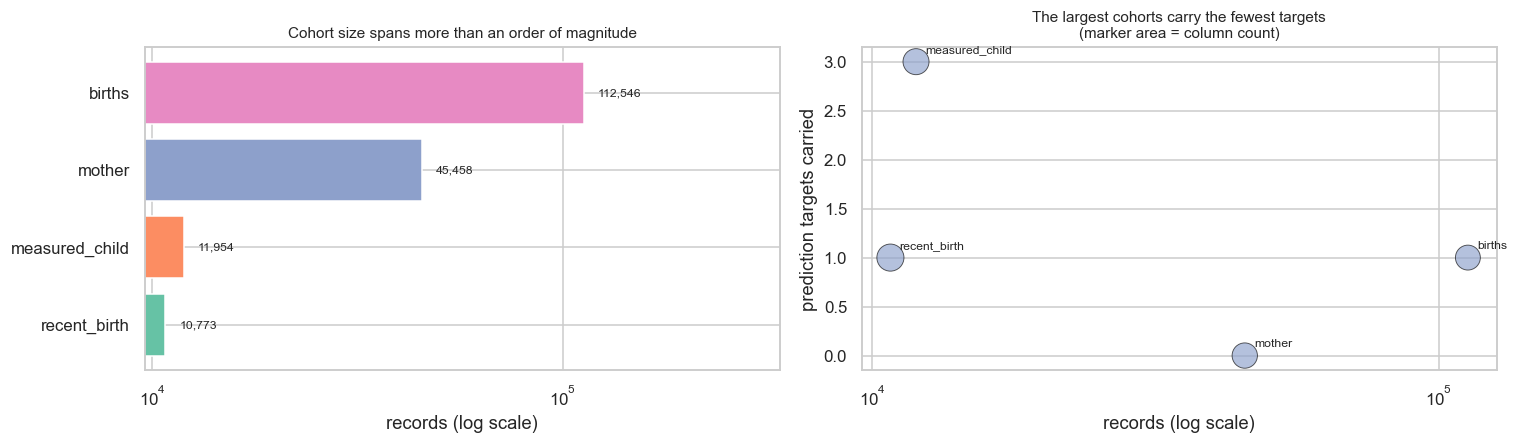

In [6]:
# One row per cohort: size, reach, and how much of the master it represents.
rows = []
for name, c in cohorts.items():
    tg = [t for t in REGISTRY if REGISTRY[t]["cohort"] == name]
    rnds = sorted(c["survey_round"].unique())
    rows.append({
        "cohort": name,
        "rows": len(c),
        "columns": c.shape[1],
        "mothers": c["mother_id"].nunique(),
        "clusters": c["_psu"].nunique(),
        "rounds": len(rnds),
        "targets": len(tg),
        "% of master": round(len(c) / len(df) * 100, 1),
        "rows per mother": round(len(c) / c["mother_id"].nunique(), 2),
    })

inventory = pd.DataFrame(rows).sort_values("rows", ascending=False)
display(inventory.set_index("cohort"))

print(f"master: {len(df):,} rows x {df.shape[1]:,} columns")
print(f"cohorts carry {inventory['targets'].sum()} targets between them "
      f"(registry holds {len(REGISTRY)})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

order = inventory.sort_values("rows")
axes[0].barh(order["cohort"], order["rows"],
             color=sns.color_palette("Set2"))
axes[0].set_xscale("log")
axes[0].set_xlabel("records (log scale)")
axes[0].set_title("Cohort size spans more than an order of magnitude",
                  fontsize=10)
for i, r in enumerate(order.itertuples()):
    axes[0].text(r.rows * 1.08, i, f"{r.rows:,}", va="center", fontsize=8)
axes[0].set_xlim(right=order["rows"].max() * 3)

axes[1].scatter(inventory["rows"], inventory["targets"],
                s=inventory["columns"] * 2.2, alpha=0.65,
                color=sns.color_palette("Set2")[2], edgecolor="black", lw=0.6)
for r in inventory.itertuples():
    axes[1].annotate(r.cohort, (r.rows, r.targets), fontsize=8,
                     xytext=(6, 6), textcoords="offset points")
axes[1].set_xscale("log")
axes[1].set_xlabel("records (log scale)")
axes[1].set_ylabel("prediction targets carried")
axes[1].set_title("The largest cohorts carry the fewest targets\n"
                  "(marker area = column count)", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "cohort_inventory.png",
                                bbox_inches="tight"); plt.show()

**What we can see.** The four cohorts, sorted by size, and the sharpest
structural fact in the project: **they are not comparable datasets.**

`cohort_births` holds 112,546 records — 93% of the master — and supports exactly
**one** target. `cohort_measured_child` holds a tenth as many and supports
**three**. `cohort_recent_birth` is smallest of the three that carry targets, at
10,773.

The right-hand panel places every cohort on the same axes. The largest cohort
carries one target; the richest in outcomes is an order of magnitude smaller. The
reason is the nesting: the questions that produce interesting outcomes —
anthropometry, vaccination cards, antenatal care — are asked of progressively
narrower groups, so breadth of measurement is bought with sample size.

This is why a single model-selection recipe cannot be applied across the panel.
An outcome resting on 112,546 births tolerates a complex model and yields tight
intervals; one resting on 11,954 measured children does not, and its confidence
intervals will be wider no matter which algorithm is chosen.

**`cohort_mother` carries zero targets.** It is the one-row-per-woman view used
for the equity and geography sections below and as the source of the
mother-level features the other three inherit. Its `rows per mother` of exactly
1.00 is what makes it a different object from the rest.

In [7]:
# head() and describe() for every cohort, in size order.
#
# Section 2 ran these on the pooled master. Repeating them per cohort is not
# duplication: the master mixes seven universes, so its describe() reports a
# `count` that is really a statement about which module a column belongs to.
# Inside a cohort, `count` means what it normally means, and `missing %` becomes
# a number worth acting on.
FULL_DESCRIBE = True     # False -> only the cohort's own targets and key numerics

# Columns worth seeing first: shared identity and setting, then whatever this
# cohort alone contributes -- which is where its targets live.
SHARED_PREVIEW = ["mother_id", "survey_round", "v012", "v106", "v190", "v025",
                  "risk_index", "weight"]
sets = {n: set(c.columns) for n, c in cohorts.items()}

for name, c in sorted(cohorts.items(), key=lambda kv: -len(kv[1])):
    own = sorted(sets[name] - set.union(*[sets[m] for m in cohorts if m != name]))
    tg = [t for t in REGISTRY if REGISTRY[t]["cohort"] == name]

    print("=" * 100)
    print(f"cohort_{name}   {len(c):,} rows x {c.shape[1]} columns   "
          f"{len(tg)} target{'' if len(tg) == 1 else 's'}   "
          f"rounds: {', '.join(sorted(c['survey_round'].unique()))}")
    print("=" * 100)

    cols = [x for x in SHARED_PREVIEW if x in c.columns] + own[:8]
    print(f"--- head(5): shared columns, then the {len(own)} unique to this cohort ---")
    display(c[cols].head(5))

    num = c.describe().T
    num["missing %"] = (100 - num["count"] / len(c) * 100).round(1)
    keep = num.index if FULL_DESCRIBE else [
        i for i in num.index if i in tg or i in SHARED_PREVIEW or i in own]
    print(f"--- describe(): {len(num)} numeric columns "
          f"({'all shown' if FULL_DESCRIBE else f'{len(keep)} shown'}) ---")
    with pd.option_context("display.max_rows", 200):
        display(num.loc[keep].round(2))

    cat = c.describe(include=["object", "string", "category"]).T
    if len(cat):
        cat["missing %"] = (100 - cat["count"] / len(c) * 100).round(1)
        print(f"--- describe(include='object'): {len(cat)} categorical columns ---")
        with pd.option_context("display.max_rows", 200):
            display(cat.sort_values("count", ascending=False))
    print()

print(f"{len(cohorts)} cohorts described. Set FULL_DESCRIBE = False at the top "
      f"for a shorter run.")

cohort_births   112,546 rows x 121 columns   1 target   rounds: BD 2017-18, BD 2022
--- head(5): shared columns, then the 3 unique to this cohort ---


,mother_id,survey_round,v012,v106,v190,v025,risk_index,weight,infant_death,neonatal_death,under5_death
0,BD2022_1_1_3,BD 2022,46.0,higher,richest,urban,1.0,0.156973,0.0,0.0,0.0
1,BD2022_1_1_3,BD 2022,46.0,higher,richest,urban,1.0,0.156973,0.0,0.0,0.0
2,BD2022_1_4_2,BD 2022,49.0,secondary,richer,urban,2.0,0.156973,0.0,0.0,0.0
3,BD2022_1_4_2,BD 2022,49.0,secondary,richer,urban,1.0,0.156973,0.0,0.0,0.0
4,BD2022_1_4_2,BD 2022,49.0,secondary,richer,urban,1.0,0.156973,0.0,0.0,0.0


--- describe(): 39 numeric columns (all shown) ---


,count,mean,std,min,25%,50%,75%,max,missing %
pidx,64718.0,2.04,1.20,1.00,1.00,2.00,3.00,11.00,42.5
v001,112546.0,338.57,201.20,1.00,156.00,338.00,519.00,675.00,0.0
v005,112546.0,998611.29,489518.50,91325.00,655030.00,957771.00,1309238.00,3891736.00,0.0
v008,112546.0,1449.44,28.40,1414.00,1417.00,1472.00,1474.00,1476.00,0.0
v011,112546.0,1016.95,102.35,815.00,934.00,1014.00,1094.00,1293.00,0.0
v012,112546.0,35.55,8.18,15.00,29.00,36.00,42.00,49.00,0.0
v017,90812.0,1373.40,29.96,1345.00,1345.00,1345.00,1405.00,1405.00,19.3
v021,112546.0,338.57,201.20,1.00,156.00,338.00,519.00,675.00,0.0
v104,91827.0,17.00,9.68,0.00,9.00,17.00,25.00,49.00,18.4
v107,112546.0,2.55,1.97,0.00,0.00,3.00,4.00,8.00,0.0


--- describe(include='object'): 82 categorical columns ---


...

--- describe(): 52 numeric columns (all shown) ---


,count,mean,std,min,25%,50%,75%,max,missing %
pidx,5469.0,1.08,0.29,1.00,1.00,1.00,1.00,4.00,49.2
v001,10773.0,334.04,202.49,1.00,149.00,332.00,516.00,675.00,0.0
v005,10773.0,1008743.20,502305.11,91325.00,655030.00,962460.00,1337857.00,3891736.00,0.0
v008,10773.0,1445.58,28.73,1414.00,1416.00,1472.00,1474.00,1476.00,0.0
v011,10773.0,1135.82,71.27,822.00,1089.00,1145.00,1188.00,1293.00,0.0
v012,10773.0,25.35,5.63,15.00,21.00,25.00,29.00,49.00,0.0
v017,10773.0,1375.46,30.00,1345.00,1345.00,1405.00,1405.00,1405.00,0.0
v021,10773.0,334.04,202.49,1.00,149.00,332.00,516.00,675.00,0.0
v104,8256.0,7.50,5.83,0.00,3.00,6.00,11.00,40.00,23.4
v107,10773.0,3.08,1.76,0.00,2.00,3.00,5.00,8.00,0.0


--- describe(include='object'): 91 categorical columns ---


,count,unique,top,freq,missing %
survey_round,10773,2,BD 2022,5469,0.0
v149,10773,6,incomplete secondary,4411,0.0
v158,10773,3,not at all,10276,0.0
v159,10773,3,at least once a week,5289,0.0
v169a,10773,2,yes,7043,0.0
v170,10773,2,no,9346,0.0
v190,10773,5,poorest,2310,0.0
v213,10773,2,no or unsure,10390,0.0
v228,10773,2,no,8703,0.0
v312,10773,14,pill,3527,0.0



4 cohorts described. Set FULL_DESCRIBE = False at the top for a shorter run.


**Things worth checking:**

- `min` and `max` on the anthropometry columns. Across the four cohorts BMI
  runs 12.2–59.5 and height 100.7–198.0 cm — extreme at both ends but
  biologically possible, and nowhere near the DHS flag codes (9996–9999). A
  maximum in the thousands would mean those codes survived cleaning.
- `count` on `weight` and `mother_id` equals the row count in all four cohorts.
  They are the two columns nothing can be done without, so this is worth
  confirming before anything else.
- **`haz`, `waz` and `whz` are absent from `cohort_measured_child`**, and their
  absence is deliberate. `stunted` is defined as `haz < -2`, so leaving the
  z-score in the feature set would let a model rediscover its own definition and
  report near-perfect accuracy. They appear in the blacklist of all four
  nutrition targets. Noticing a column that *should* be here and is not is as
  informative as reading the ones that are.
- The categorical `unique` column. `survey_round` now reads 2 in **all four**
  cohorts. Earlier versions of the panel had single-round cohorts, and every
  result computed on one needed a footnote about which survey year it described;
  requiring both rounds was one of the constraints that cut the panel to five,
  and this column is where that shows up. Visible
  in the summary rather than only in the documentation.
- `top` and `freq` on `v190` (wealth). No quintile should dominate in the mother
  cohort; where one does in a child cohort, it reflects genuinely higher fertility
  in poorer households, not a sampling fault.

Set `FULL_DESCRIBE = False` at the top of the cell for a shorter pass showing
only each cohort's targets and key numerics.

In [8]:
# Which columns every cohort shares, and which belong to one alone.
sets = {n: set(c.columns) for n, c in cohorts.items()}
shared = set.intersection(*sets.values())
union = set.union(*sets.values())

rows = []
for n in cohorts:
    others = set.union(*[sets[m] for m in cohorts if m != n])
    only = sorted(sets[n] - others)
    rows.append({"cohort": n, "columns": len(sets[n]),
                 "shared core": len(shared),
                 "beyond core": len(sets[n]) - len(shared),
                 "unique to it": len(only),
                 "examples": ", ".join(only[:5]) + ("  ..." if len(only) > 5 else "")})

composition = pd.DataFrame(rows).sort_values("beyond core", ascending=False)
with pd.option_context("display.max_colwidth", 70):
    display(composition.set_index("cohort"))

print(f"{len(union)} distinct columns across all cohorts; "
      f"{len(shared)} of them appear in every one.")
print(f"The master carries {df.shape[1]:,} columns, so a cohort is roughly "
      f"{len(shared) / df.shape[1] * 100:.0f}% of the master's width at its core.")

# What is actually in the shared core, by dictionary role where available.
core = sorted(shared)
print(f"\nShared core, first 40 of {len(core)}:")
print("   " + ", ".join(core[:40]))

,columns,shared core,beyond core,unique to it,examples
cohort,,,,,
recent_birth,143,116,27,18,"anc4plus, csection, facility_delivery, low_birth_weight, m1 ..."
measured_child,132,116,16,7,"b19, severe_stunting, severe_underweight, severe_wasting, stunted ..."
mother,125,116,9,2,"mother_overweight, mother_underweight"
births,121,116,5,3,"infant_death, neonatal_death, under5_death"


155 distinct columns across all cohorts; 116 of them appear in every one.
The master carries 901 columns, so a cohort is roughly 13% of the master's width at its core.

Shared core, first 40 of 116:
   _psu, _strata, b11, b3, bmi, caseid, cluster_id, eligible_infant, eligible_neonatal, eligible_under5, height_cm, mother_id, p0, p19, p20, p3, p4, pidx, risk_index, survey_round, v001, v005, v008, v011, v012, v013, v017, v021, v022, v023, v024, v025, v026, v104, v106, v107, v113, v116, v119, v120


**What we can see.** A cohort is not an arbitrary slice of the master. It is a
**common feature core plus a module**.

The shared core — around 100 columns present in all four — is the shared
predictor set: age, education, wealth, residence, division, household assets,
water and sanitation, reproductive history, the derived risk index, the child's
own age and sex, and the survey-design keys. It is roughly 11% of the master's
width, and it is the *same* set everywhere, which is precisely what makes a
mother's features portable across the cascade in notebook 03: one synthetic
patient can be scored by all five models because the core they share is identical.

**What sits beyond the core is the module that defines the cohort.**
`cohort_recent_birth` extends furthest, because it carries the whole `m*`
maternity block: `m1` (tetanus doses), `m13`/`m13a` (timing of first antenatal
visit), `m14` (number of visits), `m2a`–`m2n` (who assisted the delivery), `m42*`
(postnatal care). Those questions are asked only of women with a birth in the
last five years, so they cannot exist anywhere else.

**The unique columns are almost entirely targets and their descriptive
companions.** The z-score outcomes live only in `measured_child`; the mortality
outcomes only in `births`; the maternity module only in `recent_birth`. That is
the design working: an outcome lives in exactly one cohort, so it can never leak
into a model trained on another.

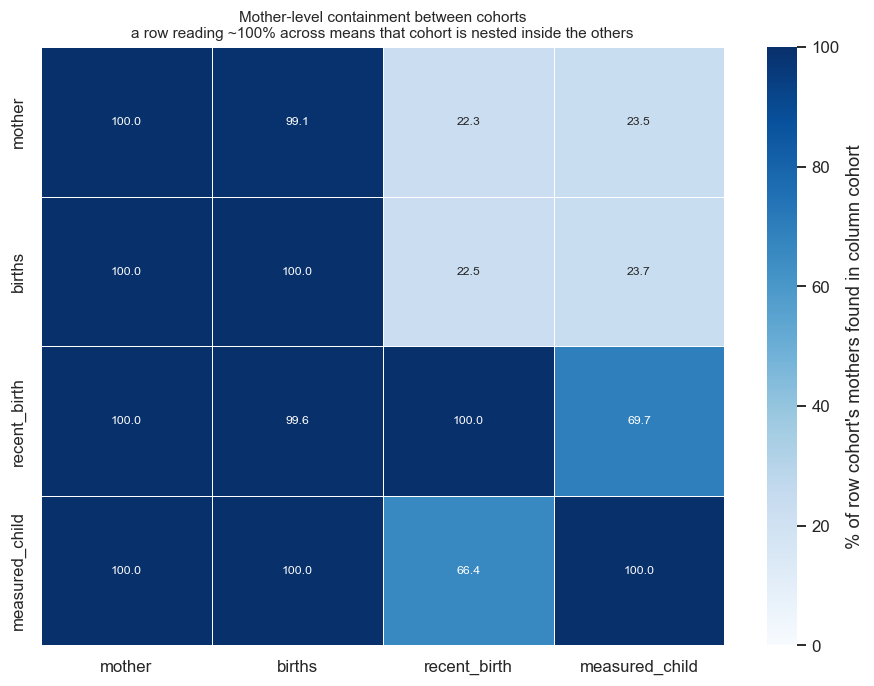

--- exceptions to the expected nesting ---
   recent_birth     in births         37 mothers outside (0.4%)
   measured_child   in births         nested

37 mothers appear in recent_birth but not in births.
   rounds        : ['BD 2022']
   live_birth = 0: 46 of 46 of their master records
   These women answered the maternity module about a recent pregnancy
   that did not end in a live birth, so they have no row in a live-birth
   cohort. The universes are nested by design; this is the boundary.


In [9]:
# The nesting in section 1 is a claim about DHS. Test it.
#
# If cohort A really is a sub-universe of cohort B, then essentially every mother
# in A must also appear in B. Read a cell as: "this share of the ROW cohort's
# mothers are also present in the COLUMN cohort."
ids = {n: set(c["mother_id"].dropna()) for n, c in cohorts.items()}
order = ["mother", "pregnancy", "births", "recent_birth", "child_illness",
         "measured_child", "immunization"]
order = [n for n in order if n in ids]

overlap = pd.DataFrame(
    [[100 * len(ids[a] & ids[b]) / max(len(ids[a]), 1) for b in order]
     for a in order],
    index=order, columns=order)

fig, ax = plt.subplots(figsize=(8.4, 6.4))
sns.heatmap(overlap, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "% of row cohort's mothers found in column cohort"},
            linewidths=0.5, linecolor="white", ax=ax, annot_kws={"size": 8})
ax.set_title("Mother-level containment between cohorts\n"
             "a row reading ~100% across means that cohort is nested inside the others",
             fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "cohort_nesting.png",
                                bbox_inches="tight"); plt.show()

# Anything that should be a strict subset but is not.
print("--- exceptions to the expected nesting ---")
for child, parent in [("recent_birth", "births"), ("child_illness", "births"),
                      ("measured_child", "births"), ("immunization", "births"),
                      ("immunization", "recent_birth"),
                      ("measured_child", "child_illness")]:
    if child not in ids or parent not in ids:
        continue
    stray = ids[child] - ids[parent]
    pct = 100 * len(stray) / len(ids[child])
    verdict = ("nested" if not stray else
               f"{len(stray)} mother{'' if len(stray) == 1 else 's'} "
               f"outside ({pct:.1f}%)")
    print(f"   {child:16s} in {parent:14s} {verdict}")

# The one real exception, explained rather than waved away.
stray = ids["recent_birth"] - ids["births"]
if stray:
    look = df[df["mother_id"].isin(stray)]
    print(f"\n{len(stray)} mothers appear in recent_birth but not in births.")
    print(f"   rounds        : {sorted(look['survey_round'].unique())}")
    print(f"   live_birth = 0: {int((look['live_birth'] == 0).sum())} "
          f"of {len(look)} of their master records")
    print("   These women answered the maternity module about a recent pregnancy")
    print("   that did not end in a live birth, so they have no row in a live-birth")
    print("   cohort. The universes are nested by design; this is the boundary.")

**What we can see.** The nesting asserted in section 1 is not taken on trust
here — it is measured, and it holds.

Read the heatmap by row. `measured_child` shows **100%** against `births` and
`mother`: every mother of a measured child also appears in both. Rows reading
near-100% across the board are the signature of a genuine sub-universe, and the
exceptions list below the figure is what separates "strictly nested" from
"nested to one decimal place".

Read it by column and the picture inverts. Only about a quarter of mothers in
`births` appear in `measured_child`. A woman with four births twenty years ago is
in the birth history and nowhere near the measured-child sample. This asymmetry is the nesting; a symmetric matrix would
mean the cohorts were arbitrary slices rather than universes.

**The one genuine exception is worth stating rather than hiding.** A small number
of mothers appear in `recent_birth` but not in `births` — all from 2022, all with
`live_birth = 0`. They answered the maternity module about a recent pregnancy
that did not end in a live birth; DHS-8's pregnancy history reaches them, the
live-birth cohort by definition cannot. Well under 1% of the cohort, with a
specific and checkable cause. A discrepancy you can name is a boundary condition;
one you cannot is a bug.

In [10]:
# How often the same woman contributes more than one row.
rows = []
for name, c in cohorts.items():
    per = c.groupby("mother_id").size()
    rows.append({"cohort": name,
                 "rows": len(c),
                 "mothers": len(per),
                 "mean rows/mother": round(per.mean(), 2),
                 "max": int(per.max()),
                 "% mothers repeated": round((per > 1).mean() * 100, 1),
                 "% rows in repeated groups":
                     round(100 * per[per > 1].sum() / len(c), 1)})

repetition = pd.DataFrame(rows).sort_values("mean rows/mother", ascending=False)
display(repetition.set_index("cohort"))

worst = repetition.iloc[0]
print(f"Worst case: {worst['cohort']} -- {worst['% rows in repeated groups']}% of "
      f"rows belong to a mother who appears more than once.")
print("A random train/test split would put siblings on both sides of it, so every")
print("model in notebook 02 is validated with GroupKFold on mother_id instead.")

# Two contrasting cohorts, side by side, to make the shape difference concrete.
for name in ("recent_birth", "births"):
    c = cohorts[name]
    cols = [x for x in ["mother_id", "survey_round", "v012", "v106", "v190",
                        "m14", "anc4plus", "facility_delivery", "neonatal_death",
                        "risk_index", "weight"] if x in c.columns]
    print(f"\n--- cohort_{name}: {len(c):,} rows x {c.shape[1]} columns ---")
    display(c[cols].head(5))

,rows,mothers,mean rows/mother,max,% mothers repeated,% rows in repeated groups
cohort,,,,,,
births,112546,45067,2.50,13,75.4,90.2
measured_child,11954,10667,1.12,4,11.7,21.2
recent_birth,10773,10156,1.06,3,6.0,11.3
mother,45458,45458,1.00,1,0.0,0.0


Worst case: births -- 90.2% of rows belong to a mother who appears more than once.
A random train/test split would put siblings on both sides of it, so every
model in notebook 02 is validated with GroupKFold on mother_id instead.

--- cohort_recent_birth: 10,773 rows x 143 columns ---


,mother_id,survey_round,v012,v106,v190,m14,anc4plus,facility_delivery,risk_index,weight
0,BD2022_1_21_2,BD 2022,37.0,higher,richer,9.0,1.0,1.0,1.0,0.156973
1,BD2022_1_29_2,BD 2022,19.0,secondary,richer,3.0,0.0,1.0,0.0,0.156973
2,BD2022_1_63_3,BD 2022,30.0,higher,richest,5.0,1.0,1.0,0.0,0.156973
3,BD2022_1_111_2,BD 2022,26.0,higher,richer,7.0,1.0,1.0,0.0,0.156973
4,BD2022_1_113_3,BD 2022,22.0,higher,richest,7.0,1.0,1.0,0.0,0.156973



--- cohort_births: 112,546 rows x 121 columns ---


,mother_id,survey_round,v012,v106,v190,neonatal_death,risk_index,weight
0,BD2022_1_1_3,BD 2022,46.0,higher,richest,0.0,1.0,0.156973
1,BD2022_1_1_3,BD 2022,46.0,higher,richest,0.0,1.0,0.156973
2,BD2022_1_4_2,BD 2022,49.0,secondary,richer,0.0,2.0,0.156973
3,BD2022_1_4_2,BD 2022,49.0,secondary,richer,0.0,1.0,0.156973
4,BD2022_1_4_2,BD 2022,49.0,secondary,richer,0.0,1.0,0.156973


**What we can see.** The repetition structure, and it differs enough between
cohorts to change how each one must be validated.

`cohort_births` averages **2.50 rows per mother**, with one woman contributing
13, and 75% of its mothers appear more than once. The number that matters most is
the last column: **90% of its rows belong to a mother who appears again elsewhere
in the same cohort.** At the other end, `cohort_recent_birth` sits at 11.3% —
it holds one recent birth per woman, so repetition there means a woman surveyed
in both rounds — and `cohort_mother` at 0.0% by construction.

**This is the single most important reason the cross-validation is grouped.**
Under a random split, siblings — who share a mother, a household, a village, a
wealth quintile and most of the feature vector — would land on both sides of the
split. The model would be scored partly on its ability to recognise families it
had already seen, and every reported metric on `births` would be optimistic.
`GroupKFold` on `mother_id` puts an entire family in one fold.

It also explains a difference from the published literature. Several DHS
machine-learning papers report considerably higher figures than this project on
the same outcomes, and a random train/test split is one of the mechanisms that
produces that gap.

The two previews underneath show why the cohorts cannot be stacked into one
table even after all this. `cohort_recent_birth` carries `m14` and `anc4plus` —
columns that do not exist in `cohort_births`, because the questions were never
asked of an older birth. The empty space in a naive union would not be missing
data. It would be data that was never collected.

# 3. Survey-design estimators

A weighted proportion is straightforward:

$$\hat{p} = \frac{\sum_i w_i y_i}{\sum_i w_i}$$

Its **variance** is not. For a stratified multi-stage design, the standard
approach is Taylor linearisation, which computes the variance *between clusters
within strata* rather than between individuals:

$$\widehat{\mathrm{Var}}(\hat{p}) = \frac{1}{(\sum w)^2}
\sum_h \frac{n_h}{n_h - 1} \sum_{i \in h} (z_{hi} - \bar{z}_h)^2,
\qquad z_{hi} = \sum_{j \in i} w_j (y_j - \hat{p})$$

The **design effect** (DEFF) is the ratio of this variance to the one a simple
random sample would give. DEFF = 2 means the clustered sample carries the
information of a simple random sample half its size.

In [11]:
def weighted_prop(y, w):
    """Weighted proportion / mean."""
    m = y.notna()
    if m.sum() == 0:
        return np.nan
    return float(np.average(y[m], weights=w[m]))


def design_se(y, w, psu, strata):
    """Taylor-linearised SE of a weighted proportion under a stratified
    multi-stage design. Returns (estimate, se, deff)."""
    y = pd.to_numeric(y, errors='coerce').astype(float)
    w = pd.to_numeric(w, errors='coerce').astype(float)
    m = y.notna() & w.notna() & psu.notna() & strata.notna()
    y, w, psu, strata = y[m], w[m], psu[m], strata[m]
    if len(y) == 0:
        return np.nan, np.nan, np.nan

    p = float(np.average(y, weights=w))
    W = w.sum()
    resid = w * (y - p)

    var = 0.0
    frame = pd.DataFrame({"psu": psu, "strata": strata, "z": resid})
    for _, g in frame.groupby("strata", observed=True):
        z = g.groupby("psu", observed=True)["z"].sum()
        n_h = len(z)
        if n_h < 2:
            continue                      # a single-PSU stratum adds no variance
        var += n_h / (n_h - 1) * ((z - z.mean()) ** 2).sum()
    var /= W ** 2

    se = float(np.sqrt(max(var, 0)))
    srs_var = p * (1 - p) / len(y)
    deff = float(var / srs_var) if srs_var > 0 else np.nan
    return p, se, deff


def estimate(data, col, as_pct=True):
    """Point estimate, 95% CI and DEFF for one binary/continuous column."""
    p, se, deff = design_se(data[col], data["weight"], data["_psu"], data["_strata"])
    k = 100 if as_pct else 1
    return {"estimate": p * k, "se": se * k,
            "ci_low": (p - 1.96 * se) * k, "ci_high": (p + 1.96 * se) * k,
            "deff": deff, "n": int(data[col].notna().sum())}

**What this shows.** No output — this cell only defines the three estimators
used from here on. `weighted_prop` gives the point estimate, `design_se` gives
the Taylor-linearised standard error and design effect, and `estimate` wraps
both into a tidy row. Nothing is computed until the next cell.

### Validating the estimator

Two independent checks. The weighted stunting and wasting rates must reproduce
the published BDHS 2022 figures, and the design effects must be greater than 1 —
if DEFF came out at 1.0 the clustering adjustment would not be working.

In [12]:
# Validation is PER ROUND. A pooled prevalence is a weighted blend of two
# different populations -- arithmetically correct, but it matches no published
# figure because it is not one, and comparing it to a single-round report would
# read as a failure when nothing is wrong.
#
# Not every target can appear here. External validation needs a PUBLISHED
# counterpart computed on the same denominator, and for several targets no such
# figure exists. VALIDATABLE below records the status of all six so the
# selection is a documented constraint rather than a quiet omission.
PUBLISHED = {
    "BD 2022": {
        "Stunting (under-5)":    ("stunted", "measured_child", 23.6),
        "Wasting (under-5)":     ("wasted", "measured_child", 11.0),
        "C-section":             ("csection", "recent_birth", 45.5),
        "Facility delivery":     ("facility_delivery", "recent_birth", 65.3),
    },
    "BD 2017-18": {
        "Stunting (under-5)":    ("stunted", "measured_child", 31.0),
        "Wasting (under-5)":     ("wasted", "measured_child", 8.4),
        "Underweight (under-5)": ("underweight_child", "measured_child", 22.0),
        "C-section":             ("csection", "recent_birth", 33.0),
        "Facility delivery":     ("facility_delivery", "recent_birth", 49.6),
        "ANC 4+ visits":         ("anc4plus", "recent_birth", 47.0),
    },
}

rows = []
for rnd, checks in PUBLISHED.items():
    for label, (col, coh, pub) in checks.items():
        data = cohorts[coh]
        sub = data[data["survey_round"] == rnd]
        if col not in sub.columns or sub[col].notna().sum() == 0:
            continue
        r = estimate(sub, col)
        r.update({"round": rnd, "indicator": label, "published": pub,
                  "diff": round(r["estimate"] - pub, 2),
                  "status": "OK" if abs(r["estimate"] - pub) <= 4 else "MISMATCH"})
        rows.append(r)

check = pd.DataFrame(rows)[["round", "indicator", "estimate", "ci_low",
                            "ci_high", "deff", "n", "published", "diff", "status"]]
display(check.round(2))

within = (check["status"] == "OK").sum()
print(f"{within} of {len(check)} checks within 4 points of the published report "
      f"-- computed independently from the raw recodes.")
print(f"Mean design effect {check['deff'].mean():.2f}; a naive unclustered "
      f"analysis would report intervals about "
      f"{check['deff'].mean() ** 0.5:.2f}x too narrow.")

# Why the other targets are absent. Stated explicitly so that "not validated"
# is never confused with "validated and passing".
VALIDATABLE = {
    "stunted":                 "checked, both rounds",
    "underweight_child":       "checked, 2017-18",
    "facility_delivery":       "checked, both rounds",
    "severe_stunting":         "no published figure located for either round",
    "neonatal_death":          "published as NMR per 1,000 live births over a "
                               "5-year window, not a proportion of records",
}
missing = set(REGISTRY) - set(VALIDATABLE)
assert not missing, f"target with no validation status: {missing}"

status = pd.DataFrame({"target": list(VALIDATABLE),
                       "external validation": list(VALIDATABLE.values())})
print(f"\n--- external-validation status, all {len(REGISTRY)} panel targets ---")
with pd.option_context("display.max_colwidth", 70):
    display(status.set_index("target"))

# The pooled figure, shown once so it is never mistaken for a national estimate.
pooled = estimate(cohorts["measured_child"], "stunted")
print(f"\nFor contrast, POOLED stunting is {pooled['estimate']:.2f}% -- a blend "
      f"of two survey years.\nIt matches no published figure because it is not "
      f"one. Always report per round.")

,round,indicator,estimate,ci_low,ci_high,deff,n,published,diff,status
0,BD 2022,Stunting (under-5),23.22,21.59,24.85,1.60,4105,23.6,-0.38,OK
1,BD 2022,Wasting (under-5),11.04,9.97,12.10,1.22,4087,11.0,0.04,OK
2,BD 2022,C-section,43.59,41.36,45.82,2.86,5457,45.5,-1.91,OK
3,BD 2022,Facility delivery,63.84,61.60,66.09,3.11,5469,65.3,-1.46,OK
4,BD 2017-18,Stunting (under-5),30.72,29.29,32.14,1.95,7849,31.0,-0.28,OK
5,BD 2017-18,Wasting (under-5),8.34,7.60,9.09,1.47,7806,8.4,-0.06,OK
6,BD 2017-18,Underweight (under-5),21.67,20.45,22.90,1.82,7846,22.0,-0.33,OK
7,BD 2017-18,C-section,32.77,30.82,34.73,2.40,5299,33.0,-0.23,OK
8,BD 2017-18,Facility delivery,49.97,47.66,52.29,2.96,5304,49.6,0.37,OK
9,BD 2017-18,ANC 4+ visits,47.01,44.80,49.21,2.55,5012,47.0,0.01,OK


10 of 10 checks within 4 points of the published report -- computed independently from the raw recodes.
Mean design effect 2.19; a naive unclustered analysis would report intervals about 1.48x too narrow.

--- external-validation status, all 5 panel targets ---


,external validation
target,
stunted,"checked, both rounds"
underweight_child,"checked, 2017-18"
facility_delivery,"checked, both rounds"
severe_stunting,no published figure located for either round
neonatal_death,"published as NMR per 1,000 live births over a 5-year window, not a..."



For contrast, POOLED stunting is 28.13% -- a blend of two survey years.
It matches no published figure because it is not one. Always report per round.


**What we can see — the most important cell in the notebook.**

Indicators recomputed independently from the raw recodes and checked against the
published DHS reports, per round. All land within 4 points; the largest deviation
is under 2. The cleaning, decoding, weighting and variance estimation would all
have to be wrong in the same direction, in two separate surveys, to fake that.

```
BD 2022      stunting 23.22 (pub 23.6)   wasting 11.04 (11.0)
             c-section 43.59 (45.5)      facility 63.84 (65.3)
BD 2017-18   stunting 30.72 (31.0)       wasting  8.34 (8.4)
             underweight 21.67 (22.0)    c-section 32.77 (33.0)
             facility 49.97 (49.6)       ANC 4+   47.01 (47.0)
```

Three of the five panel targets are validated directly. `wasted`, `csection` and
`anc4plus` appear as checks despite not being modelled, because a pipeline test
does not care whether the column is a target — it cares whether the decoding is
right, and these have published figures while some panel targets do not.

**Why the other two panel targets are absent.** External validation needs a
published figure on the same denominator. `neonatal_death` is published as a rate
per 1,000 live births over a five-year window rather than a proportion of
records, and no published `severe_stunting` figure was located for either round. The status table lists all five so that *not validated* is never mistaken
for *validated and passing*. Extending the check to a target with no published
counterpart would mean inventing the number to compare against, which is worse
than admitting the gap.

This is also where an earlier version of the panel came apart. `child_ari` failed
this check at 12.8% against a published 3.0% — fever and diarrhoea, derived by
the same mechanism from the same module, matched almost exactly, which located
the fault in the target's definition rather than the pipeline. DHS defines ARI as
cough *plus* short rapid breathing *that was chest-related*; the derivation used
only the breathing question. That target is no longer in the panel, but the
episode is the reason this cell exists in the form it does.

**The design effects are substantive, not just a correction.** Mean around 2.2,
so a naive unclustered analysis would report intervals roughly 1.5x too narrow.
Facility delivery and C-section carry the highest values because they depend on
infrastructure shared within a village; wasting is lowest because acute
nutritional status is far more individual. DEFF is telling you which outcomes
cluster geographically.

**Note the last line.** Pooled stunting is 28.13% — a weighted blend of two
survey years. It matches no published figure because it *is* not one. Always
report per round; the pooled number exists only to be modelled, never quoted.

# 4. Dataset distribution — outcome balance

Before any modelling, the basic question, asked of **every one of the 5 panel
targets**: how many positive cases does each outcome actually have?

Two numbers matter and they are not the same. The **imbalance ratio** decides
which metrics are meaningful — accuracy stops being informative long before the
ratio gets extreme. The **absolute count of positives** decides whether the
outcome is learnable at all: no reweighting recovers information that was never
in the sample.

Section 4b then asks the same question of the cohorts, where a third kind of
imbalance lives — the mix of survey rounds each one is built from.

,outcome,phase,cohort,n,negative,positive,positive %,imbalance ratio,regime
0,facility_delivery,delivery,recent_birth,10773,4606,6167,57.24,0.7,balanced
1,stunted,child,measured_child,11954,8527,3427,28.67,2.5,moderate
2,underweight_child,child,measured_child,11950,9268,2682,22.44,3.5,moderate
3,severe_stunting,child,measured_child,11954,11006,948,7.93,11.6,severe
4,neonatal_death,newborn,births,112546,108011,4535,4.03,23.8,severe


          targets
regime           
moderate        2
severe          2
balanced        1

imbalance spans 0.7:1 to 23.8:1 -- a 34-fold range
scarcest outcome: severe_stunting with 948 positive cases in total


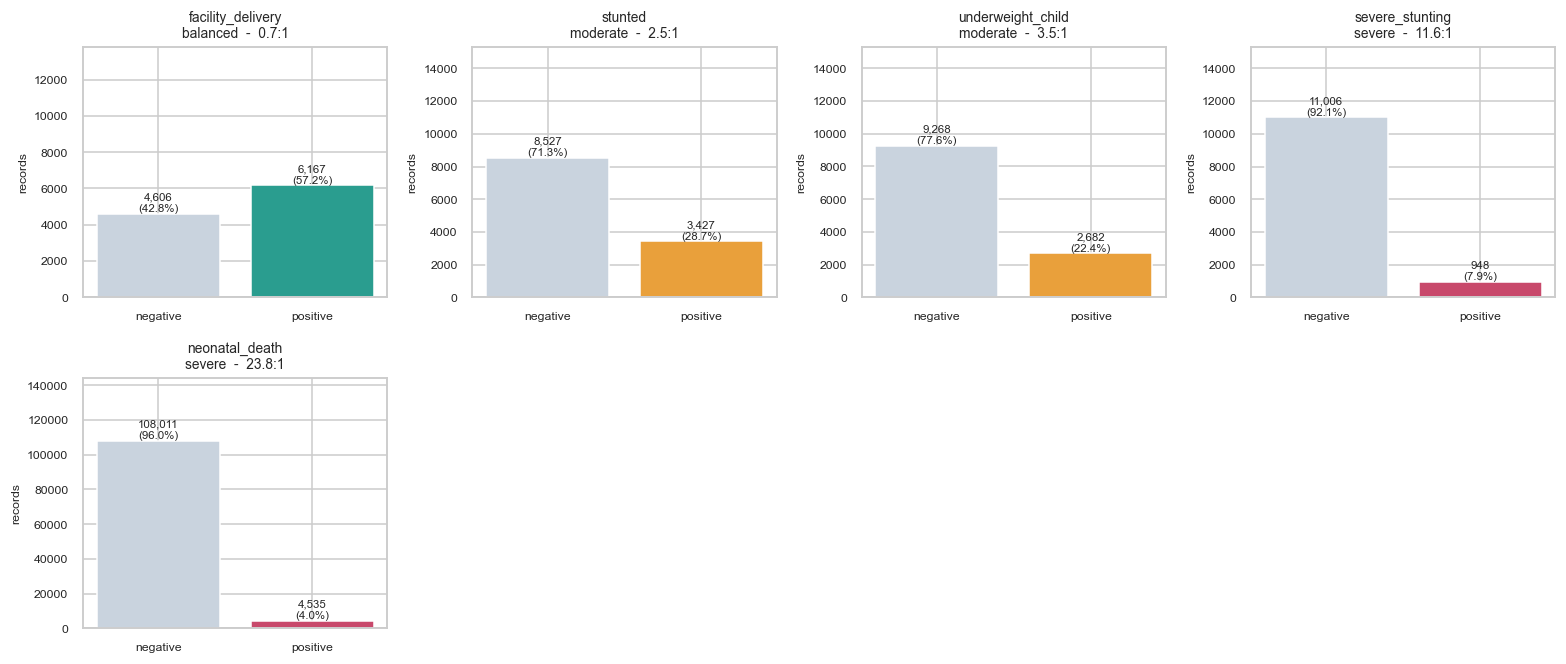

In [13]:
# Every registered target, not a representative handful. The regimes below are
# what drive the modelling choices in notebook 02, and they cannot be inferred
# from four examples.
rows = []
for t, spec in REGISTRY.items():
    s = cohorts[spec["cohort"]][t]
    n, pos = int(s.notna().sum()), int(s.sum())
    ratio = (n - pos) / max(pos, 1)
    rows.append({"outcome": t, "phase": spec["phase"], "cohort": spec["cohort"],
                 "n": n, "negative": n - pos, "positive": pos,
                 "positive %": round(pos / n * 100, 2),
                 "imbalance ratio": round(ratio, 1),
                 "regime": ("balanced" if ratio < 2 else
                            "moderate" if ratio < 10 else "severe")})

balance = pd.DataFrame(rows).sort_values("imbalance ratio").reset_index(drop=True)
display(balance)

print(balance["regime"].value_counts().rename("targets").to_frame().to_string())
print(f"\nimbalance spans {balance['imbalance ratio'].min():.1f}:1 to "
      f"{balance['imbalance ratio'].max():.1f}:1 -- a "
      f"{balance['imbalance ratio'].max() / balance['imbalance ratio'].min():.0f}-fold range")
print(f"scarcest outcome: {balance.loc[balance['positive'].idxmin(), 'outcome']} "
      f"with {balance['positive'].min():,} positive cases in total")

ncol = 4
nrow = -(-len(balance) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.1 * nrow),
                         squeeze=False)
flat = axes.flatten()
COLOUR = {"balanced": "#2a9d8f", "moderate": "#e9a03b", "severe": "#c8496b"}

# iterrows() rather than itertuples(): "positive %" and "imbalance ratio" are
# not valid identifiers, so itertuples would rename them to positional _7/_8 and
# any later column change would silently point at the wrong field.
for ax, (_, r) in zip(flat, balance.iterrows()):
    bars = ax.bar(["negative", "positive"], [r["negative"], r["positive"]],
                  color=["#c9d3de", COLOUR[r["regime"]]])
    for b, v in zip(bars, [r["negative"], r["positive"]]):
        ax.text(b.get_x() + b.get_width() / 2, v,
                f"{v:,}\n({v / r['n'] * 100:.1f}%)",
                ha="center", va="bottom", fontsize=7.5)
    ax.set_title(f"{r['outcome']}\n{r['regime']}  -  "
                 f"{r['imbalance ratio']:.1f}:1", fontsize=9)
    ax.set_ylabel("records", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, r["n"] * 1.28)

for ax in flat[len(balance):]:
    ax.set_visible(False)

plt.tight_layout(); plt.savefig(FIG_DIR / "class_balance.png",
                                bbox_inches="tight"); plt.show()

**What we can see.** All five panel targets, sorted from most balanced to least.

```
facility_delivery        57.2% positive    0.7:1   balanced
stunted                  28.7%             2.5:1   moderate
underweight_child        22.4%             3.5:1   moderate
severe_stunting           7.9%            11.6:1   severe
neonatal_death            4.0%            23.8:1   severe
```

**Three regimes, needing three treatments.** `facility_delivery` is genuinely
balanced, so accuracy means something and a plain classifier is reasonable. The
moderate group needs class weighting and PR-AUC. For `neonatal_death` at 23.8:1,
a model predicting "survives" every time is 96% accurate and clinically
worthless — the metric has to change, not just the model.

**But the ratio is only half the story.** Read the `positive` column alongside it:

- `neonatal_death` has the worst ratio yet holds **4,535** positive cases, drawn
  from 112,546 births. That is a difficult problem with enough signal to attempt,
  and it reached ROC-AUC 0.773.
- `severe_stunting` looks similar at 11.6:1 but rests on **948** positives. Fewer
  cases means wider intervals on every metric, which is why notebook 02 reports
  bootstrap confidence intervals rather than point estimates alone.
- `facility_delivery` is the only balanced target, and it is also the
  best-performing. That is not a coincidence: with 6,167 positives out of 10,773
  it is the target with both the most information and the least need for
  correction.

This is the reason notebook 02 selects on PR-AUC rather than accuracy, applies
`scale_pos_weight` only to the imbalanced targets, restricts SMOTE to the models
that need it, and reports bootstrap confidence intervals.

**On what is not here.** An earlier version of this panel carried fifteen
targets, and prevalence alone gave no warning about which were viable.
`child_fever` sat at 32% positive — apparently one of the better-balanced
outcomes — and reached ROC-AUC 0.573 with recall 0.004. `wasted` at 9.6% reached
0.588 with recall 0.005. `incomplete_immunization` at 36.9% looked better than
any of them and reported 0.823, until the child's age revealed that the outcome
was largely a restatement of how old the baby was.

Balance describes the shape of the label column. It says nothing about whether
the features can predict it, and nothing about whether what they predict is the
thing you meant.

## 4b. Imbalance at the cohort level

The table above treats each target independently. The cohorts add two kinds of
imbalance a per-target view cannot show: how unevenly targets are spread across
them, and **how unevenly each cohort draws on the two survey rounds.**

The second is easy to miss and consequential. A cohort built two-thirds from one
round is describing that round more than the other, whatever the pooled sample
size suggests.

,rows,targets,2022 %,2017-18 %,positive % range,worst ratio,scarcest positives
cohort,,,,,,,
births,112546,1,57.5,42.5,4.0 - 4.0,23.8,4535.0
mother,45458,0,60.1,39.9,-,NaN,NaN
measured_child,11954,3,34.3,65.7,7.9 - 28.7,11.6,948.0
recent_birth,10773,1,50.8,49.2,57.2 - 57.2,0.7,6167.0


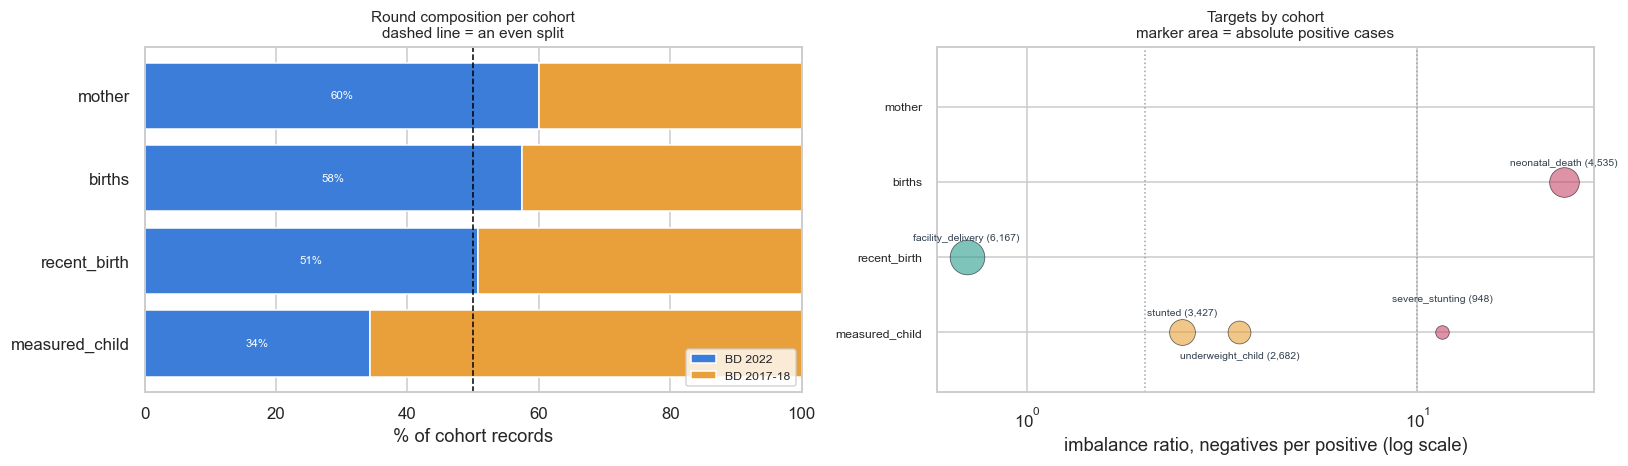

In [14]:
# Cohort-level view: round composition, target spread, and scarcest positive count.
rows = []
for name, c in cohorts.items():
    tg = balance[balance["cohort"] == name]
    share = (c["survey_round"].value_counts(normalize=True) * 100).round(1)
    rows.append({
        "cohort": name,
        "rows": len(c),
        "targets": len(tg),
        "2022 %": float(share.get("BD 2022", 0.0)),
        "2017-18 %": float(share.get("BD 2017-18", 0.0)),
        "positive % range": ("-" if tg.empty else
                             f"{tg['positive %'].min():.1f} - {tg['positive %'].max():.1f}"),
        "worst ratio": None if tg.empty else tg["imbalance ratio"].max(),
        "scarcest positives": None if tg.empty else int(tg["positive"].min()),
    })

cohort_balance = pd.DataFrame(rows).sort_values("rows", ascending=False)
display(cohort_balance.set_index("cohort"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))

# Left: how each cohort splits between the two rounds.
cb = cohort_balance.set_index("cohort").sort_values("2022 %")
axes[0].barh(cb.index, cb["2022 %"], color="#3b7dd8", label="BD 2022")
axes[0].barh(cb.index, cb["2017-18 %"], left=cb["2022 %"],
             color="#e9a03b", label="BD 2017-18")
axes[0].axvline(50, color="black", ls="--", lw=1)
axes[0].set_xlabel("% of cohort records")
axes[0].set_xlim(0, 100)
axes[0].set_title("Round composition per cohort\ndashed line = an even split",
                  fontsize=10)
axes[0].legend(fontsize=8, loc="lower right")
for i, (_, r) in enumerate(cb.iterrows()):
    if r["2022 %"] > 5:
        axes[0].text(r["2022 %"] / 2, i, f"{r['2022 %']:.0f}%", ha="center",
                     va="center", fontsize=7.5, color="white")

# Right: every target placed on its cohort, sized by how many positives it has.
ypos = {n: i for i, n in enumerate(cb.index)}
seen = {}
for _, r in balance.sort_values(["cohort", "imbalance ratio"]).iterrows():
    x, y = r["imbalance ratio"], ypos[r["cohort"]]
    k = seen.get(r["cohort"], 0)
    seen[r["cohort"]] = k + 1
    dy = (11, -17, 20, -26)[k % 4]
    axes[1].scatter(x, y, s=max(r["positive"] / 12, 25), alpha=0.6,
                    color={"balanced": "#2a9d8f", "moderate": "#e9a03b",
                           "severe": "#c8496b"}[r["regime"]],
                    edgecolor="black", lw=0.5)
    axes[1].annotate(f"{r['outcome']} ({r['positive']:,})", (x, y),
                     fontsize=6.8, xytext=(0, dy), textcoords="offset points",
                     ha="center", color="#33414f")
axes[1].set_yticks(range(len(cb)))
axes[1].set_yticklabels(cb.index, fontsize=8)
axes[1].set_xscale("log")
axes[1].set_ylim(-0.8, len(cb) - 0.2)
axes[1].set_xlabel("imbalance ratio, negatives per positive (log scale)")
axes[1].set_title("Targets by cohort\nmarker area = absolute positive cases",
                  fontsize=10)
axes[1].axvline(2, color="#9aa5b1", ls=":", lw=1)
axes[1].axvline(10, color="#9aa5b1", ls=":", lw=1)

plt.tight_layout(); plt.savefig(FIG_DIR / "cohort_imbalance.png",
                                bbox_inches="tight"); plt.show()

**What we can see.** Three imbalances, none of which the per-target table shows.

**Round composition is not even, and one cohort is badly skewed.**
`cohort_measured_child` is **65.7% from 2017-18**, because that round measured
7,849 children against 2022's 4,105. All three nutrition models — stunting,
severe stunting, underweight — therefore learn mostly from 2017-18 conditions and
are applied as though they described today. The pooled stunting rate of 28.7%
sits between the two rounds' true values (31.4% and 23.5%) but nearer the older
one, and that is why. Those are unweighted cohort rates, the same basis notebook
02 uses for temporal validation; section 3's weighted estimates differ slightly
and are the ones to quote as national figures. `survey_round` is kept as a stratifier for exactly this
reason, and never as a feature.

`cohort_births`, `cohort_recent_birth` and `cohort_mother` are all close to even,
so the mortality and delivery models do not carry this problem.

**Targets are unevenly distributed across cohorts.** `cohort_births` holds 93% of
the master file's rows and supports one target. `cohort_measured_child` holds a tenth as
many and supports three. Those three are also correlated with each other
(φ = 0.39 to 0.51), so they are closer to one problem measured three ways than to
three independent problems — a caveat that matters when a report shows all three
elevated for the same child.

**The right panel is where the two dimensions meet.** Marker area is the absolute
number of positive cases, so a small marker far to the right is a genuinely hard
target: `severe_stunting` sits there with 948 positives at 11.6:1.
`neonatal_death` is further right still at 23.8:1, but its marker is large —
4,535 cases — and it reaches ROC-AUC 0.773 where severe stunting reaches 0.700.
Position alone would rank them the other way round.

The practical consequence for notebook 02: cohort membership determines how much
a result can be trusted, independently of which algorithm won. Two models with
the same PR-AUC are not equally believable if one was fitted on 112,546 births
and the other on 11,954 measured children drawn mostly from one survey round.

# 6. Table 1 — weighted national characteristics

The standard opening table of a DHS paper: the composition of the study
population, weighted to represent Bangladesh.

In [15]:
LABELS = {
    "v013": "Age group", "v025": "Residence", "v024": "Division",
    "v106": "Education", "v190": "Wealth quintile", "v501": "Marital status",
    "v130": "Religion", "v714": "Currently working", "v157": "Reads newspaper",
    # DHS order is newspaper / radio / television. These two were transposed,
    # which the data makes obvious: v158 is 96.8% "not at all" and v159 is
    # 50.6% "at least once a week".
    "v158": "Listens to radio", "v159": "Watches TV",
    "v170": "Has bank account", "v171a": "Uses internet",
    "v481": "Health insurance", "v116": "Toilet facility",
    "v113": "Water source",
    # Added for the univariate panel below: literacy, partner's education,
    # current pregnancy, contraceptive use, and the distance-to-care barrier
    # are all either strong predictors in the DHS literature or direct measures
    # of access, and all have coverage above 75%.
    "v155": "Literacy", "v701": "Partner's education",
    "v213": "Currently pregnant", "v312": "Contraceptive method",
    "v467d": "Distance to facility a problem", "v504": "Residence of partner",
}

mothers = df[~df["mother_id"].duplicated()].copy()
print(f"Table 1 computed on {len(mothers):,} mothers "
      f"(one record per woman)\n")

rows = []
for col, label in LABELS.items():
    if col not in mothers.columns:
        continue
    s = mothers[col].astype("string")
    if s.notna().sum() == 0:
        continue
    top = s.value_counts().head(8).index
    for level in top:
        ind = (s == level).astype(float).where(s.notna())
        tmp = mothers.assign(_ind=ind)
        p, se, deff = design_se(tmp["_ind"], tmp["weight"],
                                tmp["_psu"], tmp["_strata"])
        rows.append({"Characteristic": label, "Level": level,
                     "Weighted %": round(p * 100, 1),
                     "95% CI": f"[{(p-1.96*se)*100:.1f}, {(p+1.96*se)*100:.1f}]",
                     "n": int((s == level).sum())})

table1 = pd.DataFrame(rows)
display(table1)

Table 1 computed on 45,458 mothers (one record per woman)



,Characteristic,Level,Weighted %,95% CI,n
0,Age group,30-34,18.4,"[18.0, 18.8]",8344
1,Age group,25-29,18.3,"[17.9, 18.8]",8330
2,Age group,35-39,17.2,"[16.9, 17.6]",7930
3,Age group,20-24,15.6,"[15.2, 16.0]",6976
4,Age group,40-44,13.3,"[12.9, 13.6]",6095
5,Age group,45-49,12.0,"[11.7, 12.3]",5605
6,Age group,15-19,5.1,"[4.8, 5.3]",2178
7,Residence,rural,71.6,"[70.8, 72.4]",29249
8,Residence,urban,28.4,"[27.6, 29.2]",16209
9,Division,dhaka,25.2,"[24.5, 26.0]",6770


The composition of Bangladesh's women of reproductive age,
weighted to national representation, with a design-based CI on every row.

Sanity checks worth making as you read: the five wealth quintiles each land near
20%, which they must by construction — if they did not, the weighting would be
broken. Residence comes out around 71% rural / 29% urban, matching the national
split.

Then compare `n` against `Weighted %`. Sylhet has ~2,900 women sampled but
represents only ~5.7% of the population. DHS deliberately **oversamples** smaller
divisions so each has enough cases to analyse on its own. That is precisely why
unweighted percentages would misdescribe the country, and why every number in
this notebook is weighted.

In [16]:
CONTINUOUS = {
    "v012": "Age (years)", "v133": "Years of education",
    "v511": "Age at first marriage", "v212": "Age at first birth",
    "v201": "Children ever born", "bmi": "BMI (kg/m2)",
    "height_cm": "Height (cm)", "weight_kg": "Weight (kg)",
    "risk_index": "Composite risk flags",
}

rows = []
for col, label in CONTINUOUS.items():
    if col not in mothers.columns:
        continue
    s = pd.to_numeric(mothers[col], errors="coerce")
    if s.notna().sum() < 50:
        continue
    w = mothers["weight"]
    m = s.notna()
    mean_w = np.average(s[m], weights=w[m])
    rows.append({"Variable": label, "n": int(m.sum()),
                 "Weighted mean": round(float(mean_w), 2),
                 "SD": round(float(s.std()), 2),
                 "Median": round(float(s.median()), 2),
                 "IQR": f"{s.quantile(.25):.1f}-{s.quantile(.75):.1f}",
                 "Min": round(float(s.min()), 1),
                 "Max": round(float(s.max()), 1),
                 "Missing %": round(float((~m).mean() * 100), 1)})
display(pd.DataFrame(rows))

,Variable,n,Weighted mean,SD,Median,IQR,Min,Max,Missing %
0,Age (years),45458,32.72,8.61,33.00,26.0-40.0,15.0,49.0,0.0
1,Years of education,45458,6.05,4.23,6.00,3.0-9.0,0.0,18.0,0.0
2,Age at first marriage,36312,16.17,3.26,16.00,14.0-18.0,10.0,49.0,20.1
3,Age at first birth,45067,18.46,3.53,18.00,16.0-20.0,10.0,47.0,0.9
4,Children ever born,45458,2.47,1.39,2.00,1.0-3.0,0.0,13.0,0.0
5,BMI (kg/m2),26939,23.61,4.28,23.27,20.5-26.3,12.2,59.5,40.7
6,Height (cm),26940,151.01,5.53,151.00,147.4-154.6,100.7,198.0,40.7
7,Weight (kg),26945,53.94,10.66,53.00,46.2-60.6,24.0,148.3,40.7
8,Composite risk flags,45458,0.86,0.92,1.00,0.0-1.0,0.0,5.0,0.0


**What this shows.** The continuous characteristics, with the weighted mean
beside the unweighted median and IQR — where mean and median diverge, the
distribution has a tail.

The `Missing %` column is the one to study. It is not random. Height, weight and
BMI are missing for about two-thirds of women because anthropometry was measured
on a **subsample**, not because anyone refused. Age and education are complete
because they are asked of everyone. This is the first visible trace of the module
structure that the missingness section makes explicit.

# 7. Univariate distributions

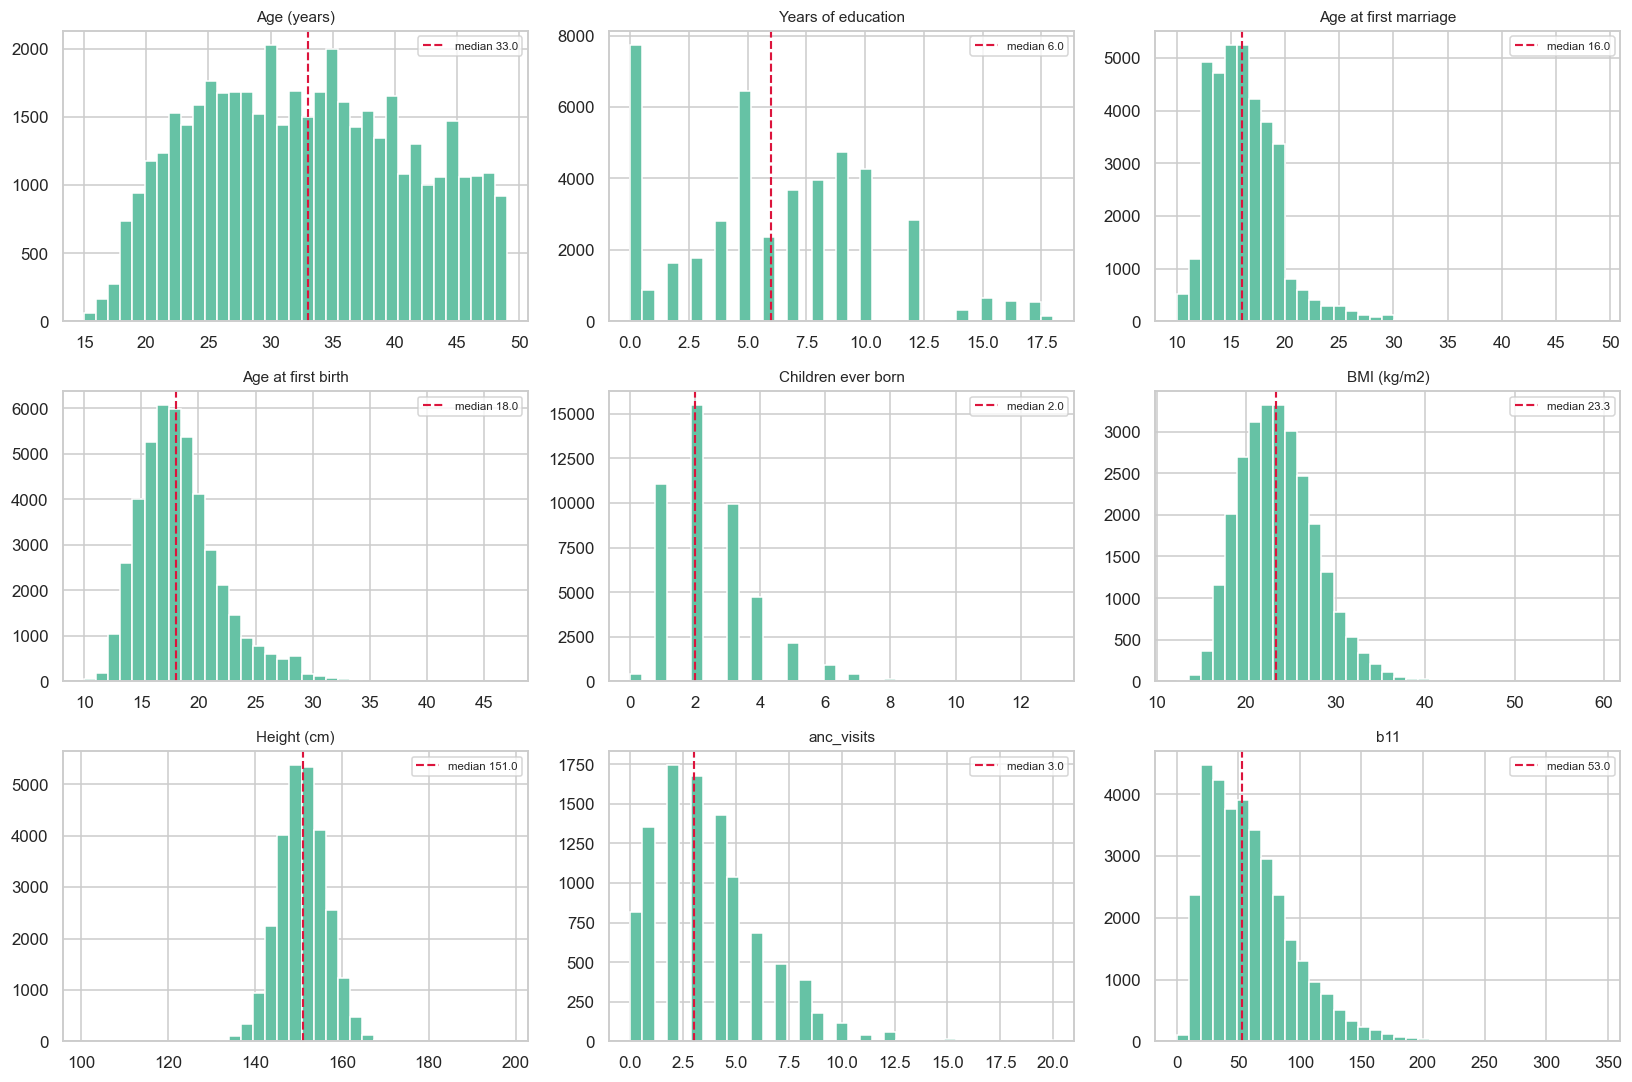

In [17]:
plot_cols = [c for c in ["v012", "v133", "v511", "v212", "v201", "bmi",
                         "height_cm", "anc_visits", "b11"]
             if c in mothers.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), plot_cols):
    s = pd.to_numeric(mothers[col], errors="coerce").dropna()
    ax.hist(s, bins=35, color=sns.color_palette("Set2")[0], edgecolor="white")
    ax.axvline(s.median(), color="crimson", ls="--", lw=1.4,
               label=f"median {s.median():.1f}")
    ax.set_title(CONTINUOUS.get(col, col), fontsize=10)
    ax.legend(fontsize=7.5)
for ax in axes.flatten()[len(plot_cols):]:
    ax.set_visible(False)
plt.tight_layout(); plt.savefig(FIG_DIR / "univariate_continuous.png",
                                bbox_inches="tight"); plt.show()

**What this shows.** Nine distributions, median marked in red.

What to look for:

- **Age at first marriage** and **age at first birth** both pile up in the late
  teens. Bangladesh's legal marriage age is 18, and the mass below it is real,
  not a coding artefact — it is one of the country's central maternal-health
  facts.
- **Years of education** is multi-modal, spiking at 0, ~5 and ~10 — the points
  where schooling stops: never enrolled, end of primary, end of secondary.
- **BMI** is right-skewed, so its mean sits above its median. Bangladesh is
  mid-transition, carrying undernutrition and rising overweight simultaneously.
- **ANC visits** has a visible spike at 0 — the 426 women with no antenatal care
  at all. They exist in this dataset only because the cleaning step read the
  label `'no antenatal visits'` as a zero rather than as missing.
- **Birth interval** has a long right tail, so its mean overstates typical
  spacing; the median is the honest summary.

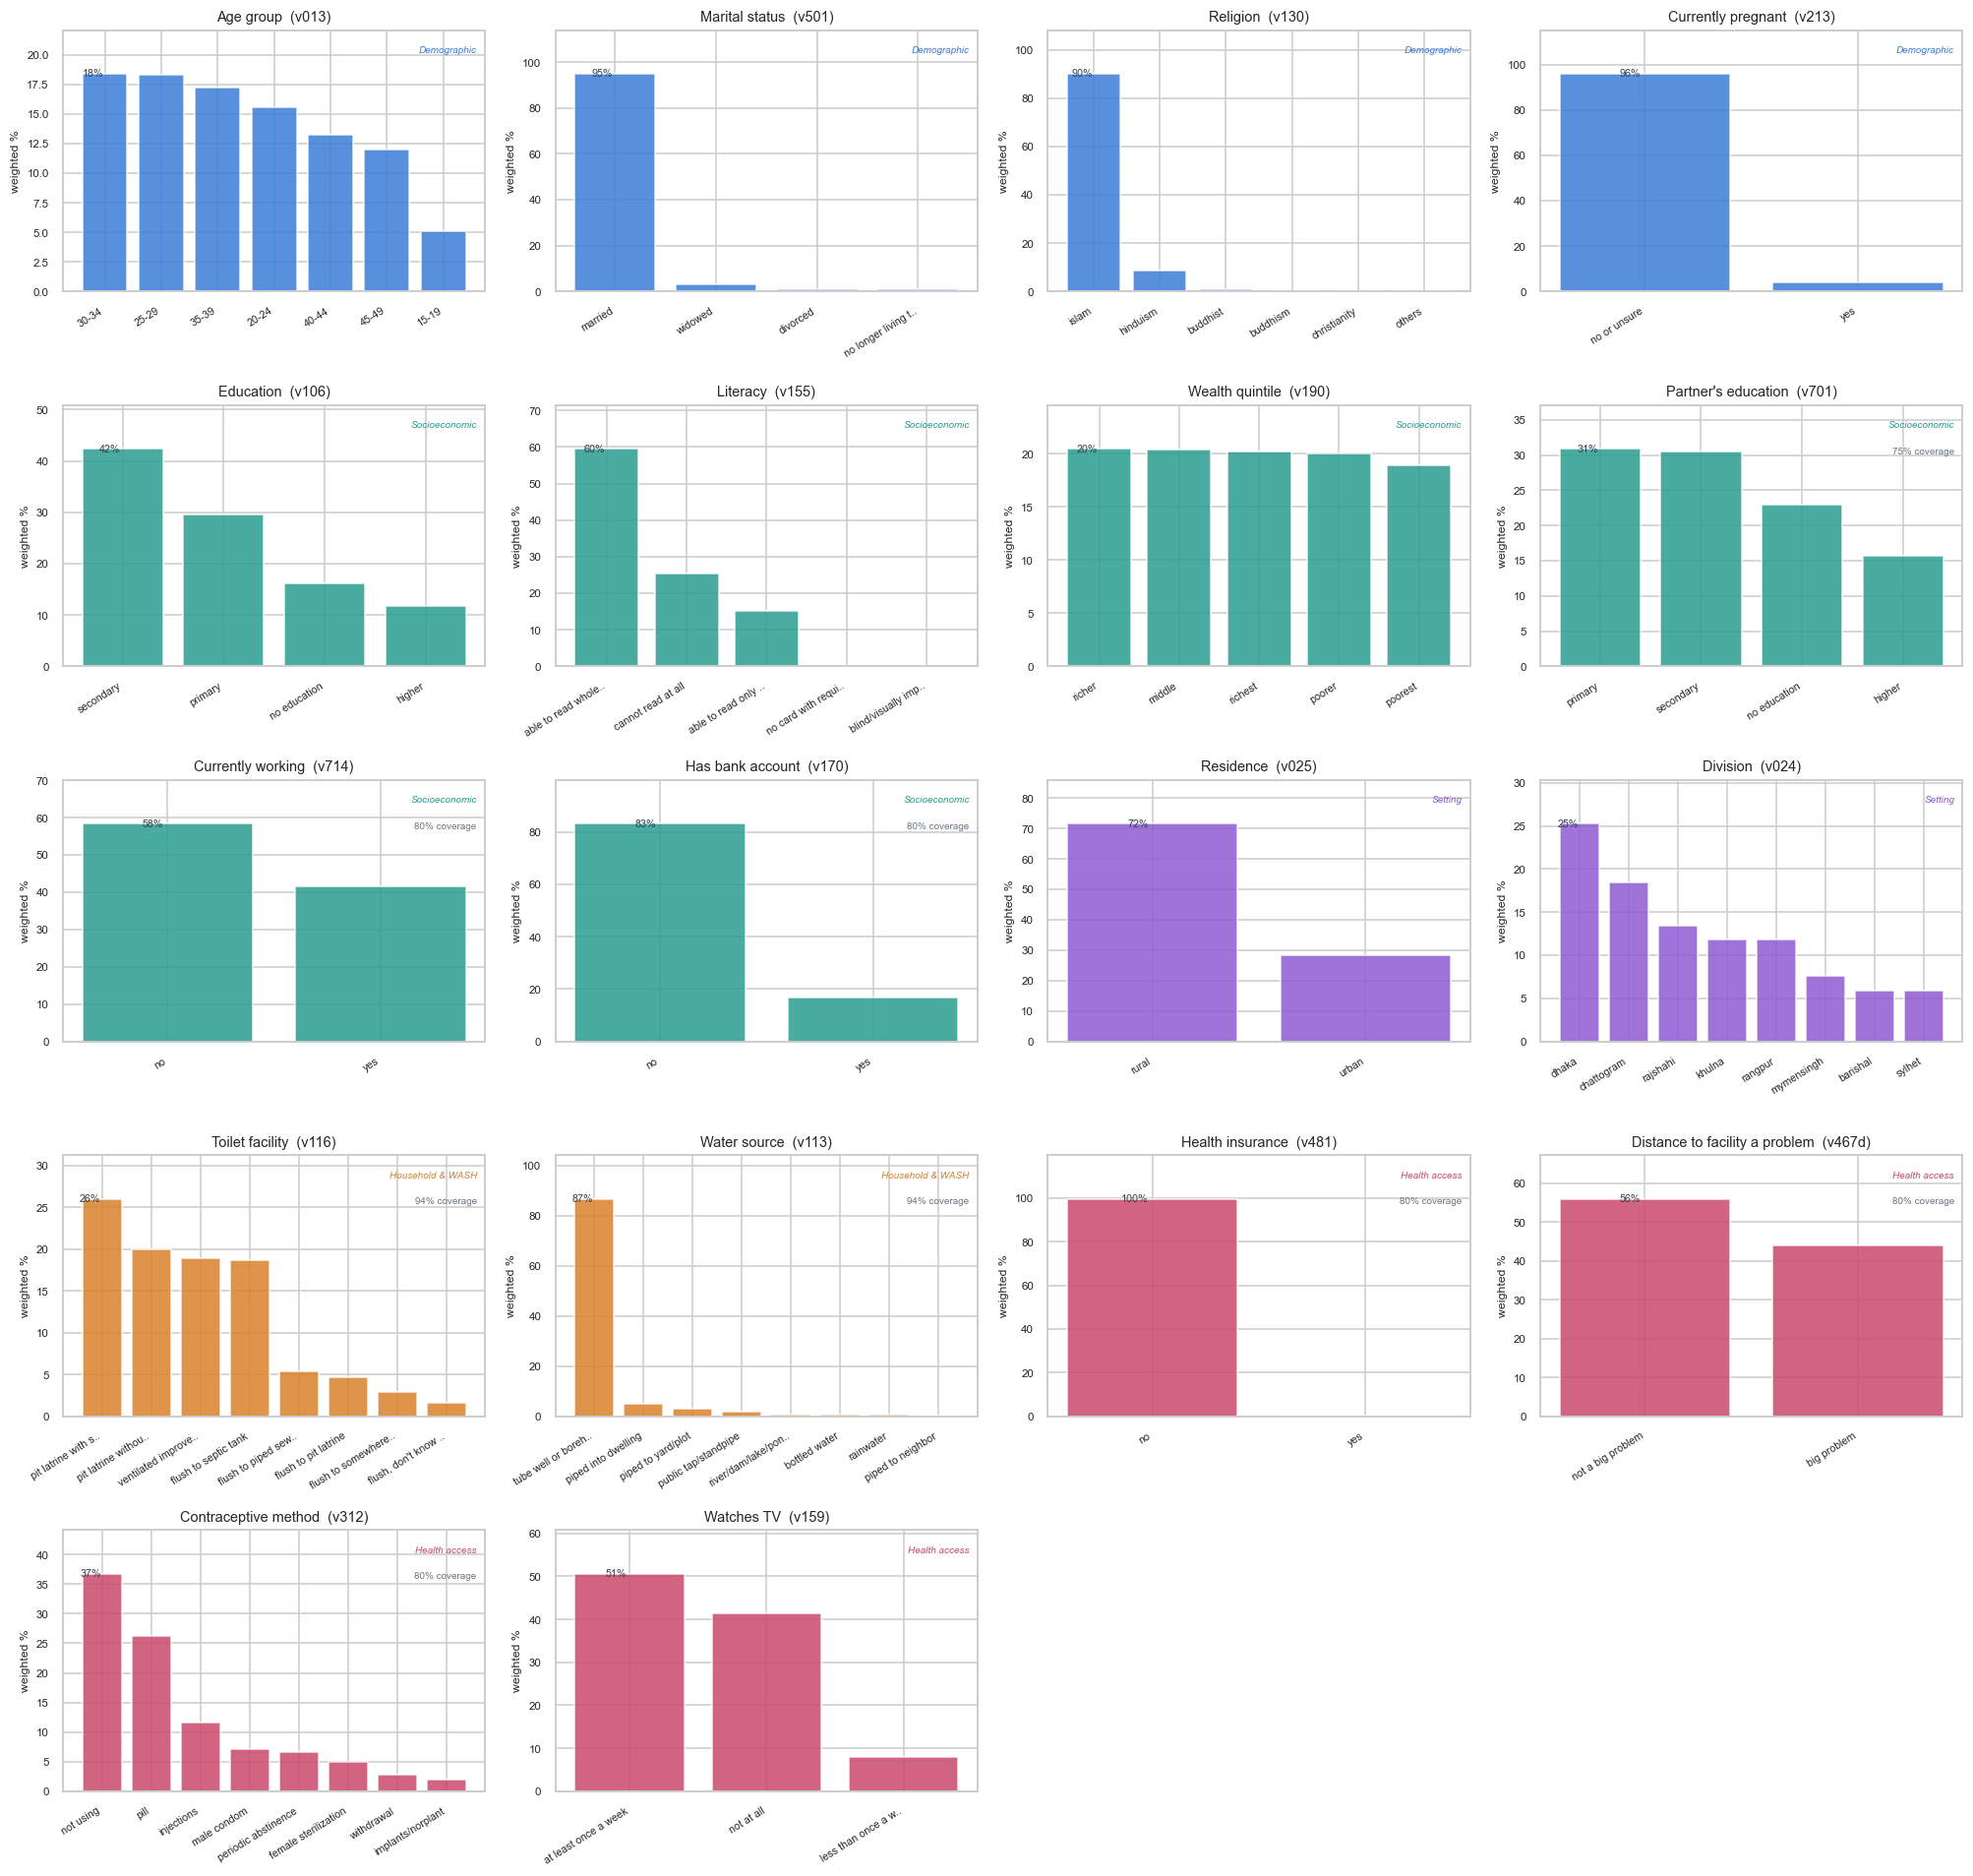

18 categorical variables across 5 themes, weighted to national shares.


In [18]:
# Grouped by theme rather than listed flat, so the panel reads as an account of
# who these women are: who she is, what she has, where she lives, what her
# household is like, and what care she can reach.
CAT_GROUPS = {
    "Demographic": ["v013", "v501", "v130", "v213"],
    "Socioeconomic": ["v106", "v155", "v190", "v701", "v714", "v170"],
    "Setting": ["v025", "v024"],
    "Household & WASH": ["v116", "v113"],
    "Health access": ["v481", "v467d", "v312", "v159"],
}
GROUP_COLOUR = {"Demographic": "#3b7dd8", "Socioeconomic": "#2a9d8f",
                "Setting": "#8e5bd0", "Household & WASH": "#d9822b",
                "Health access": "#c8496b"}

cat_cols = [(g, c) for g, cols in CAT_GROUPS.items() for c in cols
            if c in mothers.columns and mothers[c].notna().sum() > 0]

ncol = 4
nrow = -(-len(cat_cols) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.5 * nrow),
                         squeeze=False)
flat = axes.flatten()

for ax, (group, col) in zip(flat, cat_cols):
    s = mothers[col].astype("string")
    tmp = (pd.DataFrame({"level": s, "w": mothers["weight"]}).dropna()
             .groupby("level", observed=True)["w"].sum())
    tmp = (tmp / tmp.sum() * 100).sort_values(ascending=False).head(8)
    ax.bar(range(len(tmp)), tmp.values, color=GROUP_COLOUR[group], alpha=0.85)
    ax.set_xticks(range(len(tmp)))
    # Several of these have 13-16 levels with long labels; truncate rather than
    # let tight_layout shrink every panel to fit the worst one.
    ax.set_xticklabels([t if len(t) <= 20 else t[:18] + ".." for t in tmp.index],
                       rotation=32, ha="right", fontsize=7)
    ax.set_ylabel("weighted %", fontsize=8)
    ax.tick_params(axis="y", labelsize=7.5)
    ax.set_title(f"{LABELS.get(col, col)}  ({col})", fontsize=9.5)
    ax.set_ylim(0, tmp.max() * 1.20)
    ax.text(0.98, 0.94, group, transform=ax.transAxes, ha="right", va="top",
            fontsize=6.5, color=GROUP_COLOUR[group], style="italic")
    cov = mothers[col].notna().mean() * 100
    if cov < 99:
        ax.text(0.98, 0.84, f"{cov:.0f}% coverage", transform=ax.transAxes,
                ha="right", va="top", fontsize=6.5, color="#6b7785")
    ax.text(-0.02, tmp.iloc[0], f"{tmp.iloc[0]:.0f}%", ha="right", va="center",
            fontsize=7, color="#33414f")

for ax in flat[len(cat_cols):]:
    ax.set_visible(False)

plt.tight_layout(); plt.savefig(FIG_DIR / "univariate_categorical.png",
                                bbox_inches="tight"); plt.show()

print(f"{len(cat_cols)} categorical variables across "
      f"{len({g for g, _ in cat_cols})} themes, weighted to national shares.")
missing = [c for cols in CAT_GROUPS.values() for c in cols
           if c not in mothers.columns or mothers[c].notna().sum() == 0]
if missing:
    print(f"not available in this data: {missing}")

**What this shows.** Eighteen characteristics as weighted bar charts, grouped by
theme — bar height is share of the *national population*, not share of the
sample. Compare against the `n` counts in Table 1 and the reweighting becomes
visible: oversampled divisions shrink here, because the weight is correcting the
sample back to the country.

Read it as five connected accounts rather than eighteen separate charts.

**Demographic (blue).** Age is spread fairly evenly across the reproductive
range, and marital status is overwhelmingly *married* — Bangladesh's DHS samples
ever-married women, so this is a property of the sampling frame rather than of
the country. `v213` shows the small share currently pregnant at interview, which
is the group for whom any antenatal prediction would actually be prospective.

**Socioeconomic (green).** The education, literacy and wealth panels are the ones
that reappear in almost every gradient later in this notebook. Wealth quintiles
sit near 20% each, which they must by construction — if they did not, the
weighting would be broken. Partner's education (`v701`) is included because it
appears among the top predictors in most of the published DHS studies reviewed
for this project, sometimes ahead of the mother's own.

**Setting (purple).** Residence comes out at 72% rural / 28% urban, matching
the national split. Division shows the sampling correction most clearly — Dhaka
is the largest at 25%, while Sylhet and Barishal sit near 6% each despite being
deliberately oversampled in the raw counts.

**Household & WASH (orange).** Toilet facility and water source have long tails —
13 and 15 levels — so only the top 8 are shown. These are the variables behind
the diarrhoea and stunting gradients: chronic undernutrition tracks household
conditions accumulated over years, which is why sanitation matters more for
stunting than for a fortnight of fever.

**Health access (pink).** Health insurance is essentially absent — the "yes" bar
is invisible at this scale — so almost all care is paid out of pocket. That is
important context for the facility-delivery wealth gap of 48.6 points seen later:
where care is bought rather than covered, access tracks income directly.
`v467d` records whether distance to a facility is a barrier, and 44% say it is a
big problem. It is the closest thing in the survey to a supply-side variable,
since no GPS or facility data was requested.

Television (`v159`) is included as the media-exposure measure rather than radio.
Radio (`v158`) is at 97% "not at all" and carries almost no information; TV
reaches half of women at least weekly, which makes it a usable proxy for exposure
to health messaging.

Coverage is annotated on any panel below 99%, because a bar chart of a variable
answered by three-quarters of women looks identical to one answered by all of
them unless it is stated.

# 8. Missingness structure

In DHS, variables do not go missing independently — they go missing **in
blocks**, because an entire module was out of universe. The co-occurrence matrix
below makes those blocks visible.

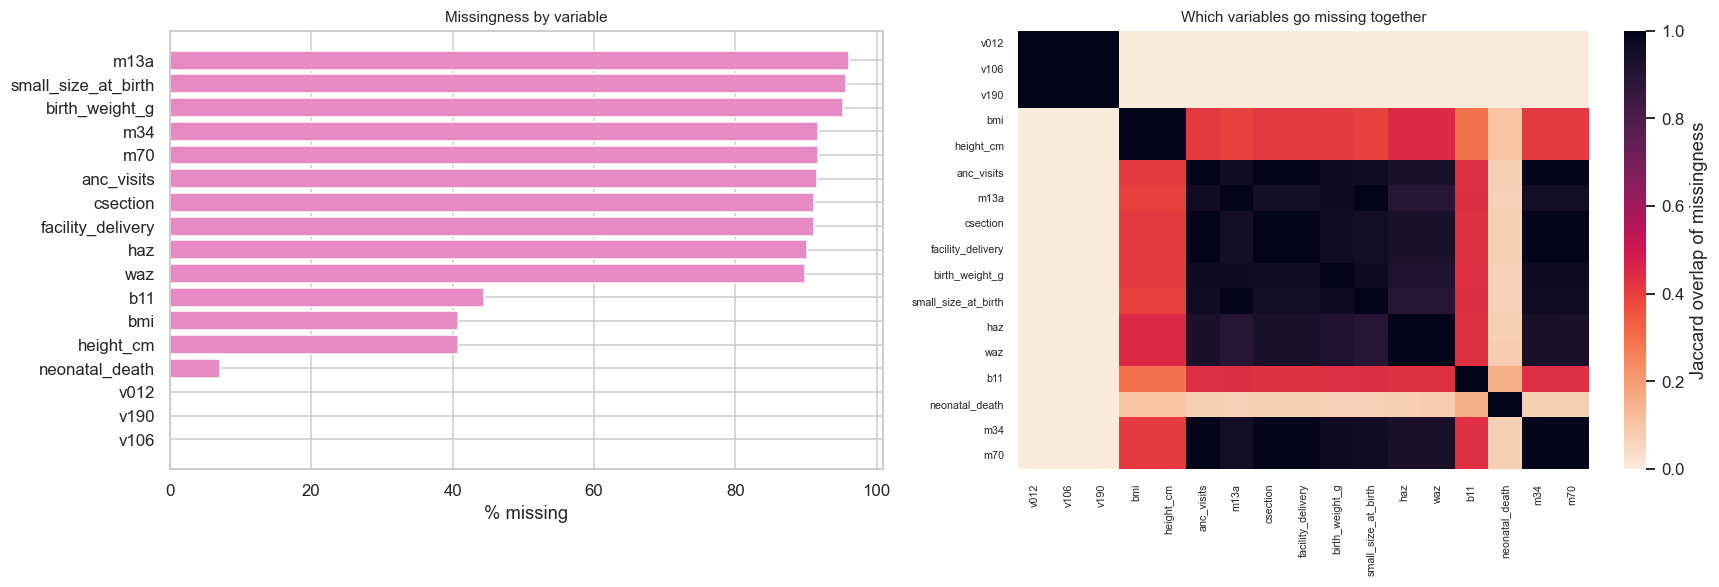

In [19]:
key_vars = [c for c in ["v012", "v106", "v190", "bmi", "height_cm",
                        "anc_visits", "m13a", "csection", "facility_delivery",
                        "birth_weight_g", "small_size_at_birth", "haz", "waz",
                        "b11", "neonatal_death", "m34", "m70"]
            if c in df.columns]

miss = df[key_vars].isna()
pct = miss.mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].barh(pct.index, pct.values, color=sns.color_palette("Set2")[3])
axes[0].set_xlabel("% missing")
axes[0].set_title("Missingness by variable", fontsize=10)
axes[0].invert_yaxis()

jac = pd.DataFrame(index=key_vars, columns=key_vars, dtype=float)
for a in key_vars:
    for b in key_vars:
        both = (miss[a] & miss[b]).sum()
        either = (miss[a] | miss[b]).sum()
        jac.loc[a, b] = both / either if either else 1.0
sns.heatmap(jac.astype(float), cmap="rocket_r", ax=axes[1], vmin=0, vmax=1,
            cbar_kws={"label": "Jaccard overlap of missingness"})
axes[1].set_title("Which variables go missing together", fontsize=10)
axes[1].tick_params(labelsize=7)
plt.tight_layout(); plt.savefig(FIG_DIR / "missingness.png",
                                bbox_inches="tight"); plt.show()

**What this shows.** Left: how much of each variable is missing. Right: a
Jaccard matrix of *which variables go missing together* — 1.0 means two
variables are always missing on exactly the same rows.

The bright blocks are survey **modules**, not data-quality problems. Variables
inside a block share a universe: the maternity module (`csection`,
`facility_delivery`, `anc_visits`, `m34`, `m70`) is asked only of recent births,
and anthropometry (`haz`, `waz`) only of children physically measured.

This is why a global missingness threshold destroys the analysis — it deletes
whole modules at once, and the modules are where the outcomes live.

# 9. Outcome prevalence, with design-based confidence intervals

In [20]:
# Every panel target, plus the descriptive outcomes retained as columns. The
# descriptive ones are marked, because a reader is otherwise entitled to assume
# everything in a prevalence table is something the project predicts.
OUTCOME_COHORT = {t: REGISTRY[t]["cohort"] for t in REGISTRY}
DESCRIPTIVE_COHORT = {
    "csection": "recent_birth", "anc4plus": "recent_birth",
    "low_birth_weight": "recent_birth", "small_size_at_birth": "recent_birth",
    "wasted": "measured_child", "severe_wasting": "measured_child",
    "severe_underweight": "measured_child",
    "infant_death": "births", "under5_death": "births",
    "short_birth_interval": "births",
    "mother_underweight": "mother", "mother_overweight": "mother",
}
ALL_OUTCOMES = {**OUTCOME_COHORT, **DESCRIPTIVE_COHORT}

rows = []
for outcome, coh in ALL_OUTCOMES.items():
    data = cohorts[coh]
    if outcome not in data.columns or data[outcome].notna().sum() == 0:
        continue
    r = estimate(data, outcome)
    r["outcome"] = outcome
    r["cohort"] = coh
    r["role"] = "PANEL" if outcome in REGISTRY else "descriptive"
    rounds = sorted(data.loc[data[outcome].notna(), "survey_round"].unique())
    r["rounds"] = "both" if len(rounds) == 2 else rounds[0]
    rows.append(r)

prev = pd.DataFrame(rows)[["outcome", "role", "cohort", "rounds", "n",
                           "estimate", "ci_low", "ci_high", "deff"]]
display(prev.sort_values(["role", "estimate"]).round(2))

print(f"{(prev['role'] == 'PANEL').sum()} panel targets, "
      f"{(prev['role'] == 'descriptive').sum()} descriptive outcomes.")

,outcome,role,cohort,rounds,n,estimate,ci_low,ci_high,deff
1,neonatal_death,PANEL,births,both,112546,4.03,3.87,4.18,1.82
3,severe_stunting,PANEL,measured_child,both,11954,7.75,7.08,8.42,1.93
4,underweight_child,PANEL,measured_child,both,11950,21.83,20.85,22.82,1.75
2,stunted,PANEL,measured_child,both,11954,28.13,27.04,29.22,1.83
0,facility_delivery,PANEL,recent_birth,both,10773,57.04,55.42,58.66,3.01
10,severe_wasting,descriptive,measured_child,both,11893,1.54,1.29,1.79,1.26
11,severe_underweight,descriptive,measured_child,both,11950,3.99,3.57,4.40,1.40
12,infant_death,descriptive,births,both,112546,5.46,5.28,5.64,1.80
13,under5_death,descriptive,births,both,112546,6.43,6.24,6.63,1.82
9,wasted,descriptive,measured_child,both,11893,9.27,8.66,9.88,1.37


5 panel targets, 11 descriptive outcomes.


**What we can see.** Every outcome with its pooled prevalence, a design-based
confidence interval, and its design effect — panel targets and descriptive
companions labelled separately.

Read `n` alongside `estimate`. `neonatal_death` rests on 112,546 births and has a
tight interval (4.03%, ±0.16); `severe_stunting` rests on 11,954 measured
children and is correspondingly wider. An outcome measured on 12,000 records
cannot support the same claims as one measured on 112,000, and the interval width
says so directly.

Every panel target reads `both` in the `rounds` column, and only one row in the
whole table does not: `small_size_at_birth`, which is 2022-only. That is a
reminder of why single-round availability was one of the constraints that shaped
the panel — the outcomes that failed it, including the immunization measures
asked in 2017-18 alone, are no longer here to be listed.

These pooled prevalences are the right input for modelling but the wrong thing to
quote as national figures — see the per-round validation in section 3.

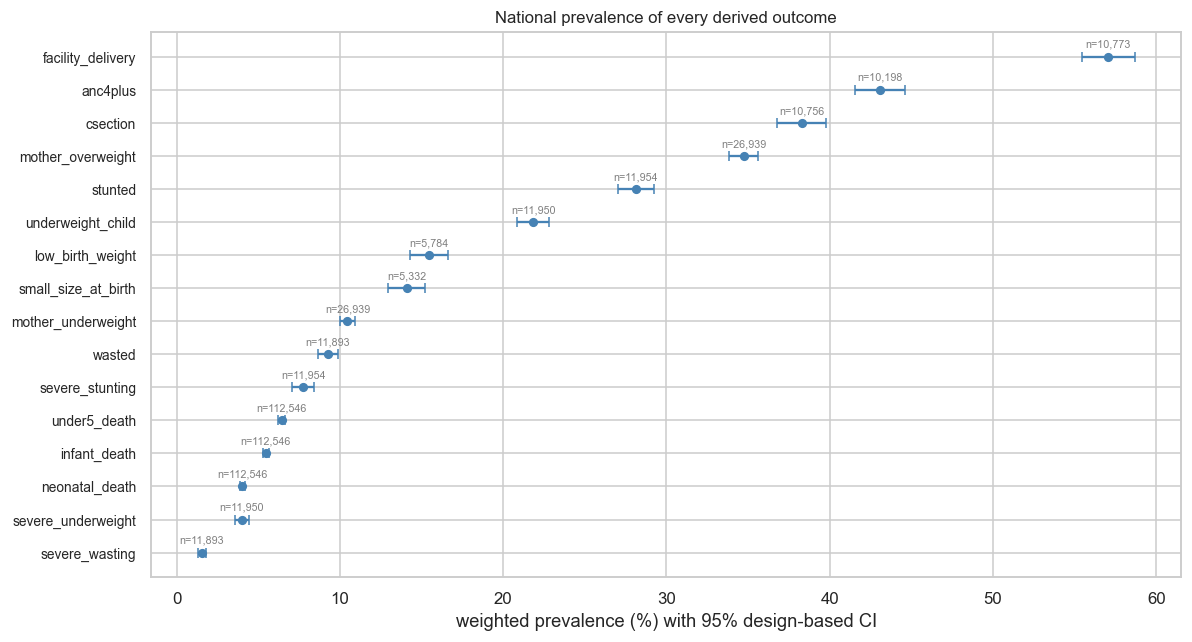

In [21]:
p = prev.sort_values("estimate")
fig, ax = plt.subplots(figsize=(11, 6))
ax.errorbar(p["estimate"], range(len(p)),
            xerr=[p["estimate"] - p["ci_low"], p["ci_high"] - p["estimate"]],
            fmt="o", capsize=3, color="steelblue", ms=5)
ax.set_yticks(range(len(p)))
ax.set_yticklabels(p["outcome"], fontsize=9)
ax.set_xlabel("weighted prevalence (%) with 95% design-based CI")
ax.set_title("National prevalence of every derived outcome", fontsize=11)
for i, (e, n) in enumerate(zip(p["estimate"], p["n"])):
    ax.text(e, i + 0.28, f"n={n:,}", fontsize=7, ha="center", color="grey")
plt.tight_layout(); plt.savefig(FIG_DIR / "outcome_prevalence.png",
                                bbox_inches="tight"); plt.show()

**What this shows.** The same table as a forest plot: point estimate, 95%
interval, sorted by prevalence, annotated with sample size.

The visual point is the **width** of each bar, not its position. The rare
outcomes have intervals that look narrow in absolute percentage points but are
wide *relative to the estimate itself* — neonatal mortality near 3.6% with an
interval spanning several tenths of a point is proportionally large uncertainty.
That relative uncertainty is what limits how confidently notebook 02's models can
be read.

# 10. Bivariate associations

**Every one of the 5 panel targets** against each major predictor, weighted,
with design-based intervals. Chi-square tests are reported with a **Rao–Scott
style correction**: the naive statistic is divided by the mean design effect,
because an uncorrected test on clustered data rejects the null far too often.

Three descriptive outcomes ride along beside the six: **C-section**, **ANC 4+**
and **wasting**. None is a prediction target, and each is here for a reason.
C-section carries the sharpest wealth gradient in the survey and is the reason it
was excluded from the panel. ANC 4+ completes the access story. Wasting is the
control case — an outcome measured on the same children as stunting, in the same
cohort, whose gradient behaves completely differently. All three are labelled
`descriptive` so they can never be mistaken for something a model predicts.

All five panel targets and all three descriptive outcomes are measured in both
survey rounds, so every row here rests on the same pooled population and the
`round` column reads `both` throughout. That was not true of earlier versions of
this panel, and it is one less caveat to carry.

In [22]:
PREDICTORS = ["v190", "v106", "v025", "v024", "v013"]

# All six panel targets, in registry (phase) order, plus three descriptive
# outcomes. C-section carries the steepest wealth gradient in the survey and is
# the reason it was excluded from the panel; anc4plus and wasted are included
# because the contrast between a service-access gradient and a biological one is
# the central finding of this section, and six targets alone do not show it.
FOCUS = list(REGISTRY)
FOCUS_DESCRIPTIVE = ["csection", "anc4plus", "wasted"]
GRADIENT_SET = FOCUS + FOCUS_DESCRIPTIVE

KIND = {t: REGISTRY[t]["kind"] for t in FOCUS}
# The descriptive outcomes still need a direction, because the "who is worse
# off" rule below depends on whether more of the outcome is better or worse.
# Typing all three as "descriptive" made wasting -- an adverse outcome -- read
# as though the richest carried the burden.
KIND["anc4plus"] = "pathway"
KIND["wasted"] = "adverse"
KIND["csection"] = "descriptive"   # genuinely ambiguous; see the commentary

# Which round supports each outcome, so a single-round gradient is never read as
# a national trend.
ROUND_OF = {}
for t in GRADIENT_SET:
    d = cohorts[ALL_OUTCOMES[t]]
    rs = sorted(d.loc[d[t].notna(), "survey_round"].unique())
    ROUND_OF[t] = rs[0] if len(rs) == 1 else "both"

# bivariate() is called by four cells across 9 outcomes x 5 predictors, and
# each call runs a Taylor-linearisation pass per level. Memoise it: the inputs
# never change once the cohorts are loaded.
_BIV_CACHE = {}


def bivariate(outcome, predictor):
    key = (outcome, predictor)
    if key in _BIV_CACHE:
        return _BIV_CACHE[key]
    data = cohorts[ALL_OUTCOMES[outcome]]
    if predictor not in data.columns or outcome not in data.columns:
        _BIV_CACHE[key] = None
        return None
    sub = data[[outcome, predictor, "weight", "_psu", "_strata"]].dropna(
        subset=[outcome, predictor])
    rows = []
    for level, g in sub.groupby(predictor, observed=True):
        if len(g) < 30:
            continue
        p, se, deff = design_se(g[outcome], g["weight"], g["_psu"], g["_strata"])
        rows.append({"level": str(level), "n": len(g),
                     "pct": p * 100, "lo": (p - 1.96 * se) * 100,
                     "hi": (p + 1.96 * se) * 100, "deff": deff})
    if not rows:
        _BIV_CACHE[key] = None
        return None
    res = pd.DataFrame(rows)

    ct = pd.crosstab(sub[predictor], sub[outcome])
    chi2, pval, dof, _ = stats.chi2_contingency(ct)
    mean_deff = np.nanmean(res["deff"]) if res["deff"].notna().any() else 1.0
    chi2_adj = chi2 / max(mean_deff, 1.0)
    pval_adj = 1 - stats.chi2.cdf(chi2_adj, dof)
    _BIV_CACHE[key] = (res, chi2_adj, pval_adj, dof)
    return _BIV_CACHE[key]


summary = []
for outcome in GRADIENT_SET:
    for pred in PREDICTORS:
        out = bivariate(outcome, pred)
        if out is None:
            continue
        res, chi2_adj, pval_adj, dof = out
        summary.append({
            "outcome": outcome, "kind": KIND[outcome], "round": ROUND_OF[outcome],
            "predictor": LABELS.get(pred, pred),
            "range (pp)": round(res["pct"].max() - res["pct"].min(), 1),
            "lowest": f"{res.loc[res.pct.idxmin(),'level']} "
                      f"({res.pct.min():.1f}%)",
            "highest": f"{res.loc[res.pct.idxmax(),'level']} "
                       f"({res.pct.max():.1f}%)",
            "chi2 (adj)": round(chi2_adj, 1), "df": dof,
            "p (adj)": f"{pval_adj:.2e}" if pval_adj < 0.001 else round(pval_adj, 4),
        })

bivar = pd.DataFrame(summary)
with pd.option_context("display.max_rows", 200):
    display(bivar)
print(f"{bivar['outcome'].nunique()} outcomes x {bivar['predictor'].nunique()} "
      f"predictors = {len(bivar)} association tests.")

# The ten steepest gradients in the survey, whatever the outcome.
print("\nSteepest gradients:")
display(bivar.nlargest(10, "range (pp)")[
    ["outcome", "predictor", "range (pp)", "lowest", "highest", "p (adj)"]])

,outcome,kind,round,predictor,range (pp),lowest,highest,chi2 (adj),df,p (adj)
0,facility_delivery,pathway,both,Wealth quintile,48.6,poorest (34.0%),richest (82.6%),779.7,4,0.00e+00
1,facility_delivery,pathway,both,Education,49.1,no education (33.4%),higher (82.5%),653.1,3,0.00e+00
2,facility_delivery,pathway,both,Residence,16.2,rural (52.7%),urban (68.9%),100.3,1,0.00e+00
3,facility_delivery,pathway,both,Division,27.7,sylhet (44.5%),khulna (72.3%),116.8,7,0.00e+00
4,facility_delivery,pathway,both,Age group,9.3,35-39 (49.6%),20-24 (58.9%),8.8,6,0.1829
5,neonatal_death,adverse,both,Wealth quintile,2.1,richest (2.9%),poorest (5.0%),83.9,4,0.00e+00
6,neonatal_death,adverse,both,Education,3.2,higher (2.0%),no education (5.2%),186.8,3,0.00e+00
7,neonatal_death,adverse,both,Residence,0.8,urban (3.5%),rural (4.2%),19.3,1,1.13e-05
8,neonatal_death,adverse,both,Division,1.5,chattogram (3.2%),sylhet (4.7%),52.5,7,4.56e-09
9,neonatal_death,adverse,both,Age group,2.2,20-24 (3.0%),45-49 (5.2%),89.5,6,0.00e+00


8 outcomes x 5 predictors = 40 association tests.

Steepest gradients:


,outcome,predictor,range (pp),lowest,highest,p (adj)
1,facility_delivery,Education,49.1,no education (33.4%),higher (82.5%),0.00e+00
0,facility_delivery,Wealth quintile,48.6,poorest (34.0%),richest (82.6%),0.00e+00
25,csection,Wealth quintile,46.8,poorest (17.6%),richest (64.4%),0.00e+00
31,anc4plus,Education,45.4,no education (20.1%),higher (65.5%),0.00e+00
26,csection,Education,44.0,no education (19.0%),higher (63.1%),0.00e+00
30,anc4plus,Wealth quintile,42.4,poorest (26.4%),richest (68.8%),0.00e+00
28,csection,Division,30.5,sylhet (24.3%),khulna (54.8%),0.00e+00
3,facility_delivery,Division,27.7,sylhet (44.5%),khulna (72.3%),0.00e+00
11,stunted,Education,27.2,higher (14.5%),no education (41.8%),0.00e+00
21,underweight_child,Education,26.1,higher (11.6%),no education (37.7%),0.00e+00


**What this shows.** For every outcome-predictor pair: the spread between the
lowest and highest group in percentage points, which group sits at each end, and
a design-corrected chi-square test.

`range (pp)` is the effect size — how much the outcome varies across levels of
that predictor. A large range with a tiny p-value is a real, strong gradient. A
large range with a weak p-value usually means one thin category is driving it, so
check `n` before believing it.

The chi-square is divided by the mean design effect before the p-value is taken.
Without that correction, clustering makes almost everything look overwhelmingly
significant, because the test believes it has far more independent observations
than it does.

**Read the `range (pp)` column down the table, not across.** It is directly
comparable between outcomes, and that comparison is the point of including the
descriptive outcomes alongside the panel: the service-access outcomes (facility
delivery, ANC, C-section) show ranges of 30–50 points across wealth, while the
biological ones (neonatal death, wasting) move only a few points. Access is what
wealth buys. Survival, much less so.

The `round` column reads `both` throughout, so every gradient here describes the
same pooled population.

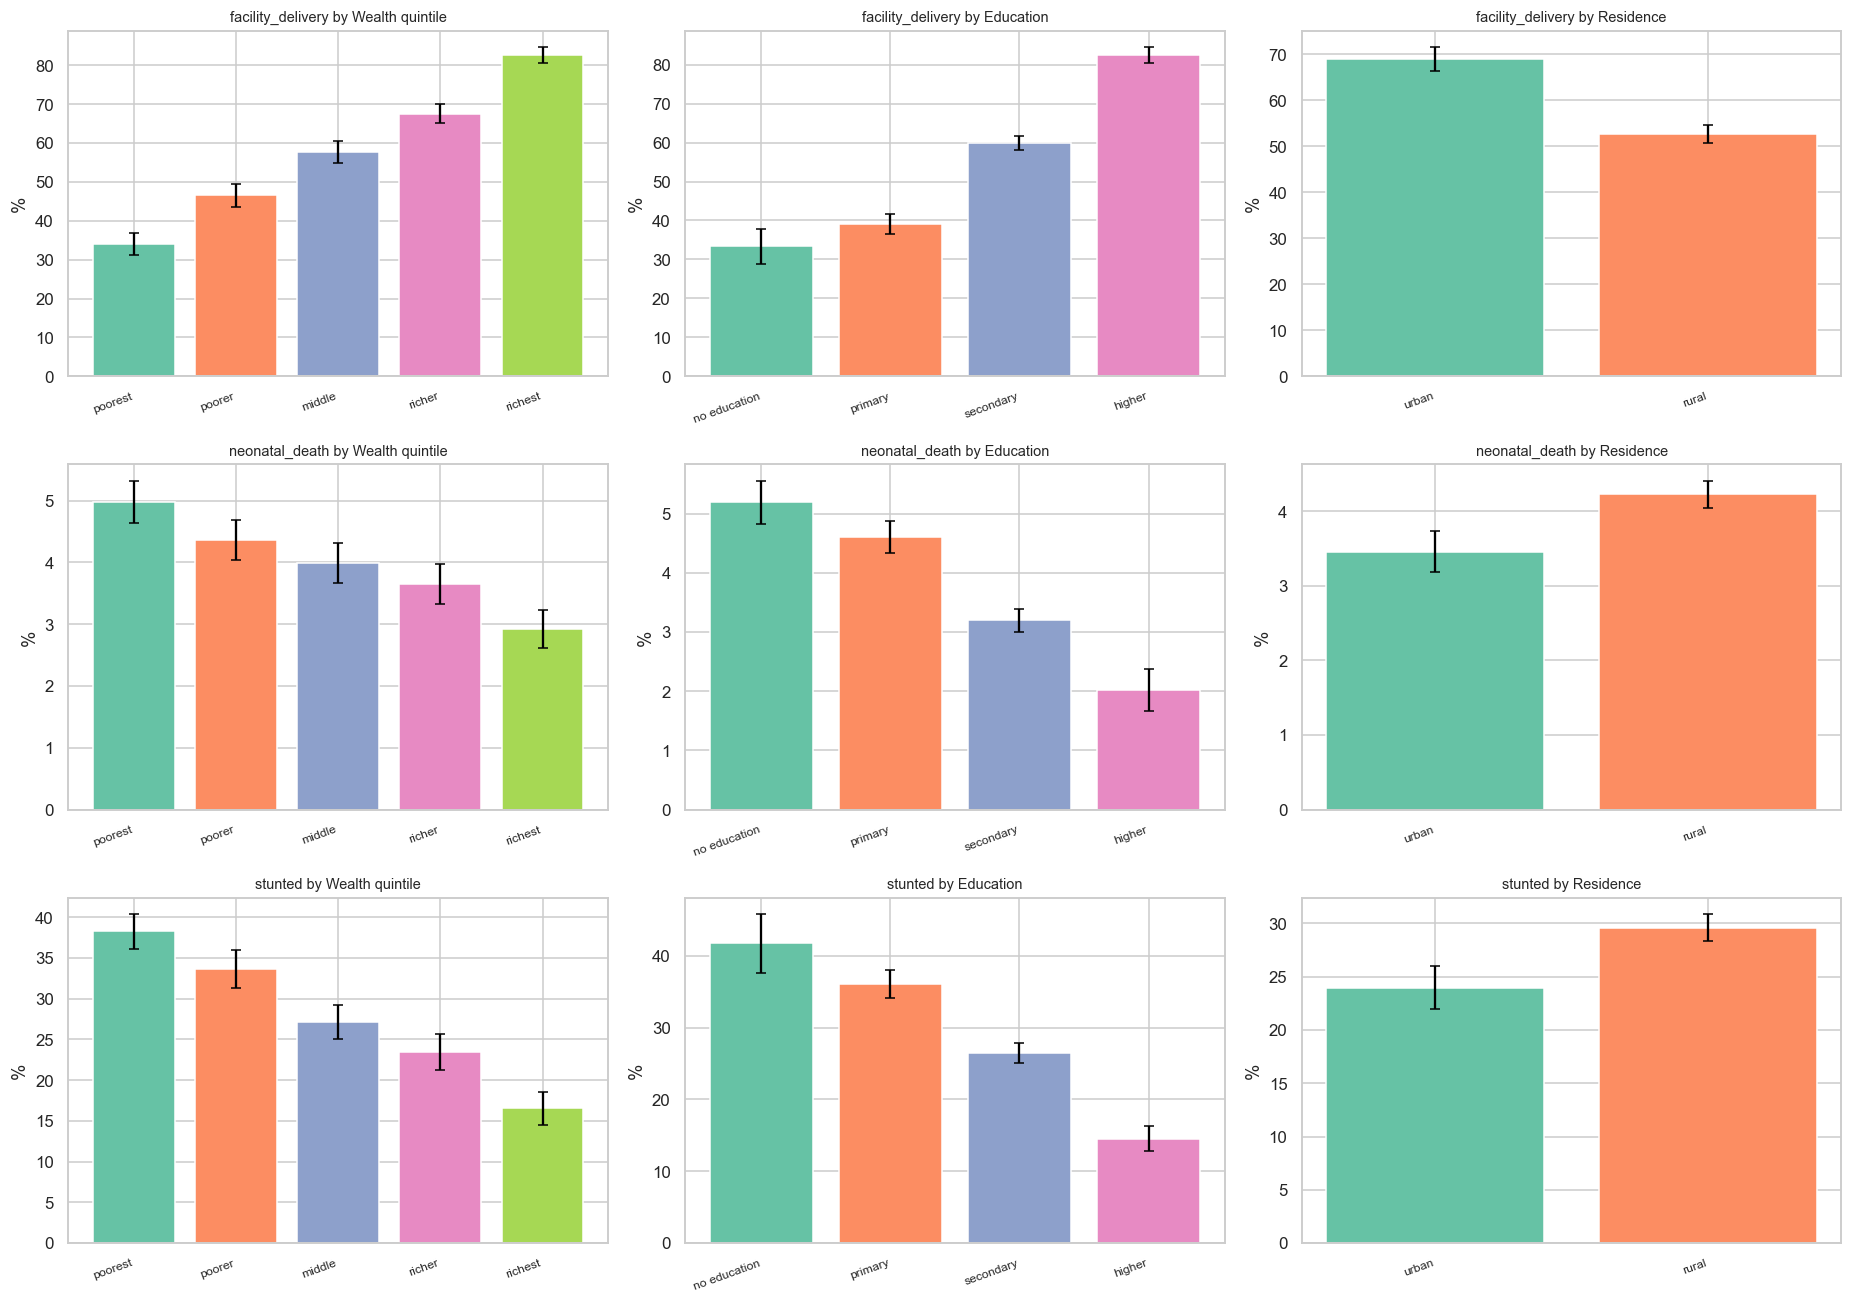

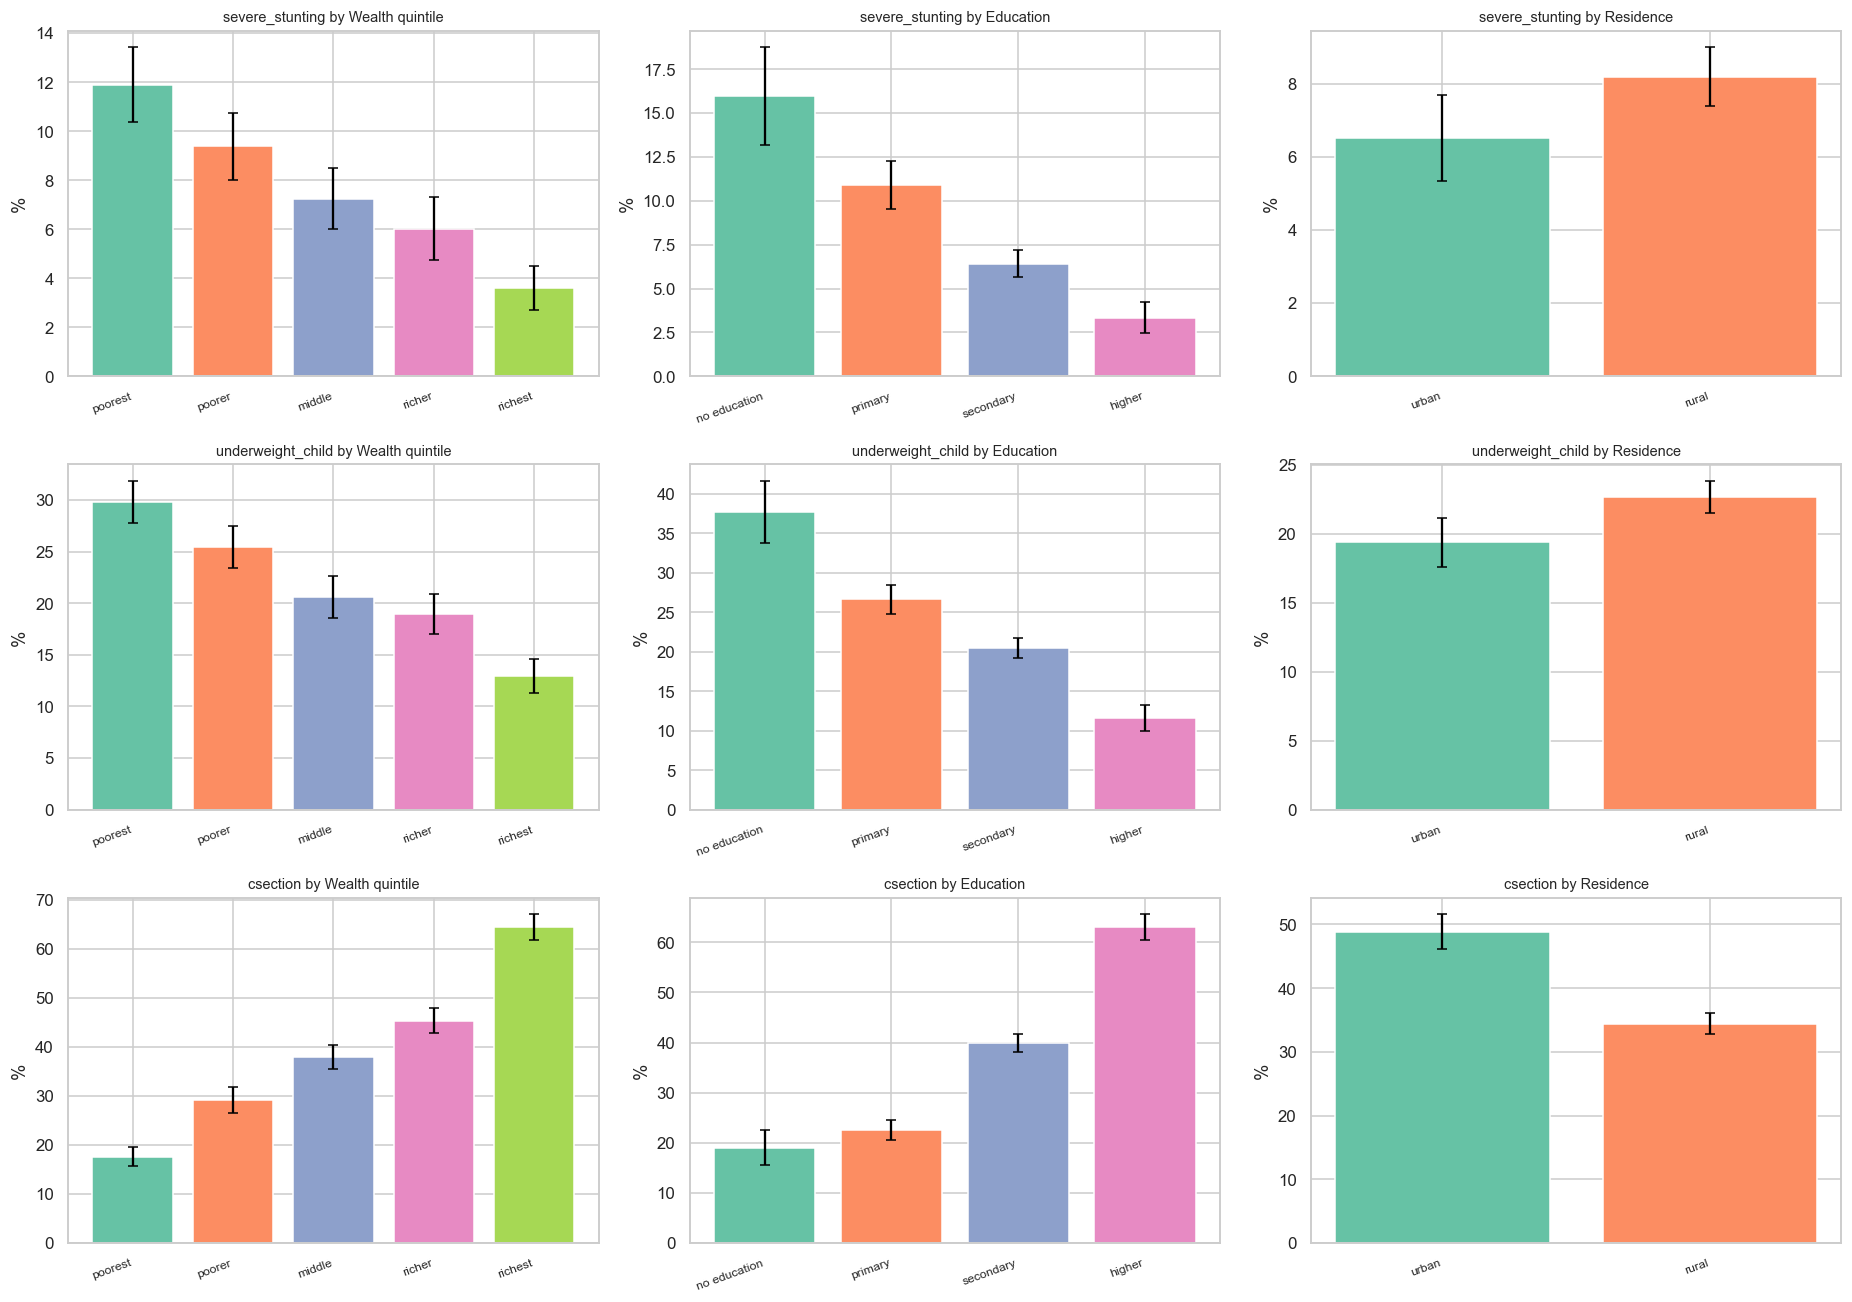

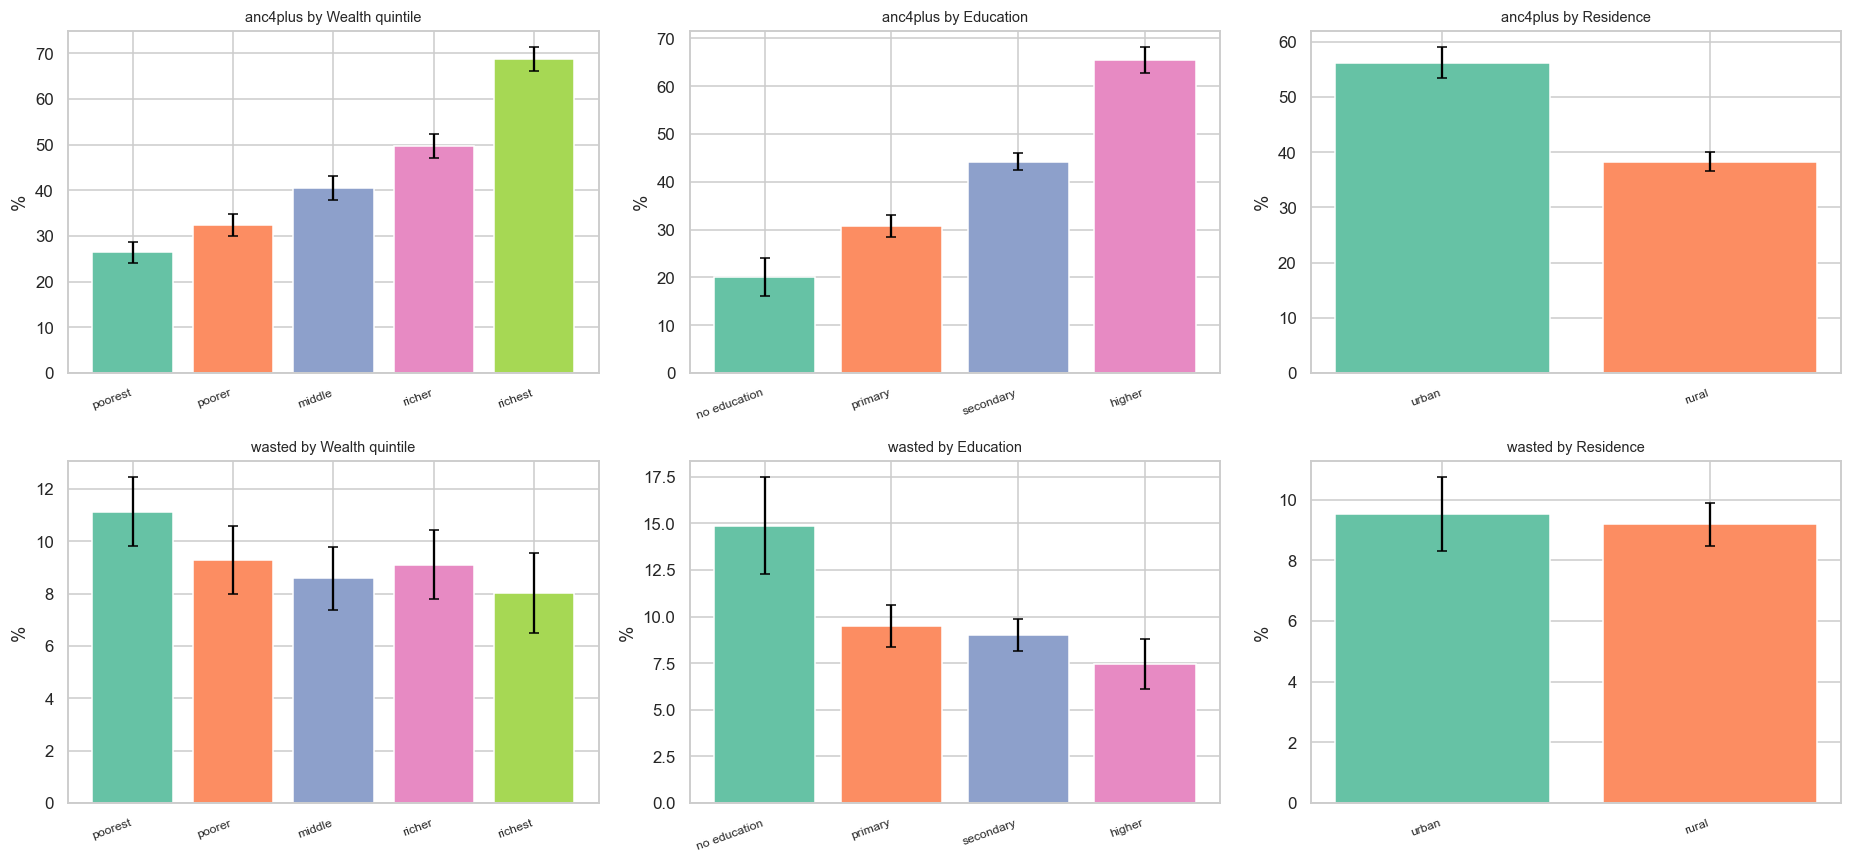

8 outcomes over 3 figures, saved as bivariate_1..n.png


In [23]:
# Nine outcomes x three predictors is 27 panels -- one figure that tall is
# unreadable and unsavable. Chunked into blocks of three outcomes instead, which
# keeps every panel at the same scale as before.
CHUNK = 3
PANEL_PREDS = ["v190", "v106", "v025"]
ORDER = {"v190": ["poorest", "poorer", "middle", "richer", "richest"],
         "v106": ["no education", "primary", "secondary", "higher"],
         "v025": ["urban", "rural"]}

for start in range(0, len(GRADIENT_SET), CHUNK):
    block = GRADIENT_SET[start:start + CHUNK]
    fig, axes = plt.subplots(len(block), 3, figsize=(17, 4 * len(block)),
                             squeeze=False)
    for i, outcome in enumerate(block):
        for j, pred in enumerate(PANEL_PREDS):
            ax = axes[i, j]
            out = bivariate(outcome, pred)
            if out is None:
                ax.set_visible(False)
                continue
            res = out[0].set_index("level").reindex(
                [o for o in ORDER[pred] if o in set(out[0]["level"])]
            ).reset_index()
            ax.bar(range(len(res)), res["pct"], color=sns.color_palette("Set2"),
                   yerr=[res["pct"] - res["lo"], res["hi"] - res["pct"]],
                   capsize=3)
            ax.set_xticks(range(len(res)))
            ax.set_xticklabels(res["level"], rotation=20, ha="right", fontsize=8)
            ax.set_ylabel("%")
            tag = "" if ROUND_OF[outcome] == "both" else f"  [{ROUND_OF[outcome]}]"
            ax.set_title(f"{outcome} by {LABELS.get(pred, pred)}{tag}",
                         fontsize=9.5)
    page = start // CHUNK + 1
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"bivariate_{page}.png", bbox_inches="tight")
    plt.show()

print(f"{len(GRADIENT_SET)} outcomes over "
      f"{-(-len(GRADIENT_SET) // CHUNK)} figures, saved as bivariate_1..n.png")

**What this shows.** Every outcome against wealth, education and residence, with
error bars, three outcomes per figure. Where bars step monotonically there is a
genuine gradient; where error bars overlap heavily there is not, regardless of
what the p-value says.

**The C-section row deserves the hardest look.** Its wealth gradient is steep and
monotonic — 17.6% in the poorest quintile against 64.4% in the richest — and it
does **not** plausibly reflect obstetric need, because medical indications for
caesarean do not track household wealth. It reflects access at the bottom and
over-use at the top. That single row is the most policy-relevant finding in this
notebook, and it is why C-section was kept here as a description after being
dropped as a prediction target.

**Contrast the neonatal-death row**, whose gradient is much flatter — 5.0% to
2.9%, a 2.1-point range against facility delivery's 48.6. Mortality is driven by
biological and intrapartum factors that wealth cannot fully buy away, which is
exactly why it is worth modelling rather than merely tabulating.

**The nutrition rows sit between the two.** Stunting falls from 38.3% to 16.5%
and underweight from 29.9% to 12.9% — steep, because chronic undernutrition
accumulates over years of household conditions. `wasted` is included as a
descriptive contrast precisely because it does *not* follow: it moves 3.1 points,
because acute wasting is a response to a recent shock rather than to standing
circumstances. Two outcomes measured on the same children, in the same cohort,
with completely different gradients.

That contrast predicts what notebook 02 finds: socio-economic features carry most
of the signal for the chronic nutrition targets and very little for the acute
ones. It is also why `wasted` is not in the panel — at ROC-AUC 0.588 with recall
0.005, the flat gradient shown here is what a model sees too.

# 11. Equity gradients

Two summary measures used throughout the health-equity literature, computed for
**all five panel targets** plus the three descriptive outcomes:

- **Absolute gap** — richest minus poorest, in percentage points.
- **Ratio** — richest divided by poorest.

Direction of harm depends on the outcome's `kind`, which is why it is carried
into the table rather than left to the reader:

- A large gap on a **pathway** outcome (facility delivery) means the poor are
  underserved — the gap should be positive and we want it smaller.
- A large *negative* gap on an **adverse** outcome (stunting, neonatal death) is
  the same finding wearing the opposite sign: the poor carry more of it.
- A large gap on **C-section** can mean something different again — over-use
  among the rich rather than under-use among the poor.

In [24]:
rows = []
for outcome in GRADIENT_SET:
    out = bivariate(outcome, "v190")
    if out is None:
        continue
    res = out[0].set_index("level")
    if not {"poorest", "richest"}.issubset(res.index):
        continue
    lo, hi = res.loc["poorest", "pct"], res.loc["richest", "pct"]
    gap = hi - lo
    # "Who is worse off" is not the sign of the gap -- it depends on whether the
    # outcome is something you want or something you don't.
    if KIND[outcome] == "adverse":
        disadvantaged = "poorest" if gap < 0 else "richest"
    else:
        disadvantaged = "poorest" if gap > 0 else "richest"
    rows.append({"outcome": outcome, "kind": KIND[outcome],
                 "round": ROUND_OF[outcome],
                 "poorest %": round(lo, 1), "richest %": round(hi, 1),
                 "absolute gap (pp)": round(gap, 1),
                 "ratio richest/poorest": round(hi / lo, 2) if lo > 0 else np.nan,
                 "worse off": disadvantaged})

equity = pd.DataFrame(rows).sort_values(
    "absolute gap (pp)", key=abs, ascending=False).reset_index(drop=True)
with pd.option_context("display.max_rows", 100):
    display(equity)

print(f"{len(equity)} outcomes with a full wealth gradient. "
      f"The poorest quintile is worse off on "
      f"{(equity['worse off'] == 'poorest').sum()} of them.")

,outcome,kind,round,poorest %,richest %,absolute gap (pp),ratio richest/poorest,worse off
0,facility_delivery,pathway,both,34.0,82.6,48.6,2.43,poorest
1,csection,descriptive,both,17.6,64.4,46.8,3.65,poorest
2,anc4plus,pathway,both,26.4,68.8,42.4,2.60,poorest
3,stunted,adverse,both,38.3,16.5,-21.7,0.43,poorest
4,underweight_child,adverse,both,29.9,12.9,-16.9,0.43,poorest
5,severe_stunting,adverse,both,11.9,3.6,-8.3,0.30,poorest
6,wasted,adverse,both,11.1,8.0,-3.1,0.72,poorest
7,neonatal_death,adverse,both,5.0,2.9,-2.1,0.59,poorest


8 outcomes with a full wealth gradient. The poorest quintile is worse off on 8 of them.


**What this shows.** Poorest and richest quintile side by side for every outcome,
with the absolute gap in percentage points, the ratio between them, and which
quintile ends up worse off once the outcome's direction is taken into account.

The two measures answer different questions and can disagree. A rare outcome can
show a huge *ratio* on a trivial *absolute* gap — 1% versus 4% is a 4x ratio but
only 3 percentage points, which matters far less for planning than a 20-point gap
on a common outcome. Report both; lead with the absolute gap when the discussion
is about allocating resources.

The table is sorted by **absolute** gap size, ignoring sign, so the outcomes that
divide Bangladesh most sharply sit at the top regardless of direction. Note how
consistently the `worse off` column reads `poorest`: across service access,
nutrition and mortality alike, in different directions and on wildly different
scales, the gradient points the same way. That consistency is
the finding — not any single row.

The column depends on knowing whether more of an outcome is better or worse,
which is why `kind` is carried alongside it. Getting that wrong is easy and
silent: an earlier version typed `wasted` as merely *descriptive*, the rule fell
through to its pathway branch, and a 3.1-point deficit in the poorest quintile
was reported as the richest being worse off.

**Read the C-section row against its own logic, not the column.** The `worse off`
rule treats it like a pathway outcome, so a 46.8-point gap in favour of the
richest reads as `poorest`. Under-service at the bottom is certainly part of it —
17.6% in the poorest quintile is below the level obstetric need would justify —
but 64.4% at the top is far above it. Both ends are wrong, in opposite
directions, and no single-signed measure can express that.

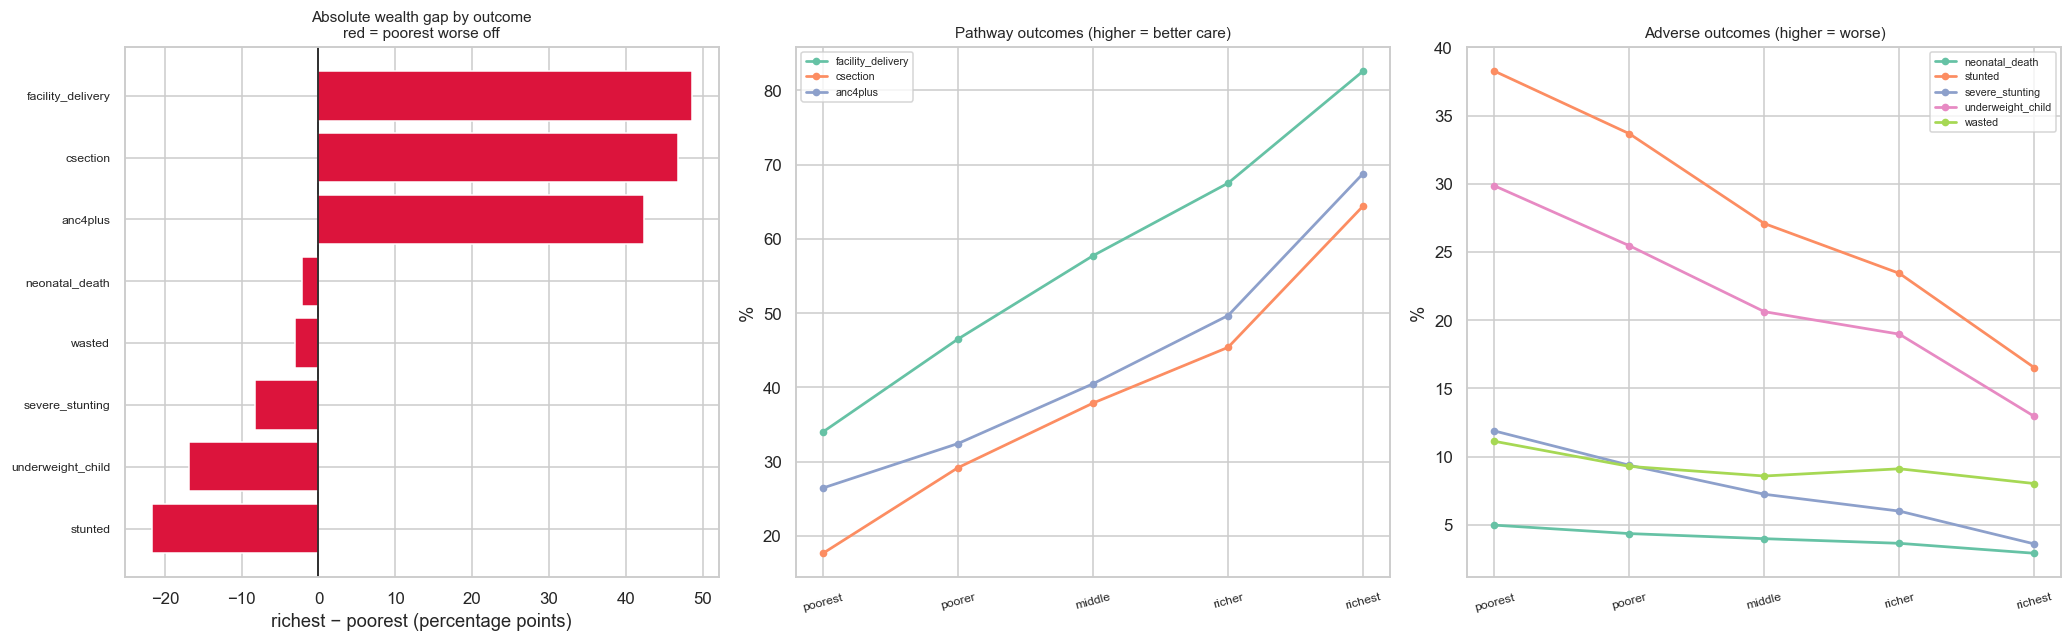

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(19, max(6, 0.42 * len(equity))))

# Left: every gap on one axis, coloured by who carries the disadvantage.
e = equity.sort_values("absolute gap (pp)")
axes[0].barh(e["outcome"], e["absolute gap (pp)"],
             color=["crimson" if w == "poorest" else "steelblue"
                    for w in e["worse off"]])
axes[0].axvline(0, color="black", lw=1)
axes[0].set_xlabel("richest − poorest (percentage points)")
axes[0].set_title("Absolute wealth gap by outcome\n"
                  "red = poorest worse off", fontsize=10)
axes[0].tick_params(axis="y", labelsize=8)

# Right two: gradient shape, split by direction. Sixteen lines on one axis is an
# unreadable legend; split by kind and each panel also becomes interpretable,
# since within a panel "higher line" means the same thing for every series.
for ax, kinds, title in [
        (axes[1], {"pathway", "descriptive"}, "Pathway outcomes (higher = better care)"),
        (axes[2], {"adverse"}, "Adverse outcomes (higher = worse)")]:
    for outcome in GRADIENT_SET:
        if KIND[outcome] not in kinds:
            continue
        out = bivariate(outcome, "v190")
        if out is None:
            continue
        res = out[0].set_index("level").reindex(
            ["poorest", "poorer", "middle", "richer", "richest"]).dropna()
        if len(res) < 5:
            continue
        ax.plot(range(len(res)), res["pct"], "o-", label=outcome, lw=1.8, ms=4)
    ax.set_xticks(range(5))
    ax.set_xticklabels(["poorest", "poorer", "middle", "richer", "richest"],
                       rotation=15, fontsize=8)
    ax.set_ylabel("%")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, ncol=1)

plt.tight_layout(); plt.savefig(FIG_DIR / "equity.png",
                                bbox_inches="tight"); plt.show()

**What this shows.** Left: the absolute wealth gap for every outcome, coloured by
who carries the disadvantage. Middle and right: the full five-quintile gradient,
split by direction so that "higher line" means one consistent thing within each
panel — better care on the left, worse health on the right.

Shape carries meaning the endpoints hide. A straight line means each step up in
wealth buys a similar increment. A curve that is flat across the bottom four
quintiles and jumps at the richest means the advantage is concentrated in the top
group — a different problem requiring a different response.

Two shapes to look for:

- **Steep and straight** — facility delivery, C-section, ANC. Every quintile step
  buys measurably more care. These are access problems, and access responds to
  money, which means it also responds to policy.
- **Flat, or nearly so** — wasting and neonatal death. Wealth changes little,
  because the mechanism is not primarily purchasing power.

The adverse panel is worth reading for its *vertical spread* as much as its
slopes. Outcomes cluster by how common they are, and a 20-point gradient on
something affecting 30% of children is a far larger public-health quantity than a
2-point gradient on something affecting 4% — even though the second may have the
more dramatic ratio.

# 12. Geography — the eight divisions

In [26]:
rows = []
for div, g in cohorts["recent_birth"].groupby("v024", observed=True):
    row = {"division": str(div), "n": len(g)}
    for outcome in ["csection", "facility_delivery", "anc4plus",
                    "small_size_at_birth"]:
        if outcome in g.columns and g[outcome].notna().sum() > 30:
            p, se, _ = design_se(g[outcome], g["weight"], g["_psu"], g["_strata"])
            row[outcome] = round(p * 100, 1)
    rows.append(row)

geo = pd.DataFrame(rows)
for div, g in cohorts["births"].groupby("v024", observed=True):
    if "neonatal_death" in g.columns:
        p, _, _ = design_se(g["neonatal_death"], g["weight"], g["v021"], g["v022"])
        geo.loc[geo.division == str(div), "neonatal_death"] = round(p * 100, 2)

display(geo.sort_values("csection", ascending=False))

,division,n,csection,facility_delivery,anc4plus,small_size_at_birth,neonatal_death
3,khulna,1152,54.8,72.3,49.5,11.3,4.00
2,dhaka,1590,47.8,64.1,49.3,16.1,3.82
5,rajshahi,1093,44.0,61.6,42.6,11.1,4.63
6,rangpur,1213,34.9,55.0,46.6,12.8,4.64
4,mymensingh,1316,31.8,46.2,45.0,11.0,4.73
0,barishal,1144,31.2,46.3,32.3,12.5,3.40
1,chattogram,1843,28.2,52.4,37.3,15.8,3.21
7,sylhet,1422,24.3,44.5,32.3,17.8,4.73


**What this shows.** All eight divisions, sorted by C-section rate, with each key
indicator side by side.

The question to ask is whether one division lags on *everything* or whether
divisions trade off. A division at the bottom for C-section and facility delivery
and at the top for neonatal mortality shows a consistent service-availability
problem. A division doing well on ANC but poorly on facility delivery tells a
different story — women are reaching the system antenatally but not delivering in
it, which is a referral and transport problem, not an awareness one.

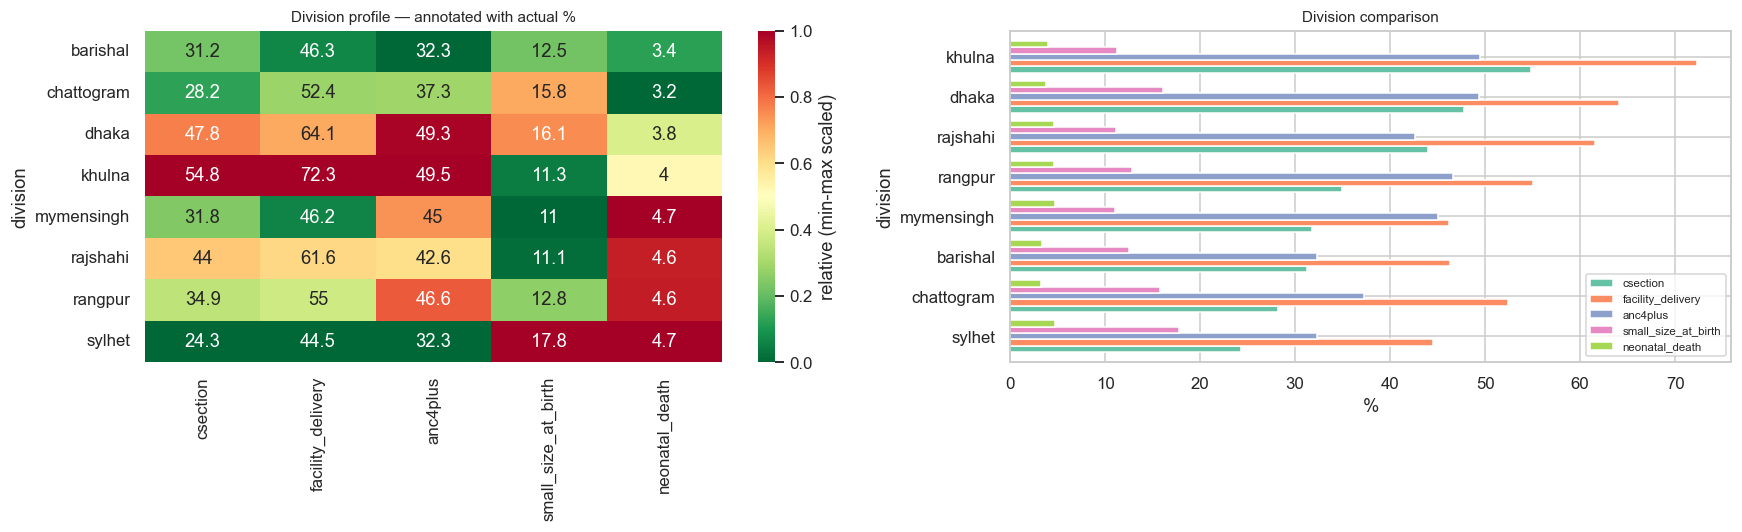

In [27]:
plot_geo = geo.set_index("division")[
    ["csection", "facility_delivery", "anc4plus", "small_size_at_birth",
     "neonatal_death"]].dropna(how="all")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
norm = (plot_geo - plot_geo.min()) / (plot_geo.max() - plot_geo.min())
sns.heatmap(norm, annot=plot_geo.round(1), fmt="g", cmap="RdYlGn_r",
            ax=axes[0], cbar_kws={"label": "relative (min-max scaled)"})
axes[0].set_title("Division profile — annotated with actual %", fontsize=10)

plot_geo.sort_values("csection").plot.barh(ax=axes[1], width=0.8)
axes[1].set_xlabel("%")
axes[1].set_title("Division comparison", fontsize=10)
axes[1].legend(fontsize=7.5)
plt.tight_layout(); plt.savefig(FIG_DIR / "geography.png",
                                bbox_inches="tight"); plt.show()

**What this shows.** The same eight divisions as a heatmap and as grouped bars.

Colour is min-max scaled **within each column**, so a dark cell means "worst among
the eight divisions", not "bad in absolute terms". The printed annotation is the
real percentage — always read the number alongside the colour.

# 13. Correlation and multicollinearity — per cohort

Correlation shows redundancy between predictors. Redundancy matters because it
changes what a model's coefficients and feature importances *mean*, not because
it necessarily hurts accuracy.

Everything here is computed **per cohort**. A correlation on the pooled master
would be an artefact: two columns belonging to different modules are non-missing
on disjoint sets of rows, so their correlation describes the survey's structure
rather than any relationship between them.

Three views per cohort — the full matrix, the pairs that break a |r| = 0.85
threshold, and the features that break nothing at all. **VIF** then asks a
sharper question than any pair can: whether a feature is reconstructable from
*all* the others together.

,numeric features,pairs,pairs > 0.85,% of pairs,max |r|,most independent,its max |r|
cohort,,,,,,,
recent_birth,39,1521,8,0.53,0.996,eligible_under5,0.137
measured_child,37,1369,9,0.66,0.995,eligible_neonatal,0.272
mother,35,1225,10,0.82,0.994,p20,0.133
births,29,841,4,0.48,0.935,p20,0.104


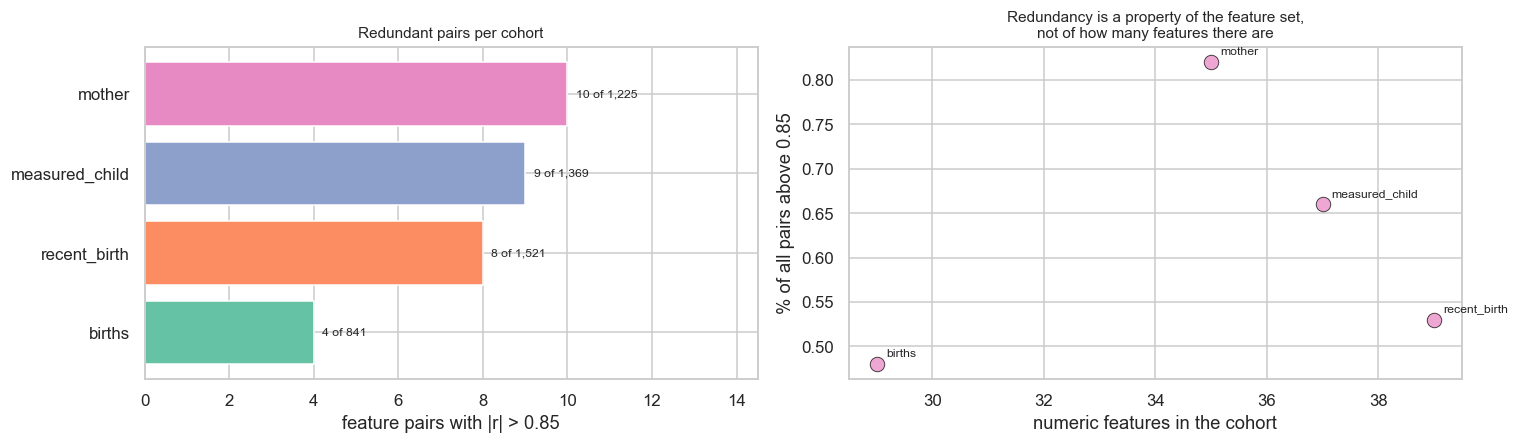

In [28]:
# Correlation is computed per cohort, never on the pooled master. The master
# stacks seven universes, so a pair of columns can look uncorrelated there simply
# because they are non-missing on disjoint sets of rows.
CORR_THRESHOLD = 0.85

# Design and bookkeeping columns are not features. Correlating them produces
# structure that is real but meaningless -- v001 and v021 are both cluster ids.
NON_FEATURES = {"v001", "v005", "v021", "v022", "v023", "_psu", "_strata",
                "v008", "v011", "v016", "v017", "v006", "v007",
                "weight", "b3", "p3", "pidx",
                # p17 runs 1-31, near-uniform, mean 14.36 -- a day of month.
                # It correlates with nothing by construction, so leaving it in
                # would put a bookkeeping field at the top of the "carries
                # unique information" panel. See the note under section 13.
                "p17"}


def numeric_block(name, min_coverage=0.5):
    """The numeric feature matrix a model would actually see for this cohort."""
    d = cohorts[name]
    num = d.select_dtypes(include=[np.number])
    num = num.loc[:, num.notna().mean() > min_coverage]
    num = num.drop(columns=[c for c in num.columns if c in NON_FEATURES],
                   errors="ignore")
    return num.loc[:, num.std() > 0]


def corr_parts(name):
    """Correlation matrix, its upper-triangle pair list, and per-feature maxima."""
    num = numeric_block(name)
    corr = num.corr(numeric_only=True)
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (upper.stack().rename("abs r").reset_index()
             .rename(columns={"level_0": "feature A", "level_1": "feature B"})
             .sort_values("abs r", ascending=False).reset_index(drop=True))
    # Strongest tie each feature has to any other -- low values mean the column
    # carries information nothing else in the cohort duplicates.
    strongest = (corr.abs().where(~np.eye(len(corr), dtype=bool))
                 .max().sort_values())
    return num, corr, pairs, strongest


summary = []
for name in cohorts:
    num, corr, pairs, strongest = corr_parts(name)
    over = pairs[pairs["abs r"] > CORR_THRESHOLD]
    summary.append({
        "cohort": name,
        "numeric features": num.shape[1],
        "pairs": len(pairs),
        f"pairs > {CORR_THRESHOLD}": len(over),
        "% of pairs": round(len(over) / max(len(pairs), 1) * 100, 2),
        "max |r|": round(float(pairs["abs r"].max()), 3),
        "most independent": strongest.index[0],
        "its max |r|": round(float(strongest.iloc[0]), 3),
    })

corr_summary = pd.DataFrame(summary).sort_values("numeric features",
                                                 ascending=False)
display(corr_summary.set_index("cohort"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
cs = corr_summary.sort_values(f"pairs > {CORR_THRESHOLD}")
axes[0].barh(cs["cohort"], cs[f"pairs > {CORR_THRESHOLD}"],
             color=sns.color_palette("Set2"))
axes[0].set_xlabel(f"feature pairs with |r| > {CORR_THRESHOLD}")
axes[0].set_title("Redundant pairs per cohort", fontsize=10)
for i, (_, r) in enumerate(cs.iterrows()):
    axes[0].text(r[f"pairs > {CORR_THRESHOLD}"] + 0.2, i,
                 f"{r[f'pairs > {CORR_THRESHOLD}']} of {r['pairs']:,}",
                 va="center", fontsize=8)
axes[0].set_xlim(right=cs[f"pairs > {CORR_THRESHOLD}"].max() * 1.45)

axes[1].scatter(corr_summary["numeric features"],
                corr_summary["% of pairs"], s=90, alpha=0.75,
                color=sns.color_palette("Set2")[3], edgecolor="black", lw=0.6)
for _, r in corr_summary.iterrows():
    axes[1].annotate(r["cohort"], (r["numeric features"], r["% of pairs"]),
                     fontsize=8, xytext=(6, 5), textcoords="offset points")
axes[1].set_xlabel("numeric features in the cohort")
axes[1].set_ylabel(f"% of all pairs above {CORR_THRESHOLD}")
axes[1].set_title("Redundancy is a property of the feature set,\n"
                  "not of how many features there are", fontsize=10)

plt.tight_layout(); plt.savefig(FIG_DIR / "correlation_summary.png",
                                bbox_inches="tight"); plt.show()

**What we can see.** Redundancy measured separately in each cohort, because a
correlation computed on the pooled master would be meaningless: the master stacks
several nested universes, so two columns can appear uncorrelated there purely
because they are non-missing on disjoint sets of rows.

```
cohort           features   pairs   pairs > 0.85   % of pairs   max |r|
recent_birth           39    1521              8         0.53     0.996
measured_child         37    1369              9         0.66     0.995
mother                 35    1225             10         0.82     0.994
births                 29     841              4         0.48     0.935
```

Every cohort carries roughly the same small number of redundant pairs — between
4 and 10 above |r| = 0.85, out of 841 to 1,521 pairs. That is between 0.48% and
0.82%, consistently **under 1%**, which is the expected result: the shared
feature core was assembled deliberately rather than scraped.

**More features does not mean more redundancy.** `recent_birth` has the most
numeric columns (39) and a redundant fraction of 0.53%, while `mother` has four
fewer columns and the highest fraction in the panel at 0.82%. Redundancy is a
property of *which* features a cohort holds, not how many — and `mother` holds
the full fertility-accounting block, which is the densest cluster in the data.

**`births` is the cleanest cohort, and not by accident.** It has the fewest
redundant pairs (4) and much the lowest `max |r|` (0.935), because the entire
`v201`/`v218`/`v219`/`v220` family is blacklisted for `neonatal_death` and never
reaches the feature matrix. The blacklist from notebook 01 is visible here as a
measurable drop in redundancy.

**No pair reaches 1.000.** The highest is 0.996, and it is examined below along
with the two other families that clear the threshold.

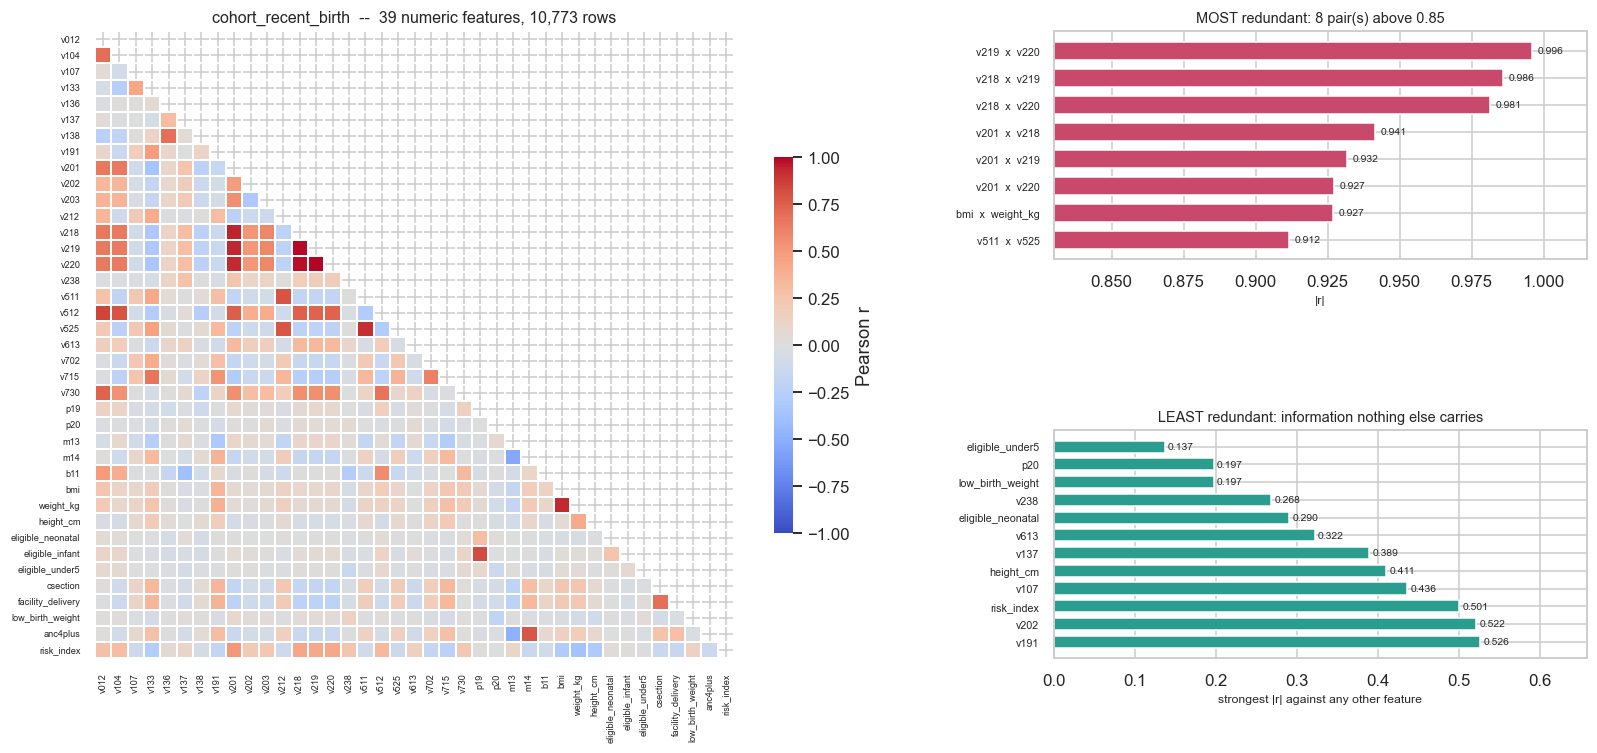

cohort_recent_birth: top redundant pairs


,feature A,feature B,abs r
0,v219,v220,0.995884
1,v218,v219,0.985868
2,v218,v220,0.981480
3,v201,v218,0.941411
4,v201,v219,0.931689
5,v201,v220,0.927147
6,bmi,weight_kg,0.926775
7,v511,v525,0.911503


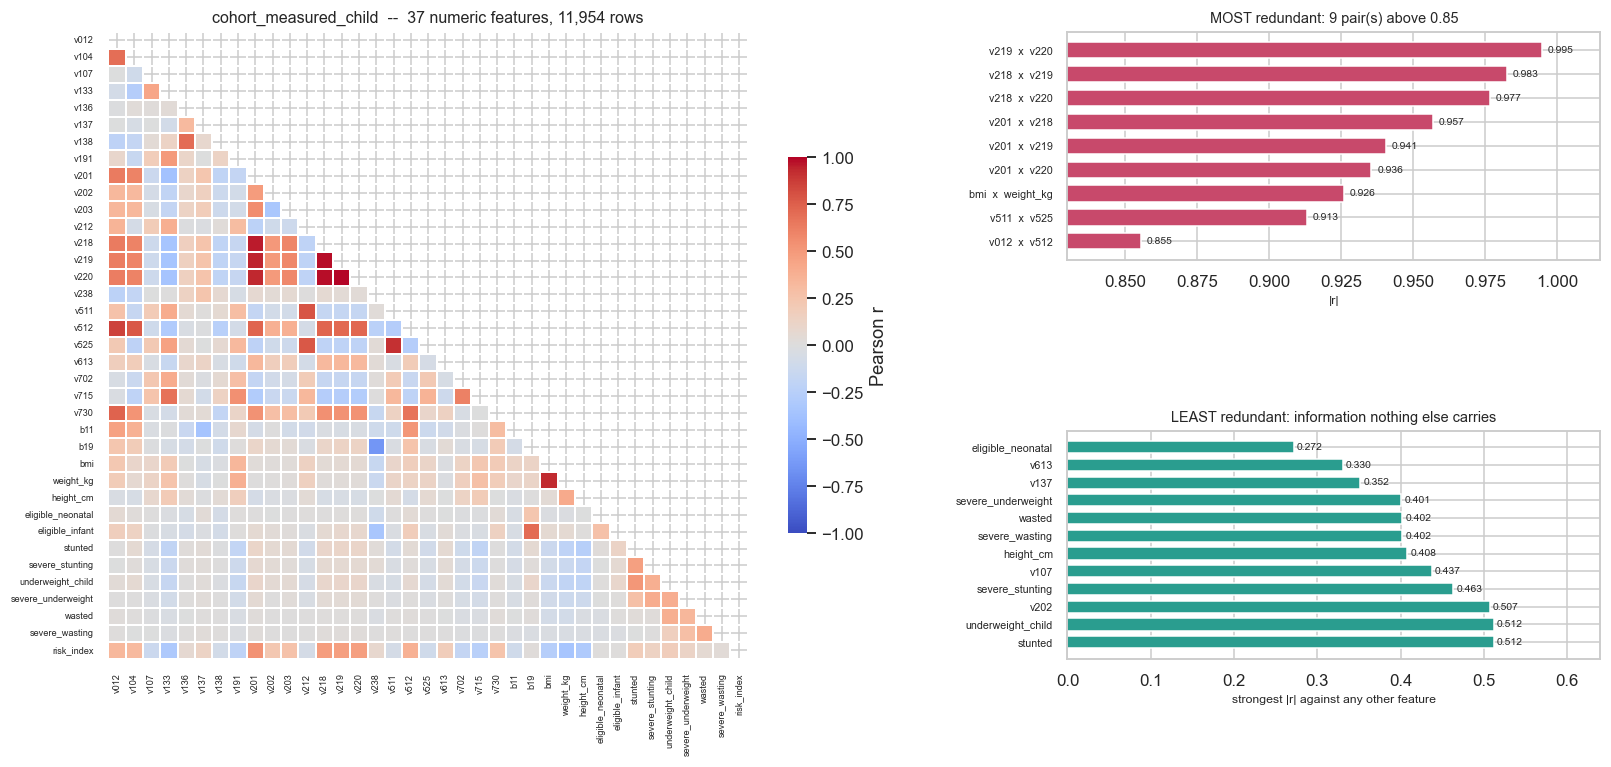

cohort_measured_child: top redundant pairs


,feature A,feature B,abs r
0,v219,v220,0.994660
1,v218,v219,0.982725
2,v218,v220,0.976818
3,v201,v218,0.956852
4,v201,v219,0.940554
5,v201,v220,0.935547
6,bmi,weight_kg,0.926081
7,v511,v525,0.913042
8,v012,v512,0.855445


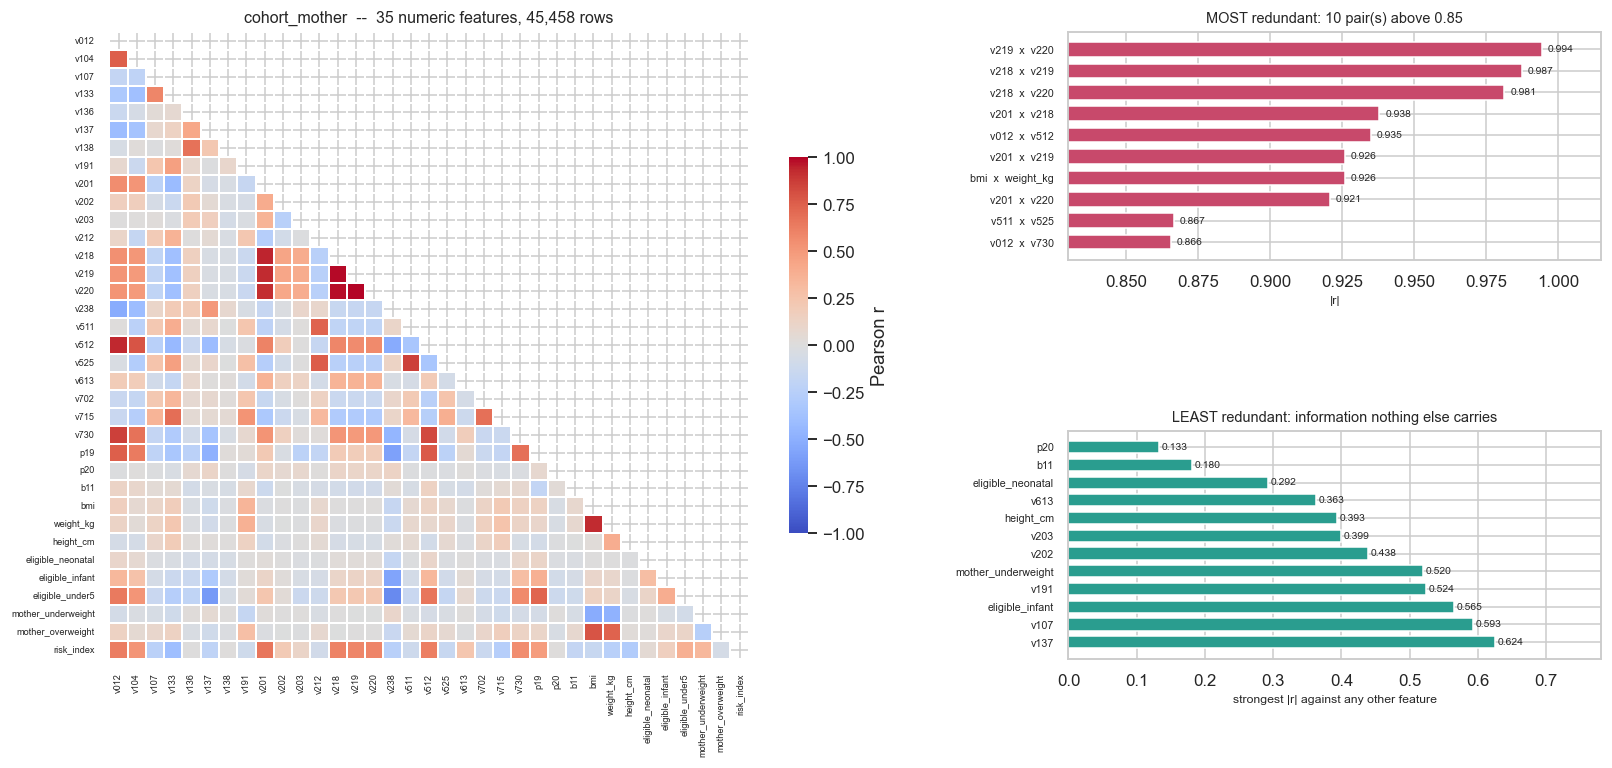

cohort_mother: top redundant pairs


,feature A,feature B,abs r
0,v219,v220,0.994270
1,v218,v219,0.987320
2,v218,v220,0.981367
3,v201,v218,0.937964
4,v012,v512,0.934955
5,v201,v219,0.925984
6,bmi,weight_kg,0.925942
7,v201,v220,0.920886
8,v511,v525,0.866553
9,v012,v730,0.865564


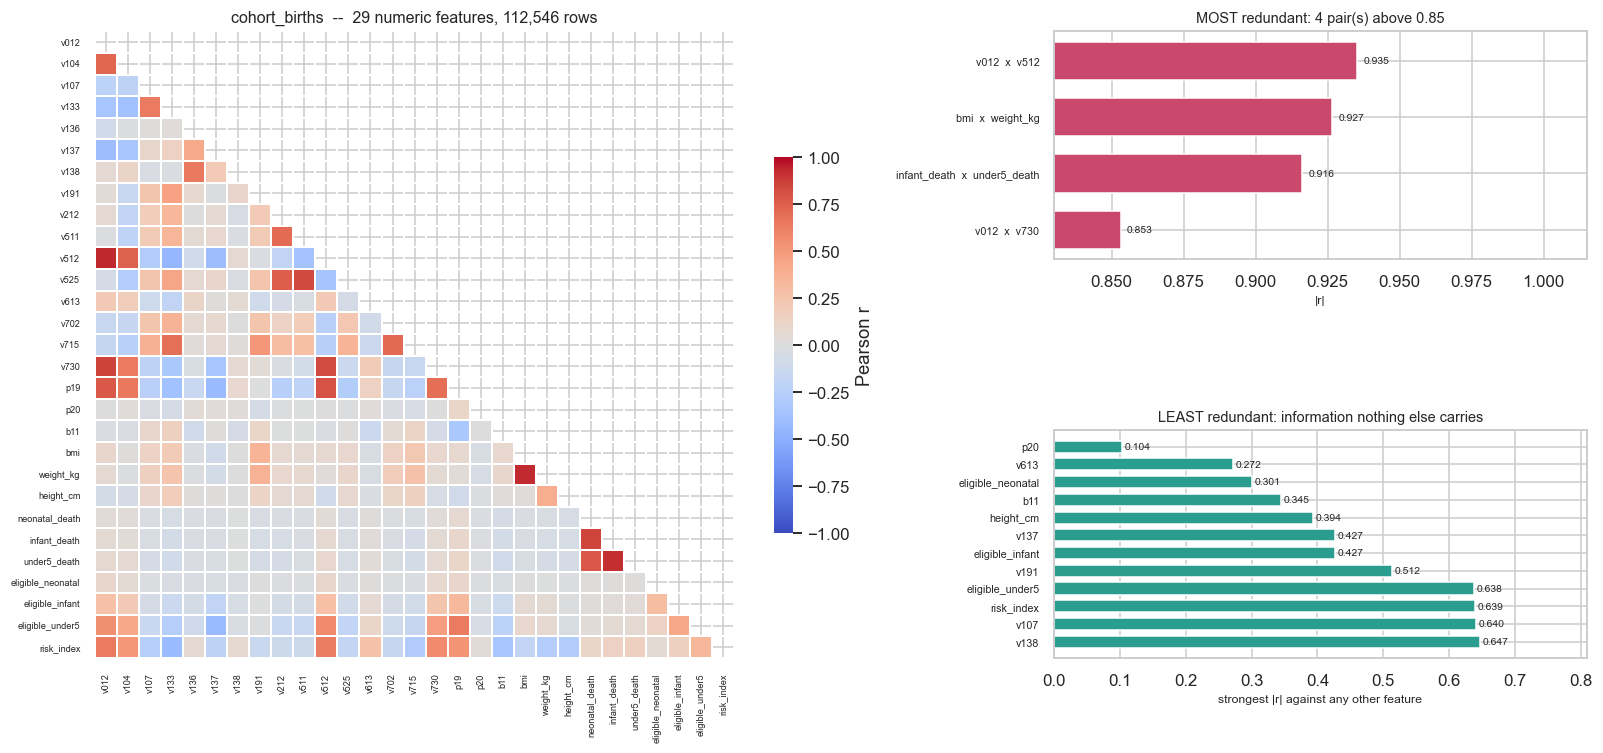

cohort_births: top redundant pairs


,feature A,feature B,abs r
0,v012,v512,0.935388
1,bmi,weight_kg,0.926671
2,infant_death,under5_death,0.916278
3,v012,v730,0.853128


In [29]:
# One figure per cohort: the full correlation structure, the pairs that break
# the threshold, and the features nothing else duplicates.
TOP_N = 12

for name in sorted(cohorts, key=lambda n: -numeric_block(n).shape[1]):
    num, corr, pairs, strongest = corr_parts(name)
    over = pairs[pairs["abs r"] > CORR_THRESHOLD].head(TOP_N)

    fig = plt.figure(figsize=(17.5, 7.4))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.5, 1], hspace=0.75, wspace=0.24)
    ax_h = fig.add_subplot(gs[:, 0])
    ax_t = fig.add_subplot(gs[0, 1])
    ax_b = fig.add_subplot(gs[1, 1])

    # --- heatmap, lower triangle only ------------------------------------
    mask = np.triu(np.ones(corr.shape), k=0).astype(bool)
    sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                square=False, linewidths=0.2, linecolor="white", ax=ax_h,
                cbar_kws={"shrink": 0.6, "label": "Pearson r"})
    ax_h.set_title(f"cohort_{name}  --  {num.shape[1]} numeric features, "
                   f"{len(num):,} rows", fontsize=10.5)
    # seaborn thins tick labels once there are more than ~20 categories, which
    # leaves half the features unnamed. Force one label per row and column.
    ax_h.set_xticks(np.arange(len(corr)) + 0.5)
    ax_h.set_xticklabels(corr.columns, rotation=90, fontsize=6)
    ax_h.set_yticks(np.arange(len(corr)) + 0.5)
    ax_h.set_yticklabels(corr.index, rotation=0, fontsize=6)

    # --- pairs breaking the threshold ------------------------------------
    if len(over):
        labels = [f"{a}  x  {b}" for a, b in
                  zip(over["feature A"], over["feature B"])]
        ax_t.barh(range(len(over)), over["abs r"], color="#c8496b", height=0.68)
        ax_t.set_yticks(range(len(over)))
        ax_t.set_yticklabels(labels, fontsize=7)
        ax_t.invert_yaxis()
        ax_t.set_xlim(CORR_THRESHOLD - 0.02, 1.015)
        for i, v in enumerate(over["abs r"]):
            ax_t.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=6.8)
    else:
        ax_t.text(0.5, 0.5, f"no pair exceeds {CORR_THRESHOLD}", ha="center",
                  va="center", fontsize=9, color="#6b7785")
        ax_t.set_xticks([]); ax_t.set_yticks([])
    ax_t.set_xlabel("|r|", fontsize=8)
    ax_t.set_title(f"MOST redundant: {len(pairs[pairs['abs r'] > CORR_THRESHOLD])} "
                   f"pair(s) above {CORR_THRESHOLD}", fontsize=9.5)

    # --- features nothing duplicates -------------------------------------
    least = strongest.head(TOP_N)
    ax_b.barh(range(len(least)), least.values, color="#2a9d8f", height=0.68)
    ax_b.set_yticks(range(len(least)))
    ax_b.set_yticklabels(least.index, fontsize=7)
    ax_b.invert_yaxis()
    ax_b.set_xlim(0, max(0.35, float(least.max()) * 1.25))
    for i, v in enumerate(least.values):
        ax_b.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=6.8)
    ax_b.set_xlabel("strongest |r| against any other feature", fontsize=8)
    ax_b.set_title("LEAST redundant: information nothing else carries",
                   fontsize=9.5)

    plt.savefig(FIG_DIR / f"correlation_{name}.png", bbox_inches="tight")
    plt.show()

    if len(over):
        print(f"cohort_{name}: top redundant pairs")
        display(over.head(TOP_N).reset_index(drop=True))
    print()

**What we can see.** Each cohort's full correlation structure, with the two ends
of it pulled out beside the heatmap.

**The heatmap is for the block structure, not the individual cells.** At 20–40
features the labels are small; what to read is the pattern. A warm square off the
diagonal is a family of variables measuring one underlying thing, and the same
families recur across cohorts because they come from the shared core:

- **The fertility-accounting block** — `v201` (children ever born), `v218` (living
  children), `v219` (living children plus current pregnancy), `v220` (living
  children capped). These reach r = 0.996 and are arithmetically related. It is
  the same family that produced the leakage on `neonatal_death` documented in
  notebook 01, and it appears in three of the four cohorts. It is absent from
  `births` because the whole family is blacklisted for `neonatal_death`.
- **The age block** — `v012` (current age) with `v512` (years since first
  marriage) at 0.935, and `v511` (age at marriage) with `v525` (age at first sex)
  at 0.913. In this population marriage, first sex and first birth follow each
  other closely.
- **The anthropometry pair** — `bmi` and `weight_kg` at 0.927, in all four
  cohorts.
  BMI is weight divided by height squared, so the two are related by
  construction; height varies far less than weight, which is why the correlation
  is this high rather than moderate.

**The red panel is the drop list.** Every pair above |r| = 0.85, worst first.
**No pair now exceeds 0.999** — the exactly-redundant pairs all belonged to the
immunization cohort, which left with its target. What remains is three families,
none of which is a defect:

- **`bmi` × `weight_kg`** at 0.927 is the only pair present in **all four**
  cohorts, and it is not removable: BMI is weight over height squared, and height
  varies far less than weight in an adult population, so the two are related by
  construction rather than by accident.
- **The `v201`/`v218`/`v219`/`v220` block** reaches 0.996 and appears in three
  cohorts. It is absent from `births` only because the entire family is
  blacklisted for `neonatal_death` — children ever born minus children living
  *is* the number of child deaths, which is the arithmetic leak documented in
  notebook 01. Seeing it disappear from exactly one cohort is confirmation the
  blacklist is being applied.
- **The age block** — `v012` × `v512` at 0.935, `v511` × `v525` at 0.913. In this
  population marriage, first sex and first birth follow each other closely enough
  that the four variables behave almost as one.

**The green panel is the more useful half, and it is the one usually omitted.**
It ranks features by the *strongest* correlation each has with anything else in
the cohort. A feature whose best correlation is below about 0.1 carries
information no other column duplicates — those are the features a model cannot
compensate for if they are removed, and they are where independent signal lives.

One caveat on reading it, learned the hard way: `p17` originally topped this
panel with a maximum |r| of about 0.05. It is not an unusually informative
variable — it runs 1–31, near-uniformly, with a mean of 14.36. It is a **day of
the month**, and it correlates with nothing because a calendar day carries no
information at all.

That is the caution this panel needs. A feature correlating with nothing is
either the most valuable column in the cohort or pure noise, and the correlation
alone cannot distinguish them. `p17` has since been removed from the feature
groups and added to `ALWAYS_BLOCK` in notebook 01, so it no longer reaches any
model.

33 (cohort, feature) combinations with VIF > 10 across 4 cohorts
severe multicollinearity for linear models; harmless for trees



,cohort,feature,VIF,R2
0,recent_birth,v219,290.92,1.00
1,mother,v512,264.92,1.00
2,births,v512,261.39,1.00
3,recent_birth,v220,241.13,1.00
4,mother,v012,232.78,1.00
5,births,v012,220.45,1.00
6,measured_child,weight_kg,192.72,0.99
7,recent_birth,weight_kg,189.86,0.99
8,births,weight_kg,182.04,0.99
9,mother,weight_kg,179.23,0.99


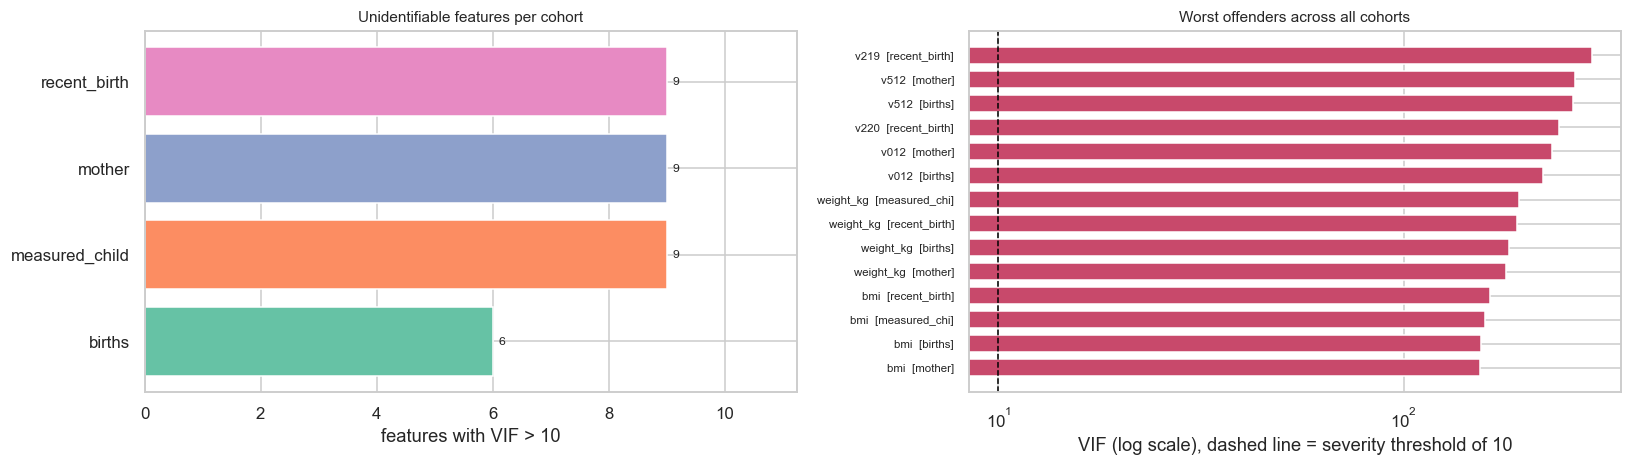

In [30]:
def vif_table(frame, max_cols=30):
    """Variance inflation factors, computed without statsmodels."""
    X = frame.dropna()
    X = X.loc[:, X.std() > 0]
    if len(X) > 20000:
        X = X.sample(20000, random_state=42)
    if X.shape[1] > max_cols:
        X = X[X.var().sort_values(ascending=False).head(max_cols).index]
    Z = ((X - X.mean()) / X.std()).values
    out = []
    for i, col in enumerate(X.columns):
        y = Z[:, i]
        other = np.delete(Z, i, axis=1)
        beta, *_ = np.linalg.lstsq(other, y, rcond=None)
        resid = y - other @ beta
        r2 = 1 - (resid ** 2).sum() / max((y ** 2).sum(), 1e-12)
        out.append({"feature": col, "VIF": 1 / max(1e-9, 1 - r2), "R2": r2})
    return (pd.DataFrame(out).sort_values("VIF", ascending=False)
            .reset_index(drop=True))


# Per cohort, like the correlation above. Taking the numeric block from
# numeric_block() rather than a leftover variable means this cell states which
# data it runs on instead of inheriting it.
vifs = {}
for name in cohorts:
    v = vif_table(numeric_block(name))
    v.insert(0, "cohort", name)
    vifs[name] = v

vif_all = pd.concat(vifs.values(), ignore_index=True)
severe = vif_all[vif_all["VIF"] > 10].sort_values("VIF", ascending=False)

print(f"{len(severe)} (cohort, feature) combinations with VIF > 10 "
      f"across {len(cohorts)} cohorts")
print("severe multicollinearity for linear models; harmless for trees\n")
with pd.option_context("display.max_rows", 40):
    display(severe.head(25).round(2).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))

counts = (vif_all[vif_all["VIF"] > 10].groupby("cohort").size()
          .reindex(list(cohorts)).fillna(0).sort_values())
axes[0].barh(counts.index, counts.values, color=sns.color_palette("Set2"))
axes[0].set_xlabel("features with VIF > 10")
axes[0].set_title("Unidentifiable features per cohort", fontsize=10)
for i, v in enumerate(counts.values):
    axes[0].text(v + 0.1, i, f"{int(v)}", va="center", fontsize=8)
axes[0].set_xlim(right=max(counts.max(), 1) * 1.25)

worst = severe.head(14).iloc[::-1]
labels = [f"{r['feature']}  [{r['cohort'][:12]}]" for _, r in worst.iterrows()]
axes[1].barh(range(len(worst)), worst["VIF"], color="#c8496b", height=0.68)
axes[1].set_yticks(range(len(worst)))
axes[1].set_yticklabels(labels, fontsize=7.5)
axes[1].set_xscale("log")
axes[1].axvline(10, color="black", ls="--", lw=1)
axes[1].set_xlabel("VIF (log scale), dashed line = severity threshold of 10")
axes[1].set_title("Worst offenders across all cohorts", fontsize=10)

plt.tight_layout(); plt.savefig(FIG_DIR / "vif.png",
                                bbox_inches="tight"); plt.show()

**What we can see.** Variance inflation factors, per cohort. VIF answers a
sharper question than correlation: not "does this feature resemble one other
feature", but "can this feature be reconstructed from *all* the others together".

A feature can sit below every pairwise threshold and still be perfectly
predictable from three others in combination. Correlation cannot see that; VIF
can. It is the reason both views are kept rather than one.

The rule of thumb is VIF > 10 = severe. The extreme values — in the hundreds or
thousands — are the numerical signature of exact redundancy: a coefficient on
either member of the pair is meaningless because the model cannot tell them
apart, and it will swing wildly between resamples of the same data.

**What to do about it depends entirely on the model, and that is the point.** For
Random Forest, XGBoost or LightGBM: nothing, they are unaffected — a tree simply
picks one of the correlated features at each split. For Logistic Regression, SVM
or KNN: drop one of each redundant pair, or the coefficients become
uninterpretable and the distance metric double-counts whatever the pair measures.

Because notebook 02 fits both families against every target, no global pruning is
applied. The list here is diagnostic: it tells you which coefficients in the
linear models to distrust, and it explains why a tree's feature importance can
look unstable when two of its inputs are near-duplicates.

### Consolidated drop candidates

In [31]:
# One drop list across all cohorts, so a column removed for one target is not
# quietly kept for another.
rows = []
for name in cohorts:
    _, _, pairs, _ = corr_parts(name)
    for _, r in pairs[pairs["abs r"] > CORR_THRESHOLD].iterrows():
        rows.append({"pair": f"{r['feature A']}  x  {r['feature B']}",
                     "cohort": name, "abs r": round(float(r["abs r"]), 4)})

allpairs = pd.DataFrame(rows)
consolidated = (allpairs.groupby("pair")
                .agg(cohorts=("cohort", "nunique"),
                     where=("cohort", lambda s: ", ".join(sorted(s))),
                     max_r=("abs r", "max"))
                .sort_values(["cohorts", "max_r"], ascending=False))

print(f"{len(consolidated)} distinct redundant pairs across "
      f"{len(cohorts)} cohorts, at |r| > {CORR_THRESHOLD}")
with pd.option_context("display.max_colwidth", 70, "display.max_rows", 60):
    display(consolidated)

exact = consolidated[consolidated["max_r"] > 0.999]
print(f"\n{len(exact)} pair(s) at |r| > 0.999 -- the same measurement twice:")
for pair, r in exact.iterrows():
    print(f"   {pair:44s} r={r['max_r']:.4f}  in {r['where']}")

11 distinct redundant pairs across 4 cohorts, at |r| > 0.85


,cohorts,where,max_r
pair,,,
bmi x weight_kg,4,"births, measured_child, mother, recent_birth",0.9268
v219 x v220,3,"measured_child, mother, recent_birth",0.9959
v218 x v219,3,"measured_child, mother, recent_birth",0.9873
v218 x v220,3,"measured_child, mother, recent_birth",0.9815
v201 x v218,3,"measured_child, mother, recent_birth",0.9569
v201 x v219,3,"measured_child, mother, recent_birth",0.9406
v201 x v220,3,"measured_child, mother, recent_birth",0.9355
v012 x v512,3,"births, measured_child, mother",0.9354
v511 x v525,3,"measured_child, mother, recent_birth",0.9130



0 pair(s) at |r| > 0.999 -- the same measurement twice:


**What we can see.** The same pairs consolidated across cohorts, sorted by how
many cohorts they appear in.

A pair flagged in three or four cohorts is a property of the **shared feature
core** and should be resolved once, globally. A pair flagged in one is specific to
that cohort's module and can be handled there.

Every pair in this list is now a shared-core pair: with the immunization cohort
gone, no module-specific redundancy survives above the threshold. That is a
cleaner starting point for notebook 02 than the fifteen-target panel offered.

The pairs at |r| > 0.999 are the unambiguous ones: two encodings of a single
measurement, where keeping both adds nothing and makes any linear coefficient on
either meaningless. Everything below roughly 0.95 is a judgement call that depends
on the model — a tree is untroubled by correlated inputs and will simply pick one,
while a linear or distance-based model is not.

This is why notebook 02 does not prune on correlation. The eight algorithms differ
in how much they care, so a single global drop list would either handicap the
trees or leave the linear models unidentifiable. The threshold work here informs
how the **feature-importance** output is read: when two features are correlated at
0.9, a tree splits the importance between them almost arbitrarily, and neither
number means what it appears to.

# 14. Data quality

Three checks that matter for interpretation: digit heaping in recalled
quantities, implausible values, and the reporting completeness of birth weight.

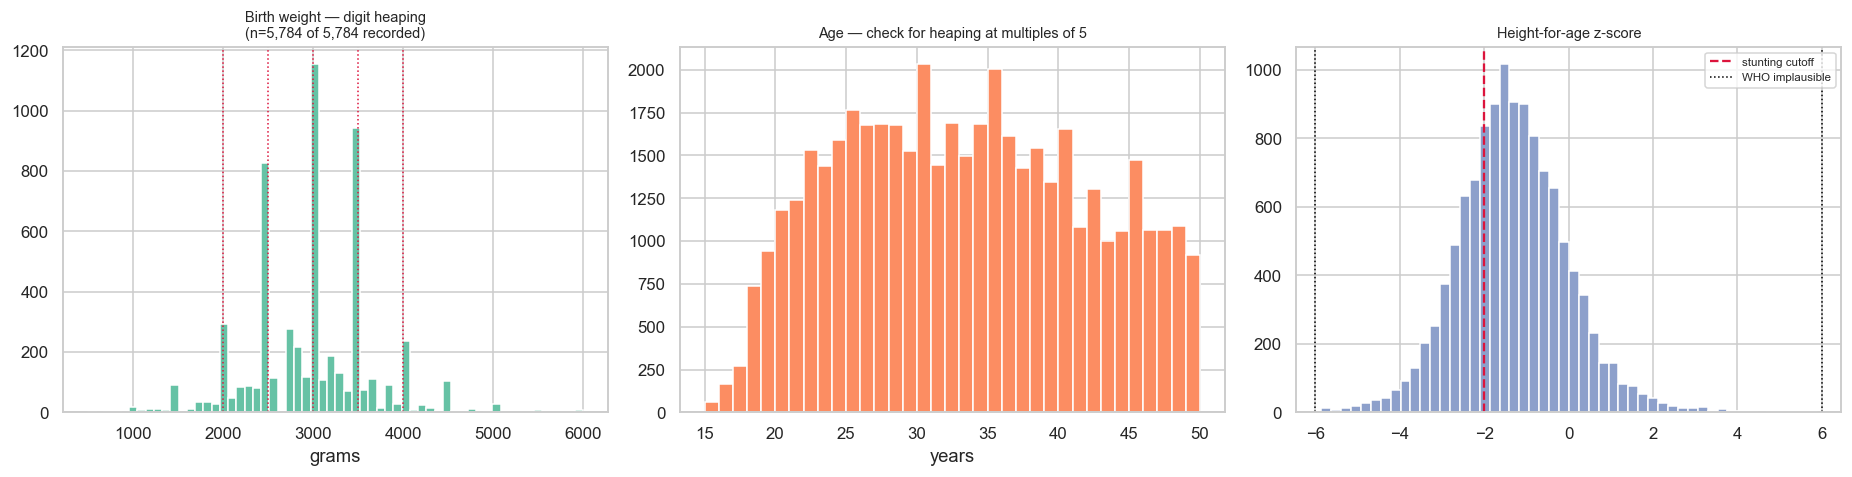

birth weights on a round 500 g   : 63.2%
birth weights on a round 100 g   : 96.5%
HAZ outside WHO plausible range  : 0 of 11,954
birth weight reported            : 5,784 of 10,756 recent births (53.8%)
size-at-birth (m18) available    : 5,332 -- 2022 only; m18 is not in the 2017-18 recode, so small_size_at_birth is a single-round target


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

bw = pd.to_numeric(df["birth_weight_g"], errors="coerce").dropna()
axes[0].hist(bw, bins=60, color=sns.color_palette("Set2")[0], edgecolor="white")
for v_ in [2000, 2500, 3000, 3500, 4000]:
    axes[0].axvline(v_, color="crimson", ls=":", lw=1)
axes[0].set_title(f"Birth weight — digit heaping\n(n={len(bw):,} of "
                  f"{int(df['m19'].notna().sum()):,} recorded)", fontsize=9.5)
axes[0].set_xlabel("grams")

round_500 = (bw % 500 == 0).mean() * 100
round_100 = (bw % 100 == 0).mean() * 100

age = pd.to_numeric(mothers["v012"], errors="coerce").dropna()
axes[1].hist(age, bins=range(15, 51), color=sns.color_palette("Set2")[1],
             edgecolor="white")
axes[1].set_title("Age — check for heaping at multiples of 5", fontsize=9.5)
axes[1].set_xlabel("years")

haz = pd.to_numeric(df["haz"], errors="coerce").dropna()
axes[2].hist(haz, bins=50, color=sns.color_palette("Set2")[2],
             edgecolor="white")
axes[2].axvline(-2, color="crimson", ls="--", lw=1.5, label="stunting cutoff")
axes[2].axvline(-6, color="black", ls=":", lw=1, label="WHO implausible")
axes[2].axvline(6, color="black", ls=":", lw=1)
axes[2].set_title("Height-for-age z-score", fontsize=9.5)
axes[2].legend(fontsize=7.5)

plt.tight_layout(); plt.savefig(FIG_DIR / "data_quality.png",
                                bbox_inches="tight"); plt.show()

print(f"birth weights on a round 500 g   : {round_500:.1f}%")
print(f"birth weights on a round 100 g   : {round_100:.1f}%")
print(f"HAZ outside WHO plausible range  : "
      f"{((haz < -6) | (haz > 6)).sum()} of {len(haz):,}")
# denominator is m17, which exists in BOTH rounds; m18 (size at birth) is
# absent from the 2017-18 recode entirely, so it cannot define the universe
recent = int(df["m17"].notna().sum())
print(f"birth weight reported            : "
      f"{len(bw):,} of {recent:,} recent births "
      f"({len(bw)/max(recent,1)*100:.1f}%)")
print(f"size-at-birth (m18) available    : "
      f"{int(df['m18'].notna().sum()):,} -- 2022 only; m18 is not in the "
      f"2017-18 recode, so small_size_at_birth is a single-round target")

**What this shows.** Three data-quality checks.

**Birth weight (left)** is the consequential one. Around 96% of reported weights
fall on a round 100 g and about 62% on a round 500 g. That is the signature of
*recalled* rather than *recorded* weight — mothers saying "three kilos" rather
than reading a card. It matters because the low-birth-weight definition is a
hard cut at exactly 2500 g, and values pile up precisely on the threshold, so
small differences in rounding flip babies across the boundary. Only about 64% of
recent births have any weight recorded at all.

**Age (centre)**: check for spikes at multiples of five, the classic signature of
age heaping in recall surveys.

**HAZ (right)**: zero values fall outside the WHO plausible range of ±6 SD,
confirming the `'flagged cases'` label was correctly nulled during cleaning. The
red line marks the −2 SD stunting threshold.

Heaping on round numbers is the signature of **recalled** rather than
**recorded** birth weight — mothers reporting "three kilos" rather than reading
a card. It biases any low-birth-weight cut-off at exactly 2500 g, since values
pile up precisely on the threshold. This is the concrete reason
`small_size_at_birth` is the primary newborn-size target in notebook 02 and
`low_birth_weight` only a secondary check.

# 15. Findings

The claims worth carrying into the write-up, with the section each comes from.

1. **The pipeline reproduces both published reports.** Ten indicators, two survey
   rounds, all within 4 points of the figure DHS published, computed
   independently from the raw recodes (section 3). This is the single strongest
   piece of evidence that the cleaning and decoding are correct.
2. **Survey design is not optional.** Mean design effect around 2.2, so a naive
   unclustered analysis would report confidence intervals roughly 1.5x too
   narrow (section 3). Every interval in this notebook is design-based.
3. **Cohorts are not comparable datasets.** The largest holds 112,546 records and
   supports one target; the richest in outcomes holds a tenth as many and
   supports three (section 2b). Sample size and target count run in opposite
   directions, and that constrains how much any single result can be trusted.
4. **Siblings force grouped validation.** 90% of rows in `cohort_births` belong
   to a mother who appears more than once (section 2b). A random split would
   score the models partly on family recognition.
5. **The panel spans three imbalance regimes**, from 0.7:1 to 23.8:1
   (section 4), which is why model selection uses PR-AUC and cost-weighted
   thresholds rather than accuracy. Balance turned out to be a poor guide to
   which outcomes were worth modelling: the best-balanced candidate that was
   ultimately dropped, `incomplete_immunization`, was dropped precisely because
   what it predicted so well was the child's age.
6. **`cohort_measured_child` is 65.7% from 2017-18** (section 4b). All three
   nutrition models therefore learn mostly from 2017-18 conditions, and the
   pooled stunting rate of 28.7% sits nearer the older round's 30.7% than the
   2022 figure of 23.2% for that reason.
7. **Equity gradients run one way, at very different magnitudes** (sections 10
   and 11). Facility delivery moves 48.6 points across wealth quintiles;
   neonatal death moves 2.1. Access is what wealth buys directly; survival is
   mediated by factors it cannot purchase.
8. **C-section is the sharpest equity finding and the clearest exclusion.**
   17.6% to 64.4% across wealth, against a national rate of 45.6% and a WHO
   reference of 10–15% (section 10). Highly predictable, and predicting it would
   mean predicting a clinician's decision rather than a patient's risk.
9. **Redundancy is low and structural** (section 13). Around 1% of feature pairs
   exceed |r| = 0.85 in any cohort, and the families that do — fertility
   accounting, the age block, BMI and weight — are known and documented rather
   than discovered late.

**What this notebook does not establish.** Everything here is associational.
Covariates describe the mother at interview, not at the time of an older
pregnancy, and no causal claim survives that. The gradients are real; the
mechanisms behind them are not tested.